# Shiv Nadar University Chennai
## CS3807 — Deep Learning Laboratory
# Experiment 7: End-to-End Study of Autoencoders, Convolutional Autoencoders, Denoising Autoencoders and Variational Autoencoders

| | | |
|---|---|---|
|**Degree & Branch**| B.Tech Artificial Intelligence & Data Science | **Semester V** |
|**Subject Code & Name**| CS3807 — Deep Learning Laboratory | **AY: 2026–27** |

## 1. Objective

To develop an end-to-end understanding of autoencoders and their variants for image
representation, reconstruction, denoising and generative modeling. The experiment begins
with a fully connected autoencoder, progresses to a Convolutional Autoencoder (CAE),
introduces image corruption for denoising, and finally develops a Variational Autoencoder
(VAE). The learned latent representation is visualized, reconstruction quality is compared
using quantitative and qualitative measures, and the generative capability of the VAE is
explored. The same image dataset and a controlled experimental protocol are used throughout.

## 2. Learning Outcomes

- Explain the encoder–latent–decoder structure of an autoencoder
- Prepare image data for reconstruction-based learning
- Implement a fully connected autoencoder
- Implement a Convolutional Autoencoder for image reconstruction
- Introduce controlled noise and build a denoising autoencoder
- Evaluate reconstruction using MSE, MAE and SSIM
- Visualize and interpret latent representations
- Explain the probabilistic latent representation of a VAE
- Implement the reparameterization trick
- Calculate and interpret reconstruction and KL-divergence losses
- Generate new images by sampling from a learned latent space
- Compare deterministic and variational latent representations

## 0. Environment Setup

In [6]:
!wget -q -O "TimesNewRoman.ttf" "https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf"

import matplotlib
import matplotlib.font_manager as font_manager
import shutil as _shutil
_shutil.rmtree(matplotlib.get_cachedir(), ignore_errors=True)

font_manager.fontManager.addfont("TimesNewRoman.ttf")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)

print("TensorFlow version:", tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0


In [7]:
# Global Plot Formatting

plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600

plt.rcParams['font.family'] = 'Times New Roman'

plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15

plt.rcParams['legend.fontsize'] = 15

sns.set_style("whitegrid")
sns.set_context("notebook")

label_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': 'Times New Roman'
}

title_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': 'Times New Roman'
}

legend_style = {
    'family': 'Times New Roman',
    'weight': 'bold',
    'size': 15
}

def format_axis_ticks(current_axis):

    for tick_label in (
        current_axis.get_xticklabels()
        + current_axis.get_yticklabels()
    ):
        tick_label.set_fontweight('bold')
        tick_label.set_fontname('Times New Roman')

def format_legend_text(current_legend):

    if current_legend is not None:

        for legend_entry in current_legend.get_texts():
            legend_entry.set_fontweight('bold')
            legend_entry.set_fontname('Times New Roman')

        legend_title = current_legend.get_title()
        if legend_title is not None:
            legend_title.set_fontweight('bold')
            legend_title.set_fontname('Times New Roman')

In [8]:
# Extra imports needed later in this notebook (kept separate from the block above,
# which is used exactly as given).
import os, io, time, random
import pandas as pd
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as ssim_metric

random.seed(42)

In [9]:
# --- Figure export helper: saves every required figure as 600 dpi EPS and PDF ---
EXPORT_DIR = os.path.join(os.getcwd(), 'Exp7_Plot_Exports')
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_fig(fig, name):
    '''Save `fig` as both <name>.eps and <name>.pdf at 600 dpi into EXPORT_DIR,
    using the figure exactly as it was styled by the global plot-formatting block.'''
    eps_path = os.path.join(EXPORT_DIR, f"{name}.eps")
    pdf_path = os.path.join(EXPORT_DIR, f"{name}.pdf")
    fig.savefig(eps_path, format='eps', dpi=600, bbox_inches='tight')
    fig.savefig(pdf_path, format='pdf', dpi=600, bbox_inches='tight')
    print(f"Saved: {eps_path}")
    print(f"Saved: {pdf_path}")

print("Plot exports (600 dpi EPS + PDF) will be saved to:", EXPORT_DIR)

Plot exports (600 dpi EPS + PDF) will be saved to: /content/Exp7_Plot_Exports


## 3. Dataset and Experimental Setup

**Dataset: MNIST Handwritten Digit Dataset.** Grayscale handwritten digits, each
$28\times28\times1$. Loaded via Keras/TensorFlow:
https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist

**Recommended laboratory subset:** 10,000 training images and 2,000 test images. Labels are
**not** used as reconstruction targets — the original image is the target:

$$x \rightarrow \text{Encoder} \rightarrow z \rightarrow \text{Decoder} \rightarrow \hat{x}$$

The MNIST `.npz` file is downloaded **once** and cached on Google Drive, exactly like the
dataset caching used in Experiment 6 — later runs check Drive first and skip the download.

In [10]:
# Mount Google Drive (skipped automatically if not running in Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab — set DRIVE_DATA_DIR to a local folder instead.")

DRIVE_DATA_DIR = '/content/drive/MyDrive/CS3807_Exp7_Data' if IN_COLAB else './CS3807_Exp7_Data'
os.makedirs(DRIVE_DATA_DIR, exist_ok=True)
MNIST_DRIVE_PATH = os.path.join(DRIVE_DATA_DIR, 'mnist.npz')
print("Data will be cached at:", MNIST_DRIVE_PATH)

Mounted at /content/drive
Data will be cached at: /content/drive/MyDrive/CS3807_Exp7_Data/mnist.npz


In [11]:
def ensure_mnist_dataset(drive_path=MNIST_DRIVE_PATH):
    '''Download MNIST only if it is not already cached on Drive; return (x_train, y_train, x_test, y_test).'''
    if os.path.exists(drive_path):
        print("MNIST already cached at:", drive_path)
        with np.load(drive_path) as data:
            return data['x_train'], data['y_train'], data['x_test'], data['y_test']

    print("MNIST not found on Drive — downloading (one-time) via Keras...")
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
    np.savez(drive_path, x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)
    print("Downloaded and cached MNIST at:", drive_path)
    return x_train, y_train, x_test, y_test

x_train_full, y_train_full, x_test_full, y_test_full = ensure_mnist_dataset()
print("Full train:", x_train_full.shape, "| Full test:", x_test_full.shape)

MNIST not found on Drive — downloading (one-time) via Keras...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Downloaded and cached MNIST at: /content/drive/MyDrive/CS3807_Exp7_Data/mnist.npz
Full train: (60000, 28, 28) | Full test: (10000, 28, 28)


In [12]:
# --- Recommended laboratory subset: 10,000 training images, 2,000 test images ---
N_TRAIN, N_TEST = 10000, 2000

rng = np.random.default_rng(42)
train_idx = rng.choice(len(x_train_full), size=N_TRAIN, replace=False)
test_idx = rng.choice(len(x_test_full), size=N_TEST, replace=False)

x_train_raw = x_train_full[train_idx]
y_train_labels = y_train_full[train_idx]   # kept ONLY for latent-space visualization later
x_test_raw = x_test_full[test_idx]
y_test_labels = y_test_full[test_idx]      # kept ONLY for latent-space visualization later

# [0,255] -> [0,1]
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

# Keep the spatial version (28,28,1) for convolutional models
x_train_conv = x_train[..., np.newaxis]
x_test_conv = x_test[..., np.newaxis]

# Flattened version (784,) for the fully connected autoencoder
x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

print("x_train_conv:", x_train_conv.shape, "| x_test_conv:", x_test_conv.shape)
print("x_train_flat:", x_train_flat.shape, "| x_test_flat:", x_test_flat.shape)
print("Pixel range:", x_train.min(), "to", x_train.max())

x_train_conv: (10000, 28, 28, 1) | x_test_conv: (2000, 28, 28, 1)
x_train_flat: (10000, 784) | x_test_flat: (2000, 784)
Pixel range: 0.0 to 1.0


## 4. Expected Input and Output

**Expected Input:** each image is $28\times28\times1$; a batch of 32 gives
$X\in\mathbb{R}^{32\times28\times28\times1}$. Pixels are converted from $[0,255]\to[0,1]$
(done above). For the fully connected autoencoder the image is flattened to
$x\in\mathbb{R}^{784}$; for convolutional autoencoders the spatial structure
$x\in\mathbb{R}^{28\times28\times1}$ is retained.

**Expected Output:** a reconstructed image $\hat{x}\in\mathbb{R}^{28\times28\times1}$. For
every reconstruction model: Original image / Reconstructed image / Reconstruction error. For
the denoising model: Original clean image / Noisy image / Denoised reconstruction. For the
VAE: newly generated samples obtained by sampling from the latent distribution.

## 5. Overall Experimental Pipeline

**MNIST Image → Normalization → Encoder → Latent Representation → Decoder → Reconstructed
Image → Evaluation**

The experiment consists of four related studies: (1) Fully Connected Autoencoder,
(2) Convolutional Autoencoder, (3) Denoising Convolutional Autoencoder, (4) Variational
Autoencoder.

## 6. Exploring Autoencoders

An autoencoder learns to reproduce its input at the output. The encoder maps the input to a
lower-dimensional representation $z=f_\theta(x)$, and the decoder reconstructs the input
$\hat{x}=g_\phi(z)$. The training objective minimizes reconstruction error:

$$\mathcal{L}_{rec}=\frac{1}{N}\sum_{i=1}^{N}\|x_i-\hat{x}_i\|^2.$$

**Input Image ($28\times28$) → Encoder → Latent Vector $z$ → Decoder → Output Image
$\hat{x}$.** The latent vector is a compressed representation of the input.

## 7. Fully Connected Autoencoder

**Architecture:** Input 784 → Dense 128 → Dense 32 → Latent 16 → Dense 32 → Dense 128 →
Output 784. ReLU activation in hidden layers, sigmoid activation in the output layer.

**Suggested configuration:** latent dimension 16, Adam, learning rate $10^{-3}$, batch size
128, 20 epochs, binary cross-entropy loss.

In [13]:
def build_fc_autoencoder(latent_dim=16, input_dim=784):
    model = models.Sequential(name=f"FC_Autoencoder_z{latent_dim}")
    model.add(layers.Input(shape=(input_dim,)))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(latent_dim, activation='relu', name='latent'))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy')
    return model

fc_autoencoder = build_fc_autoencoder(latent_dim=16)
fc_autoencoder.summary()

Model: "FC_Autoencoder_z16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
EPOCHS = 20
BATCH_SIZE = 128

fc_start = time.time()
fc_history = fc_autoencoder.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)
fc_time = time.time() - fc_start
print(f"Fully Connected Autoencoder trained in {fc_time:.2f} s | "
      f"trainable params: {fc_autoencoder.count_params()}")

Epoch 1/20
79/79 - 6s - 79ms/step - loss: 0.3468 - val_loss: 0.2493
Epoch 2/20
79/79 - 0s - 6ms/step - loss: 0.2301 - val_loss: 0.2079
Epoch 3/20
79/79 - 0s - 6ms/step - loss: 0.1961 - val_loss: 0.1869
Epoch 4/20
79/79 - 0s - 5ms/step - loss: 0.1796 - val_loss: 0.1702
Epoch 5/20
79/79 - 1s - 7ms/step - loss: 0.1654 - val_loss: 0.1580
Epoch 6/20
79/79 - 0s - 4ms/step - loss: 0.1547 - val_loss: 0.1502
Epoch 7/20
79/79 - 0s - 4ms/step - loss: 0.1487 - val_loss: 0.1461
Epoch 8/20
79/79 - 1s - 8ms/step - loss: 0.1451 - val_loss: 0.1430
Epoch 9/20
79/79 - 1s - 16ms/step - loss: 0.1423 - val_loss: 0.1407
Epoch 10/20
79/79 - 1s - 11ms/step - loss: 0.1399 - val_loss: 0.1387
Epoch 11/20
79/79 - 1s - 9ms/step - loss: 0.1377 - val_loss: 0.1364
Epoch 12/20
79/79 - 1s - 11ms/step - loss: 0.1355 - val_loss: 0.1339
Epoch 13/20
79/79 - 1s - 10ms/step - loss: 0.1333 - val_loss: 0.1326
Epoch 14/20
79/79 - 0s - 4ms/step - loss: 0.1313 - val_loss: 0.1305
Epoch 15/20
79/79 - 0s - 4ms/step - loss: 0.1297 - v

## 8. Required Analysis of the Basic Autoencoder

**Plot 1: Original versus Reconstructed Images** — at least 10 test images, shown as
Original | Reconstruction | Reconstruction Error, fulfilling Section 4's expected-output
triplet (Original image / Reconstructed image / Reconstruction error).

Saved: /content/Exp7_Plot_Exports/Plot1_Original_vs_Reconstructed.eps
Saved: /content/Exp7_Plot_Exports/Plot1_Original_vs_Reconstructed.pdf


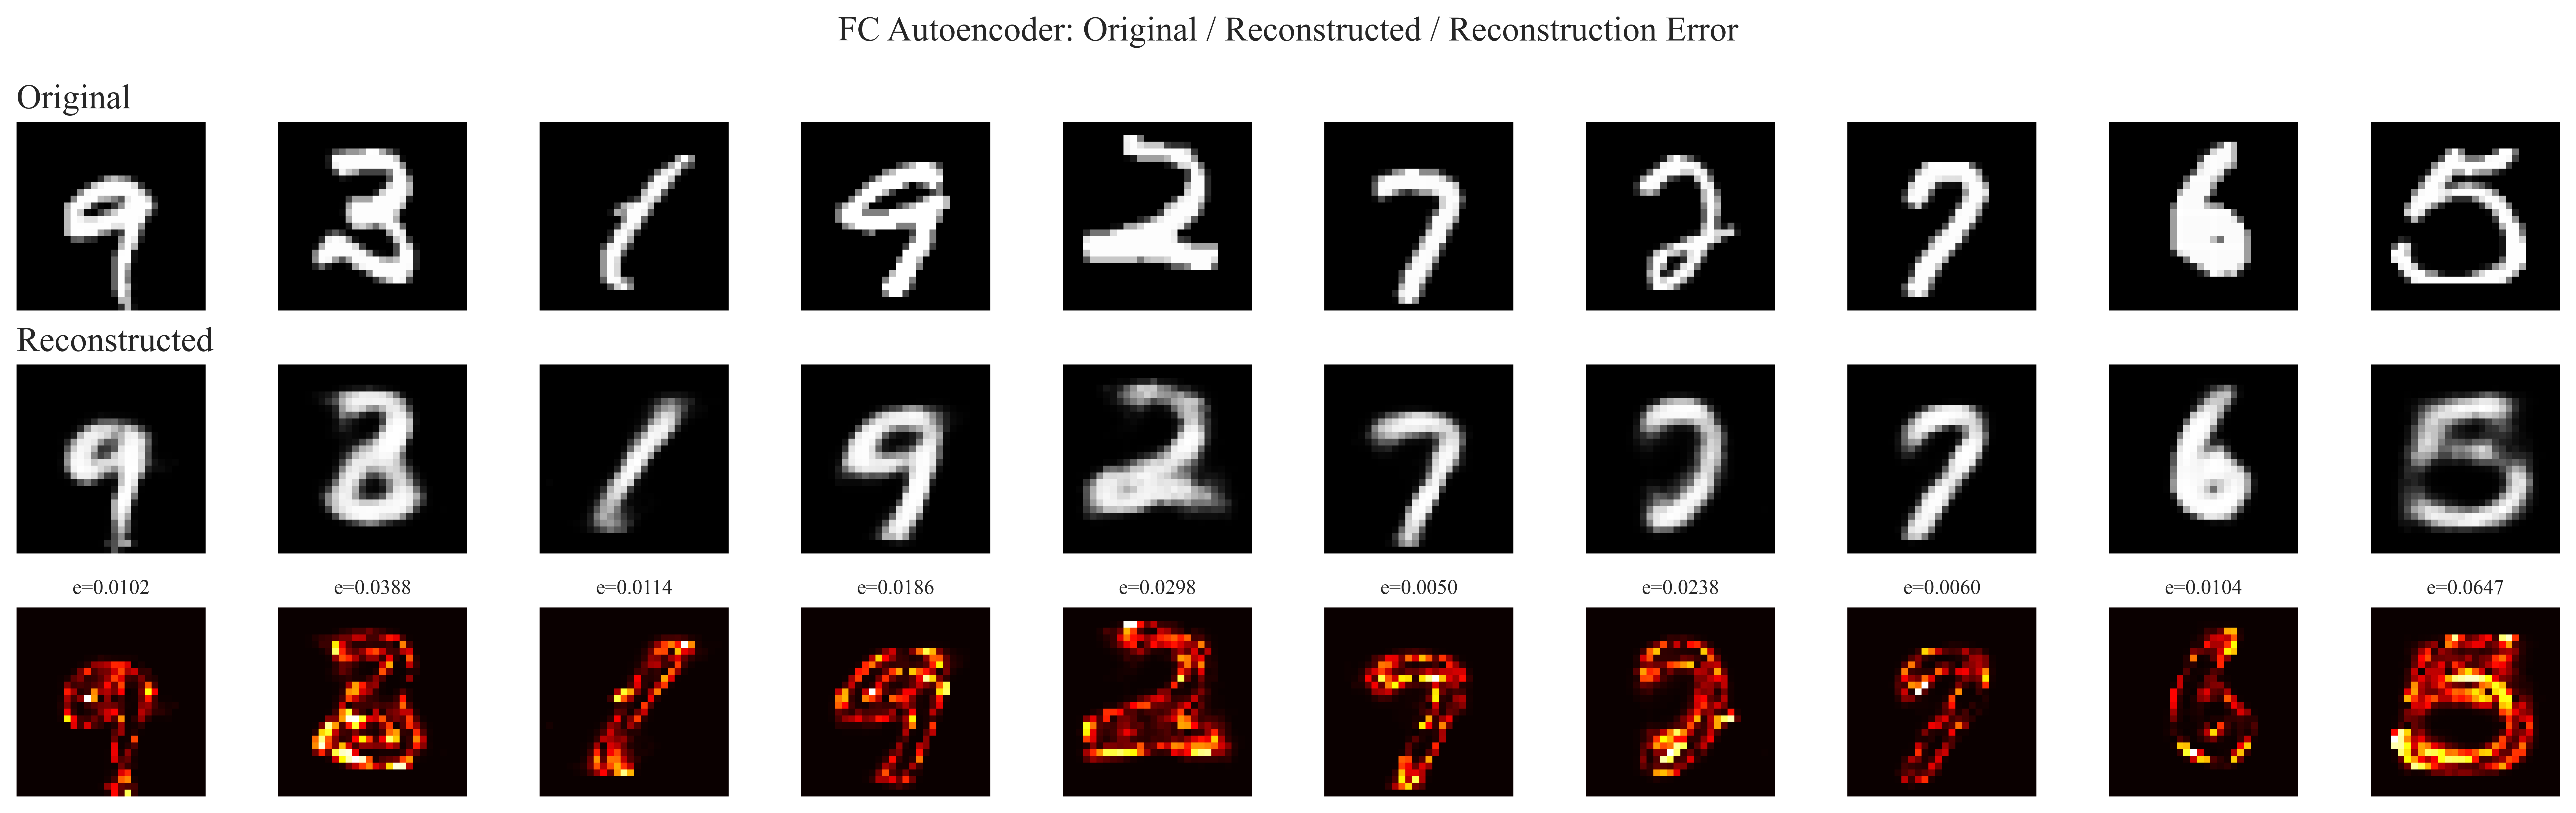

In [15]:
N_SHOW = 10
fc_recon_flat = fc_autoencoder.predict(x_test_flat[:N_SHOW], verbose=0)
fc_error_show = np.abs(x_test_flat[:N_SHOW] - fc_recon_flat)          # per-pixel reconstruction error
fc_error_per_sample = np.mean((x_test_flat[:N_SHOW] - fc_recon_flat) ** 2, axis=1)  # per-image error e_i

fig, axes = plt.subplots(3, N_SHOW, figsize=(1.6 * N_SHOW, 5.0))
for i in range(N_SHOW):
    axes[0, i].imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(fc_recon_flat[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(fc_error_show[i].reshape(28, 28), cmap='hot')
    axes[2, i].axis('off')
    axes[2, i].set_title(f"e={fc_error_per_sample[i]:.4f}", fontsize=9,
                          fontweight='bold', fontname='Times New Roman')
axes[0, 0].set_title("Original", loc='left', **title_style)
axes[1, 0].set_title("Reconstructed", loc='left', **title_style)
axes[2, 0].set_ylabel("Error", **label_style)
fig.suptitle("FC Autoencoder: Original / Reconstructed / Reconstruction Error", **title_style)
plt.tight_layout()
save_fig(fig, "Plot1_Original_vs_Reconstructed")
plt.show()

**Required comments:** the overall digit shape is preserved reasonably well since the
16-dimensional latent code is enough to capture the coarse stroke layout, but fine details —
thin stroke endings, small loops, sharp corners — are visibly blurred because the fully
connected bottleneck discards fine-grained spatial detail. Simple, thick-stroked digits (like
1 and 0) tend to reconstruct more cleanly than digits with more intricate structure (like 8
or 5), which show more blurring around their loops and junctions.

**Plot 2: Training and Validation Reconstruction Loss**

Saved: /content/Exp7_Plot_Exports/Plot2_FC_Training_Validation_Loss.eps
Saved: /content/Exp7_Plot_Exports/Plot2_FC_Training_Validation_Loss.pdf


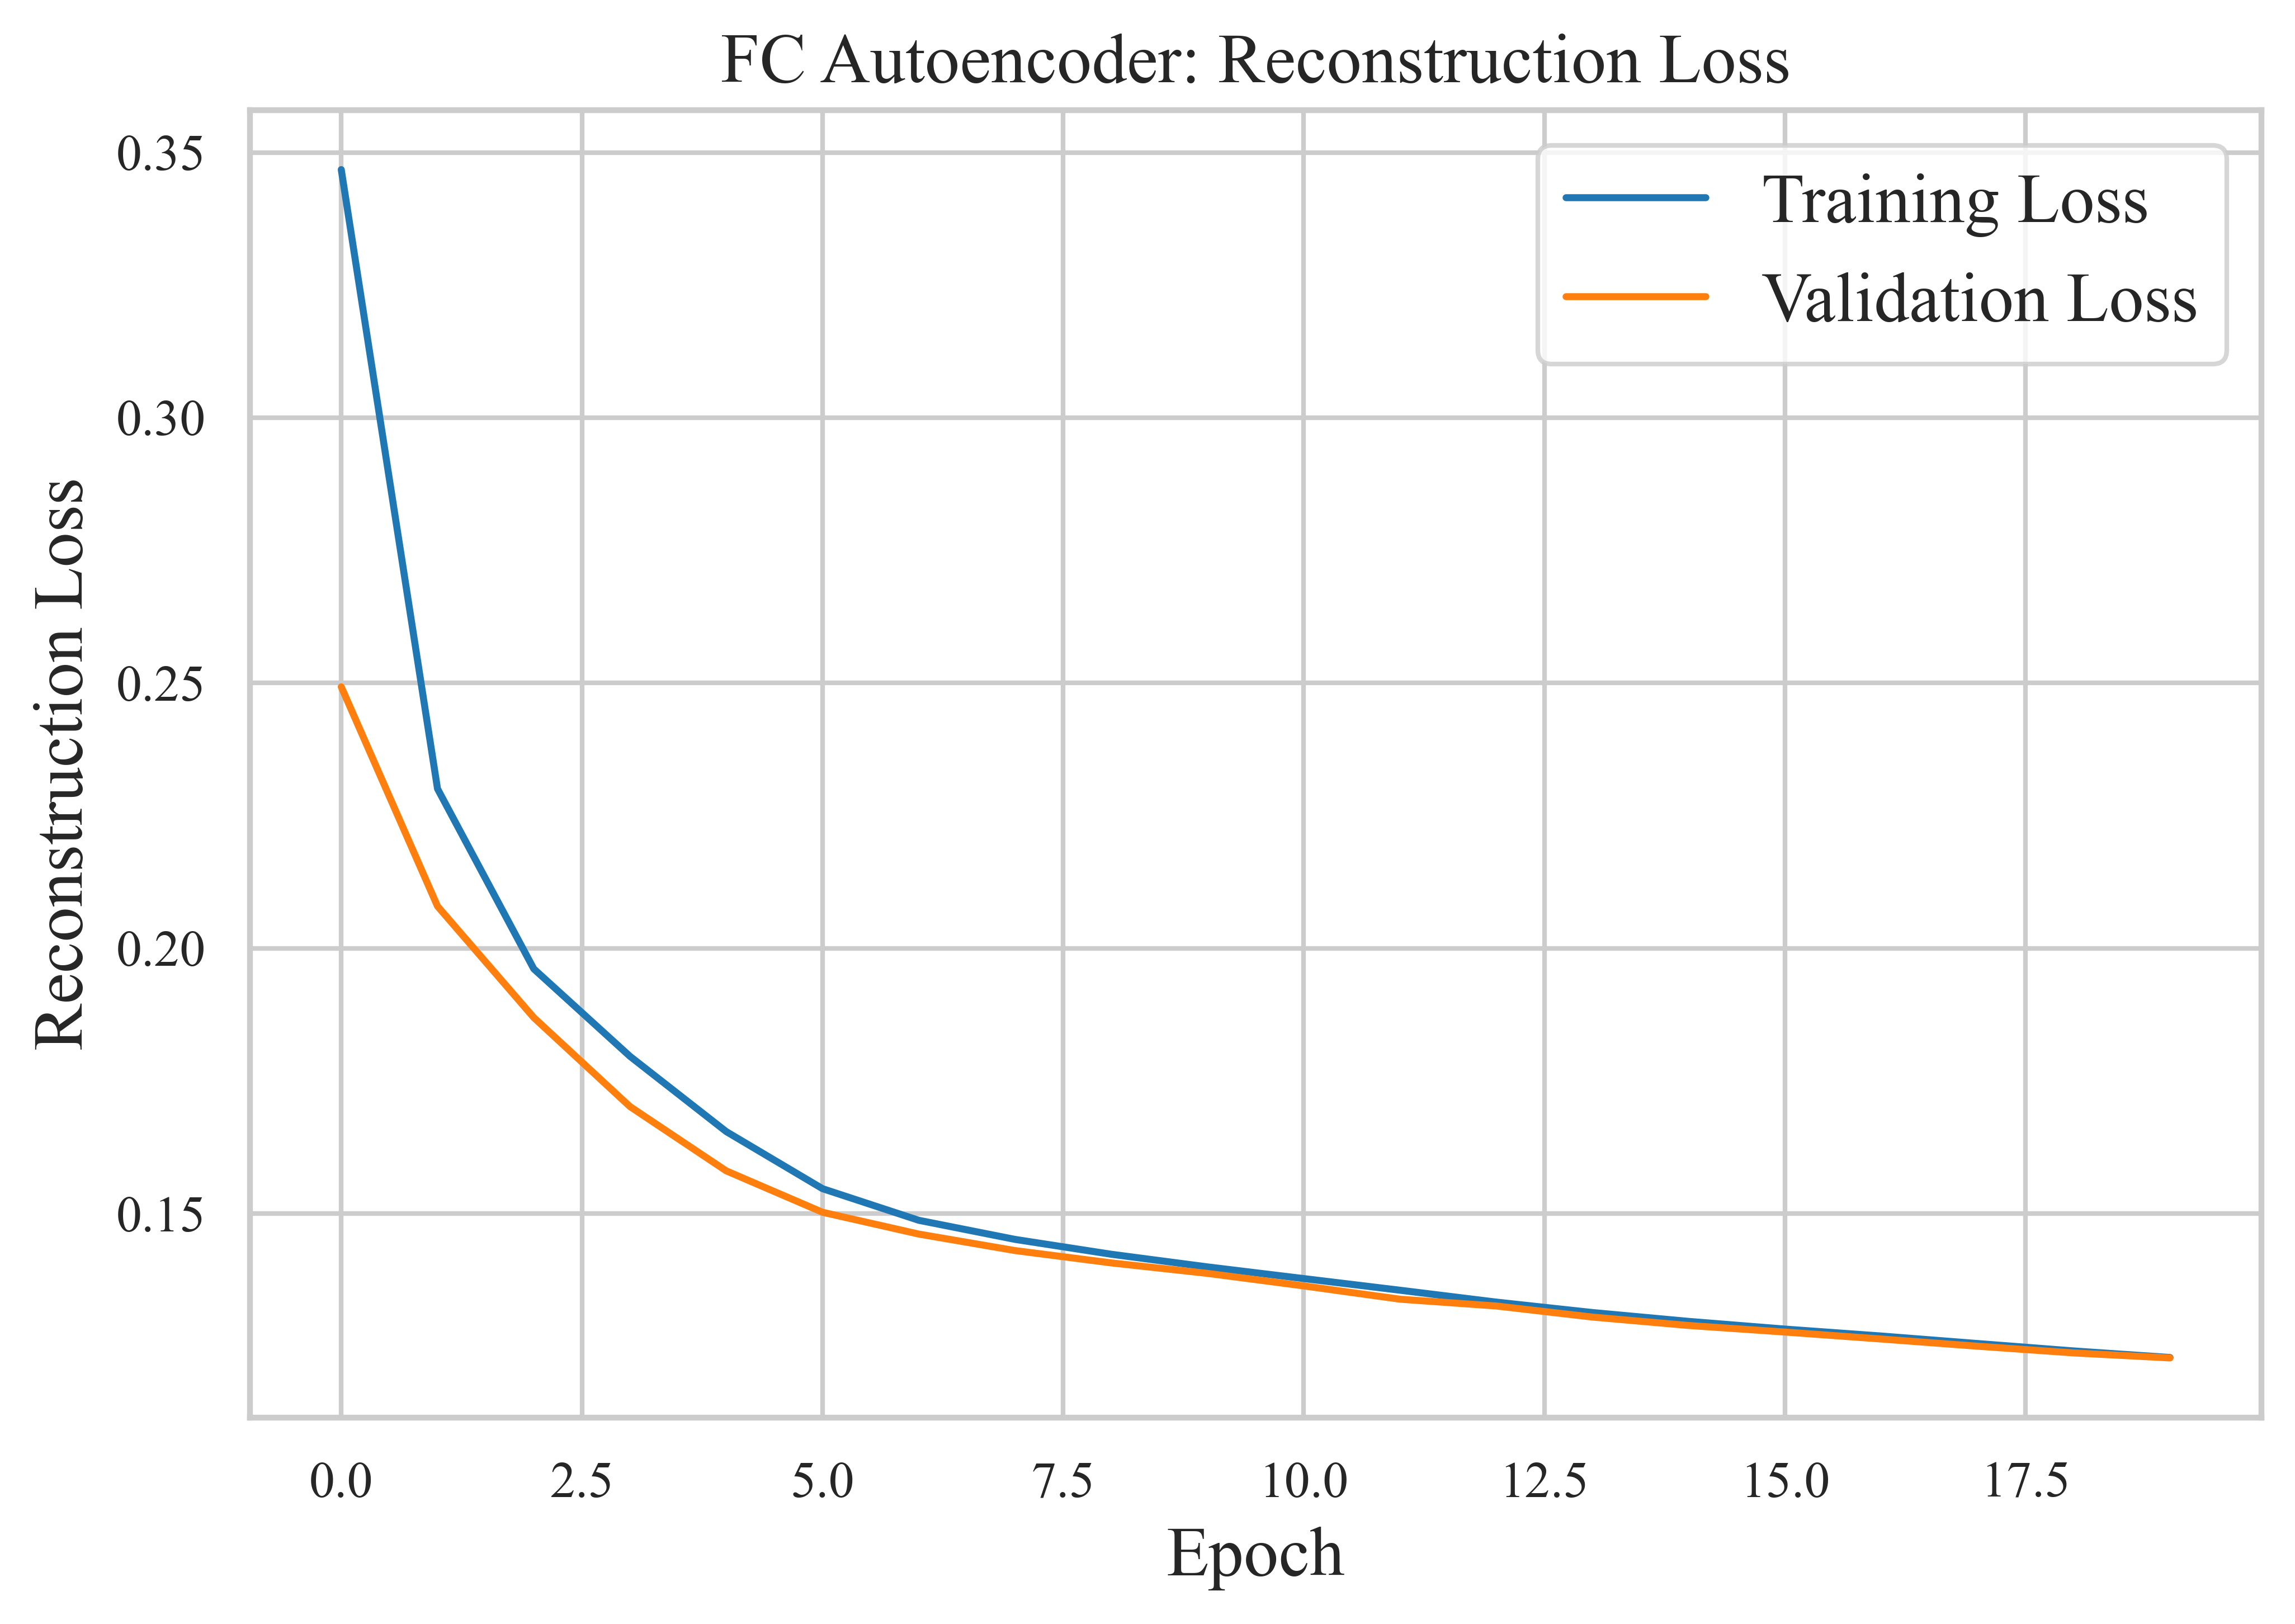

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fc_history.history['loss'], label='Training Loss')
ax.plot(fc_history.history['val_loss'], label='Validation Loss')
ax.set_title("FC Autoencoder: Reconstruction Loss", **title_style)
ax.set_xlabel("Epoch", **label_style)
ax.set_ylabel("Reconstruction Loss", **label_style)
leg = ax.legend(prop=legend_style)
format_legend_text(leg)
format_axis_ticks(ax)
plt.tight_layout()
save_fig(fig, "Plot2_FC_Training_Validation_Loss")
plt.show()

**Required inference:** both curves fall steadily and stay close to each other across
all 20 epochs, with no upward turn in the validation loss — this indicates the model
converges normally with no evidence of overfitting, which is expected given how simple the
784→16→784 mapping is relative to the size of the training set.

## 9. Reconstruction Metrics

Mean Squared Error, Mean Absolute Error, and Structural Similarity (SSIM), all computed on
the test set.

In [17]:
def compute_reconstruction_metrics(x_true_flat, x_pred_flat):
    '''x_true_flat, x_pred_flat: (N, 784) arrays in [0,1]. Returns (MSE, MAE, mean SSIM).'''
    mse = float(np.mean((x_true_flat - x_pred_flat) ** 2))
    mae = float(np.mean(np.abs(x_true_flat - x_pred_flat)))
    ssim_vals = [
        ssim_metric(x_true_flat[i].reshape(28, 28), x_pred_flat[i].reshape(28, 28), data_range=1.0)
        for i in range(len(x_true_flat))
    ]
    return mse, mae, float(np.mean(ssim_vals))

fc_test_recon_flat = fc_autoencoder.predict(x_test_flat, verbose=0)
fc_mse, fc_mae, fc_ssim = compute_reconstruction_metrics(x_test_flat, fc_test_recon_flat)

print(f"Test MSE   : {fc_mse:.6f}")
print(f"Test MAE   : {fc_mae:.6f}")
print(f"Mean SSIM  : {fc_ssim:.4f}")

fc_metrics_table = pd.DataFrame([{
    'Metric': 'Test MSE', 'Value': fc_mse
}, {
    'Metric': 'Test MAE', 'Value': fc_mae
}, {
    'Metric': 'Mean SSIM', 'Value': fc_ssim
}]).set_index('Metric')
fc_metrics_table

Test MSE   : 0.019970
Test MAE   : 0.054288
Mean SSIM  : 0.7735


,Value
Metric,
Test MSE,0.019970
Test MAE,0.054288
Mean SSIM,0.773513


## 10. Convolutional Autoencoder

A Convolutional Autoencoder preserves spatial structure, using convolutions in the encoder
and upsampling in the decoder:

**Input $28\times28\times1$ → Conv 32 → MaxPool → Conv 64 → Latent Feature Map → UpSampling →
Conv → Output $28\times28\times1$**

Implementation (as given, using `UpSampling2D`):

```
Input(28,28,1)
Conv2D(32, 3, activation='relu', padding='same')
MaxPooling2D(2, padding='same')
Conv2D(64, 3, activation='relu', padding='same')
MaxPooling2D(2, padding='same')
Conv2D(64, 3, activation='relu', padding='same')
UpSampling2D(2)
Conv2D(32, 3, activation='relu', padding='same')
UpSampling2D(2)
Conv2D(1, 3, activation='sigmoid', padding='same')
```

In [18]:
def build_conv_autoencoder():
    model = models.Sequential(name="Conv_Autoencoder")
    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Conv2D(32, 3, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(2, padding='same'))
    model.add(layers.Conv2D(64, 3, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(2, padding='same'))
    model.add(layers.Conv2D(64, 3, activation='relu', padding='same'))
    model.add(layers.UpSampling2D(2))
    model.add(layers.Conv2D(32, 3, activation='relu', padding='same'))
    model.add(layers.UpSampling2D(2))
    model.add(layers.Conv2D(1, 3, activation='sigmoid', padding='same'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy')
    return model

conv_autoencoder = build_conv_autoencoder()
conv_autoencoder.summary()

Model: "Conv_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
cae_start = time.time()
cae_history = conv_autoencoder.fit(
    x_train_conv, x_train_conv,
    validation_data=(x_test_conv, x_test_conv),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)
cae_time = time.time() - cae_start
print(f"Convolutional Autoencoder trained in {cae_time:.2f} s | "
      f"trainable params: {conv_autoencoder.count_params()}")

Epoch 1/20
79/79 - 9s - 115ms/step - loss: 0.2480 - val_loss: 0.1039
Epoch 2/20
79/79 - 1s - 8ms/step - loss: 0.0939 - val_loss: 0.0883
Epoch 3/20
79/79 - 1s - 8ms/step - loss: 0.0842 - val_loss: 0.0822
Epoch 4/20
79/79 - 1s - 7ms/step - loss: 0.0800 - val_loss: 0.0787
Epoch 5/20
79/79 - 1s - 8ms/step - loss: 0.0775 - val_loss: 0.0757
Epoch 6/20
79/79 - 1s - 7ms/step - loss: 0.0760 - val_loss: 0.0741
Epoch 7/20
79/79 - 1s - 7ms/step - loss: 0.0744 - val_loss: 0.0731
Epoch 8/20
79/79 - 1s - 8ms/step - loss: 0.0733 - val_loss: 0.0722
Epoch 9/20
79/79 - 1s - 7ms/step - loss: 0.0726 - val_loss: 0.0715
Epoch 10/20
79/79 - 1s - 7ms/step - loss: 0.0720 - val_loss: 0.0709
Epoch 11/20
79/79 - 1s - 7ms/step - loss: 0.0715 - val_loss: 0.0709
Epoch 12/20
79/79 - 1s - 8ms/step - loss: 0.0710 - val_loss: 0.0704
Epoch 13/20
79/79 - 1s - 7ms/step - loss: 0.0705 - val_loss: 0.0698
Epoch 14/20
79/79 - 1s - 8ms/step - loss: 0.0701 - val_loss: 0.0694
Epoch 15/20
79/79 - 1s - 8ms/step - loss: 0.0698 - val_

## 11. Comparing Fully Connected and Convolutional Autoencoders

Both models are trained on the same training and test images.

In [20]:
cae_test_recon = conv_autoencoder.predict(x_test_conv, verbose=0)
cae_test_recon_flat = cae_test_recon.reshape(len(x_test_conv), 784)
cae_mse, cae_mae, cae_ssim = compute_reconstruction_metrics(x_test_flat, cae_test_recon_flat)

fc_vs_cae_table = pd.DataFrame([
    {'Model': 'Fully Connected AE', 'MSE': fc_mse, 'MAE': fc_mae, 'SSIM': fc_ssim,
     'Parameters': fc_autoencoder.count_params()},
    {'Model': 'Convolutional AE', 'MSE': cae_mse, 'MAE': cae_mae, 'SSIM': cae_ssim,
     'Parameters': conv_autoencoder.count_params()},
]).set_index('Model')
fc_vs_cae_table

,MSE,MAE,SSIM,Parameters
Model,,,,
Fully Connected AE,0.019970,0.054288,0.773513,211040
Convolutional AE,0.002448,0.014828,0.976092,74497


**Plot 3: Reconstruction Comparison** — Original → FC-AE Reconstruction → CAE
Reconstruction.

Saved: /content/Exp7_Plot_Exports/Plot3_FC_vs_CAE_Reconstruction.eps
Saved: /content/Exp7_Plot_Exports/Plot3_FC_vs_CAE_Reconstruction.pdf


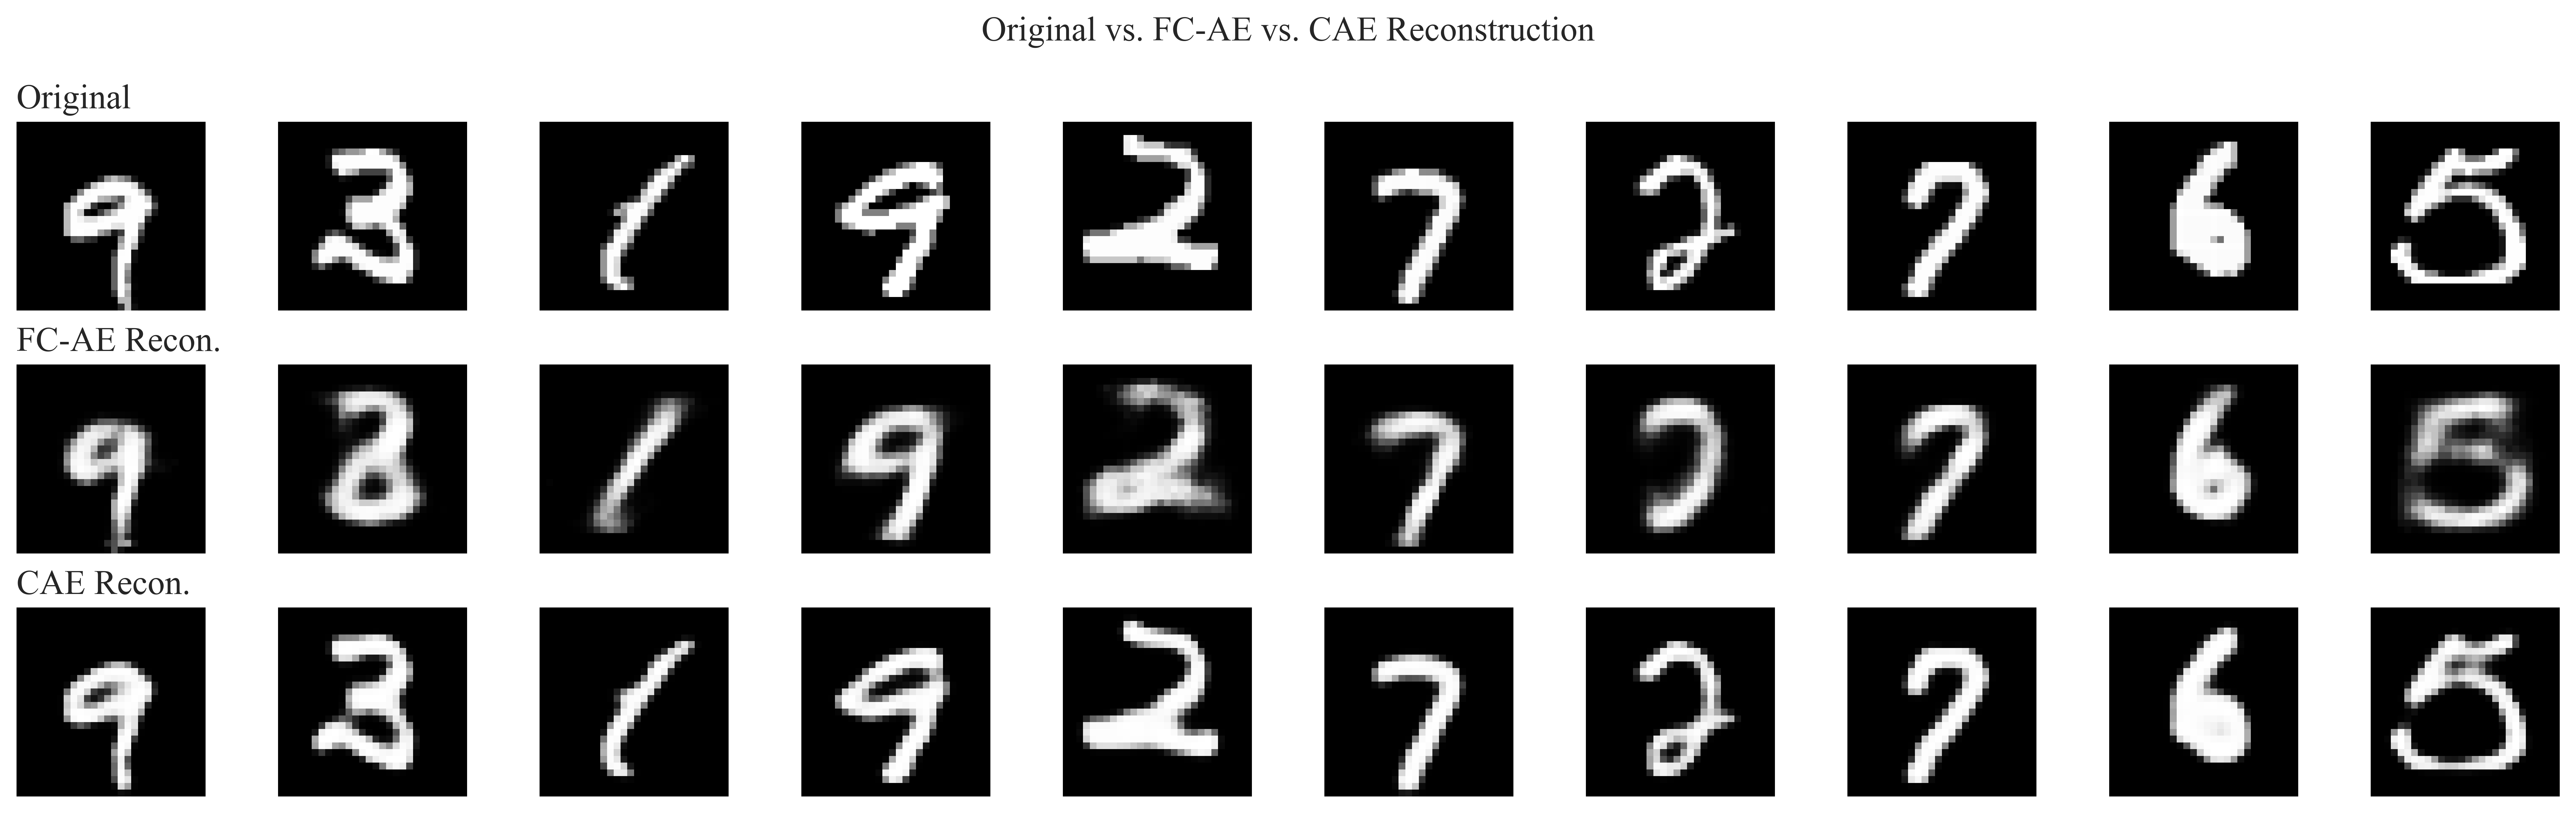

In [21]:
fig, axes = plt.subplots(3, N_SHOW, figsize=(1.6 * N_SHOW, 5.0))
for i in range(N_SHOW):
    axes[0, i].imshow(x_test_flat[i].reshape(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(fc_recon_flat[i].reshape(28, 28), cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(cae_test_recon[i].reshape(28, 28), cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_title("Original", loc='left', **title_style)
axes[1, 0].set_title("FC-AE Recon.", loc='left', **title_style)
axes[2, 0].set_title("CAE Recon.", loc='left', **title_style)
fig.suptitle("Original vs. FC-AE vs. CAE Reconstruction", **title_style)
plt.tight_layout()
save_fig(fig, "Plot3_FC_vs_CAE_Reconstruction")
plt.show()

**Required inference:** the convolutional autoencoder keeps stroke edges noticeably
sharper than the fully connected one, and thin strokes that came out blurred/broken in the
FC-AE reconstruction are more continuous here. This is because convolution preserves spatial
locality — each feature map position still corresponds to a neighborhood of the original
image — whereas flattening to 784 for the FC-AE throws that 2D neighborhood structure away
before the network ever sees it, forcing the dense layers to relearn spatial relationships
from scratch.

## 12. Denoising Autoencoder

A denoising autoencoder receives a corrupted image but is trained to reconstruct the original
clean image:

$$\tilde{x} \rightarrow \text{Encoder} \rightarrow z \rightarrow \text{Decoder} \rightarrow \hat{x}$$

where $\tilde{x}$ is a noisy version of the clean image $x$ — **the target always remains the
clean image**, not the noisy one.

## 13. Adding Image Noise

Two corruption types are used.

**Gaussian noise:** $\tilde{x}=x+n,\ n\sim\mathcal{N}(0,\sigma^2)$, clipped to $[0,1]$;
$\sigma\in\{0.1,0.2,0.3\}$.

**Salt-and-pepper noise:** randomly replace a small proportion of pixels with values close to
0 or 1; $p\in\{0.05,0.10,0.20\}$.

In [22]:
def add_gaussian_noise(images, sigma, seed=42):
    rng = np.random.default_rng(seed)
    noisy = images + rng.normal(0, sigma, size=images.shape)
    return np.clip(noisy, 0.0, 1.0).astype('float32')

def add_salt_and_pepper_noise(images, p, seed=42):
    rng = np.random.default_rng(seed)
    noisy = images.copy()
    mask = rng.random(images.shape)
    noisy[mask < (p / 2)] = 0.0
    noisy[(mask >= (p / 2)) & (mask < p)] = 1.0
    return noisy.astype('float32')

# Sanity check on one noise level of each type
_g = add_gaussian_noise(x_train_conv[:2], 0.2)
_sp = add_salt_and_pepper_noise(x_train_conv[:2], 0.10)
print("Gaussian-noised range:", _g.min(), _g.max())
print("Salt-and-pepper range:", _sp.min(), _sp.max())

Gaussian-noised range: 0.0 1.0
Salt-and-pepper range: 0.0 1.0


## 14. Required Denoising Plots

A denoising Convolutional Autoencoder (same architecture as Section 10) is trained on
Gaussian-noise-corrupted inputs (training noise level $\sigma=0.2$, the middle of the
suggested range) with the **clean** image kept as the target throughout.

In [23]:
DENOISE_SIGMA_TRAIN = 0.2

x_train_noisy = add_gaussian_noise(x_train_conv, DENOISE_SIGMA_TRAIN, seed=42)
x_test_noisy = add_gaussian_noise(x_test_conv, DENOISE_SIGMA_TRAIN, seed=43)

denoising_cae = build_conv_autoencoder()
denoising_cae._name = "Denoising_Conv_Autoencoder"

dcae_start = time.time()
dcae_history = denoising_cae.fit(
    x_train_noisy, x_train_conv,                       # input = noisy, target = CLEAN
    validation_data=(x_test_noisy, x_test_conv),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)
dcae_time = time.time() - dcae_start
print(f"Denoising CAE trained in {dcae_time:.2f} s | trainable params: {denoising_cae.count_params()}")

Epoch 1/20
79/79 - 7s - 85ms/step - loss: 0.2496 - val_loss: 0.1218
Epoch 2/20
79/79 - 1s - 9ms/step - loss: 0.1079 - val_loss: 0.0965
Epoch 3/20
79/79 - 1s - 8ms/step - loss: 0.0942 - val_loss: 0.0899
Epoch 4/20
79/79 - 1s - 8ms/step - loss: 0.0892 - val_loss: 0.0862
Epoch 5/20
79/79 - 1s - 8ms/step - loss: 0.0862 - val_loss: 0.0840
Epoch 6/20
79/79 - 1s - 8ms/step - loss: 0.0842 - val_loss: 0.0823
Epoch 7/20
79/79 - 1s - 8ms/step - loss: 0.0827 - val_loss: 0.0813
Epoch 8/20
79/79 - 1s - 8ms/step - loss: 0.0815 - val_loss: 0.0804
Epoch 9/20
79/79 - 1s - 9ms/step - loss: 0.0806 - val_loss: 0.0795
Epoch 10/20
79/79 - 1s - 8ms/step - loss: 0.0798 - val_loss: 0.0789
Epoch 11/20
79/79 - 1s - 8ms/step - loss: 0.0792 - val_loss: 0.0783
Epoch 12/20
79/79 - 1s - 8ms/step - loss: 0.0786 - val_loss: 0.0778
Epoch 13/20
79/79 - 1s - 8ms/step - loss: 0.0781 - val_loss: 0.0774
Epoch 14/20
79/79 - 1s - 8ms/step - loss: 0.0777 - val_loss: 0.0770
Epoch 15/20
79/79 - 1s - 8ms/step - loss: 0.0773 - val_l

**Plot 4: Clean vs. Noisy vs. Denoised** (at least 10 images).

Saved: /content/Exp7_Plot_Exports/Plot4_Clean_Noisy_Denoised.eps
Saved: /content/Exp7_Plot_Exports/Plot4_Clean_Noisy_Denoised.pdf


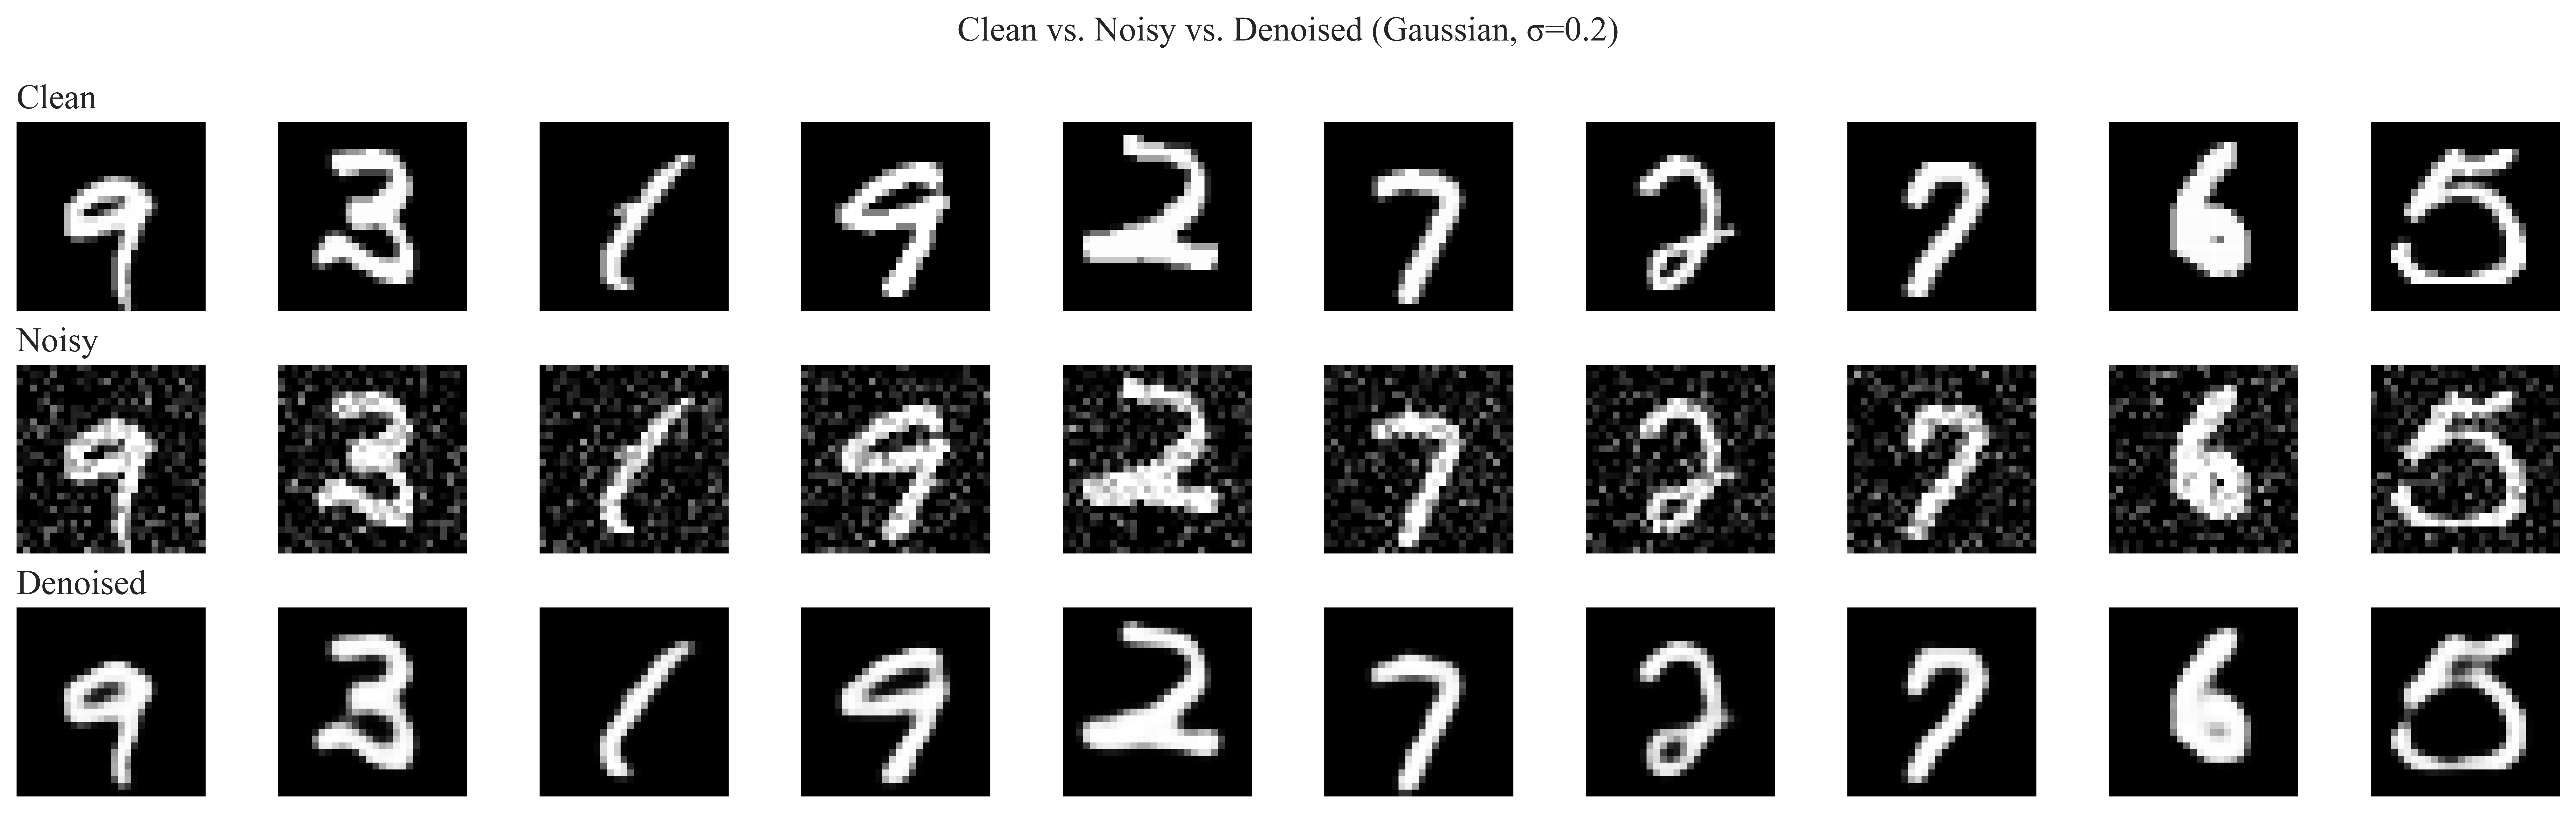

In [24]:
denoised_show = denoising_cae.predict(x_test_noisy[:N_SHOW], verbose=0)

fig, axes = plt.subplots(3, N_SHOW, figsize=(1.6 * N_SHOW, 5.0))
for i in range(N_SHOW):
    axes[0, i].imshow(x_test_conv[i].reshape(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(denoised_show[i].reshape(28, 28), cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_title("Clean", loc='left', **title_style)
axes[1, 0].set_title("Noisy", loc='left', **title_style)
axes[2, 0].set_title("Denoised", loc='left', **title_style)
fig.suptitle("Clean vs. Noisy vs. Denoised (Gaussian, \u03c3=0.2)", **title_style)
plt.tight_layout()
save_fig(fig, "Plot4_Clean_Noisy_Denoised")
plt.show()

**Plot 5: Noise Level vs. Reconstruction Quality** — the trained denoiser above is now
evaluated (without retraining) on test images corrupted at each of the three suggested
Gaussian noise levels.

In [25]:
noise_levels = [0.1, 0.2, 0.3]
noise_level_results = []

for sigma in noise_levels:
    x_test_noisy_sigma = add_gaussian_noise(x_test_conv, sigma, seed=100 + int(sigma * 10))
    denoised_sigma = denoising_cae.predict(x_test_noisy_sigma, verbose=0)
    denoised_sigma_flat = denoised_sigma.reshape(len(x_test_conv), 784)
    mse_s, mae_s, ssim_s = compute_reconstruction_metrics(x_test_flat, denoised_sigma_flat)
    noise_level_results.append({'Noise Level': sigma, 'MSE': mse_s, 'MAE': mae_s, 'SSIM': ssim_s})
    print(f"sigma={sigma} | MSE={mse_s:.6f} | MAE={mae_s:.6f} | SSIM={ssim_s:.4f}")

noise_level_table = pd.DataFrame(noise_level_results).set_index('Noise Level')
noise_level_table

sigma=0.1 | MSE=0.003593 | MAE=0.017905 | SSIM=0.9616
sigma=0.2 | MSE=0.004533 | MAE=0.021190 | SSIM=0.9478
sigma=0.3 | MSE=0.006963 | MAE=0.029143 | SSIM=0.8819


,MSE,MAE,SSIM
Noise Level,,,
0.1,0.003593,0.017905,0.961559
0.2,0.004533,0.021190,0.947757
0.3,0.006963,0.029143,0.881877


Saved: /content/Exp7_Plot_Exports/Plot5a_NoiseLevel_vs_MSE_MAE.eps
Saved: /content/Exp7_Plot_Exports/Plot5a_NoiseLevel_vs_MSE_MAE.pdf


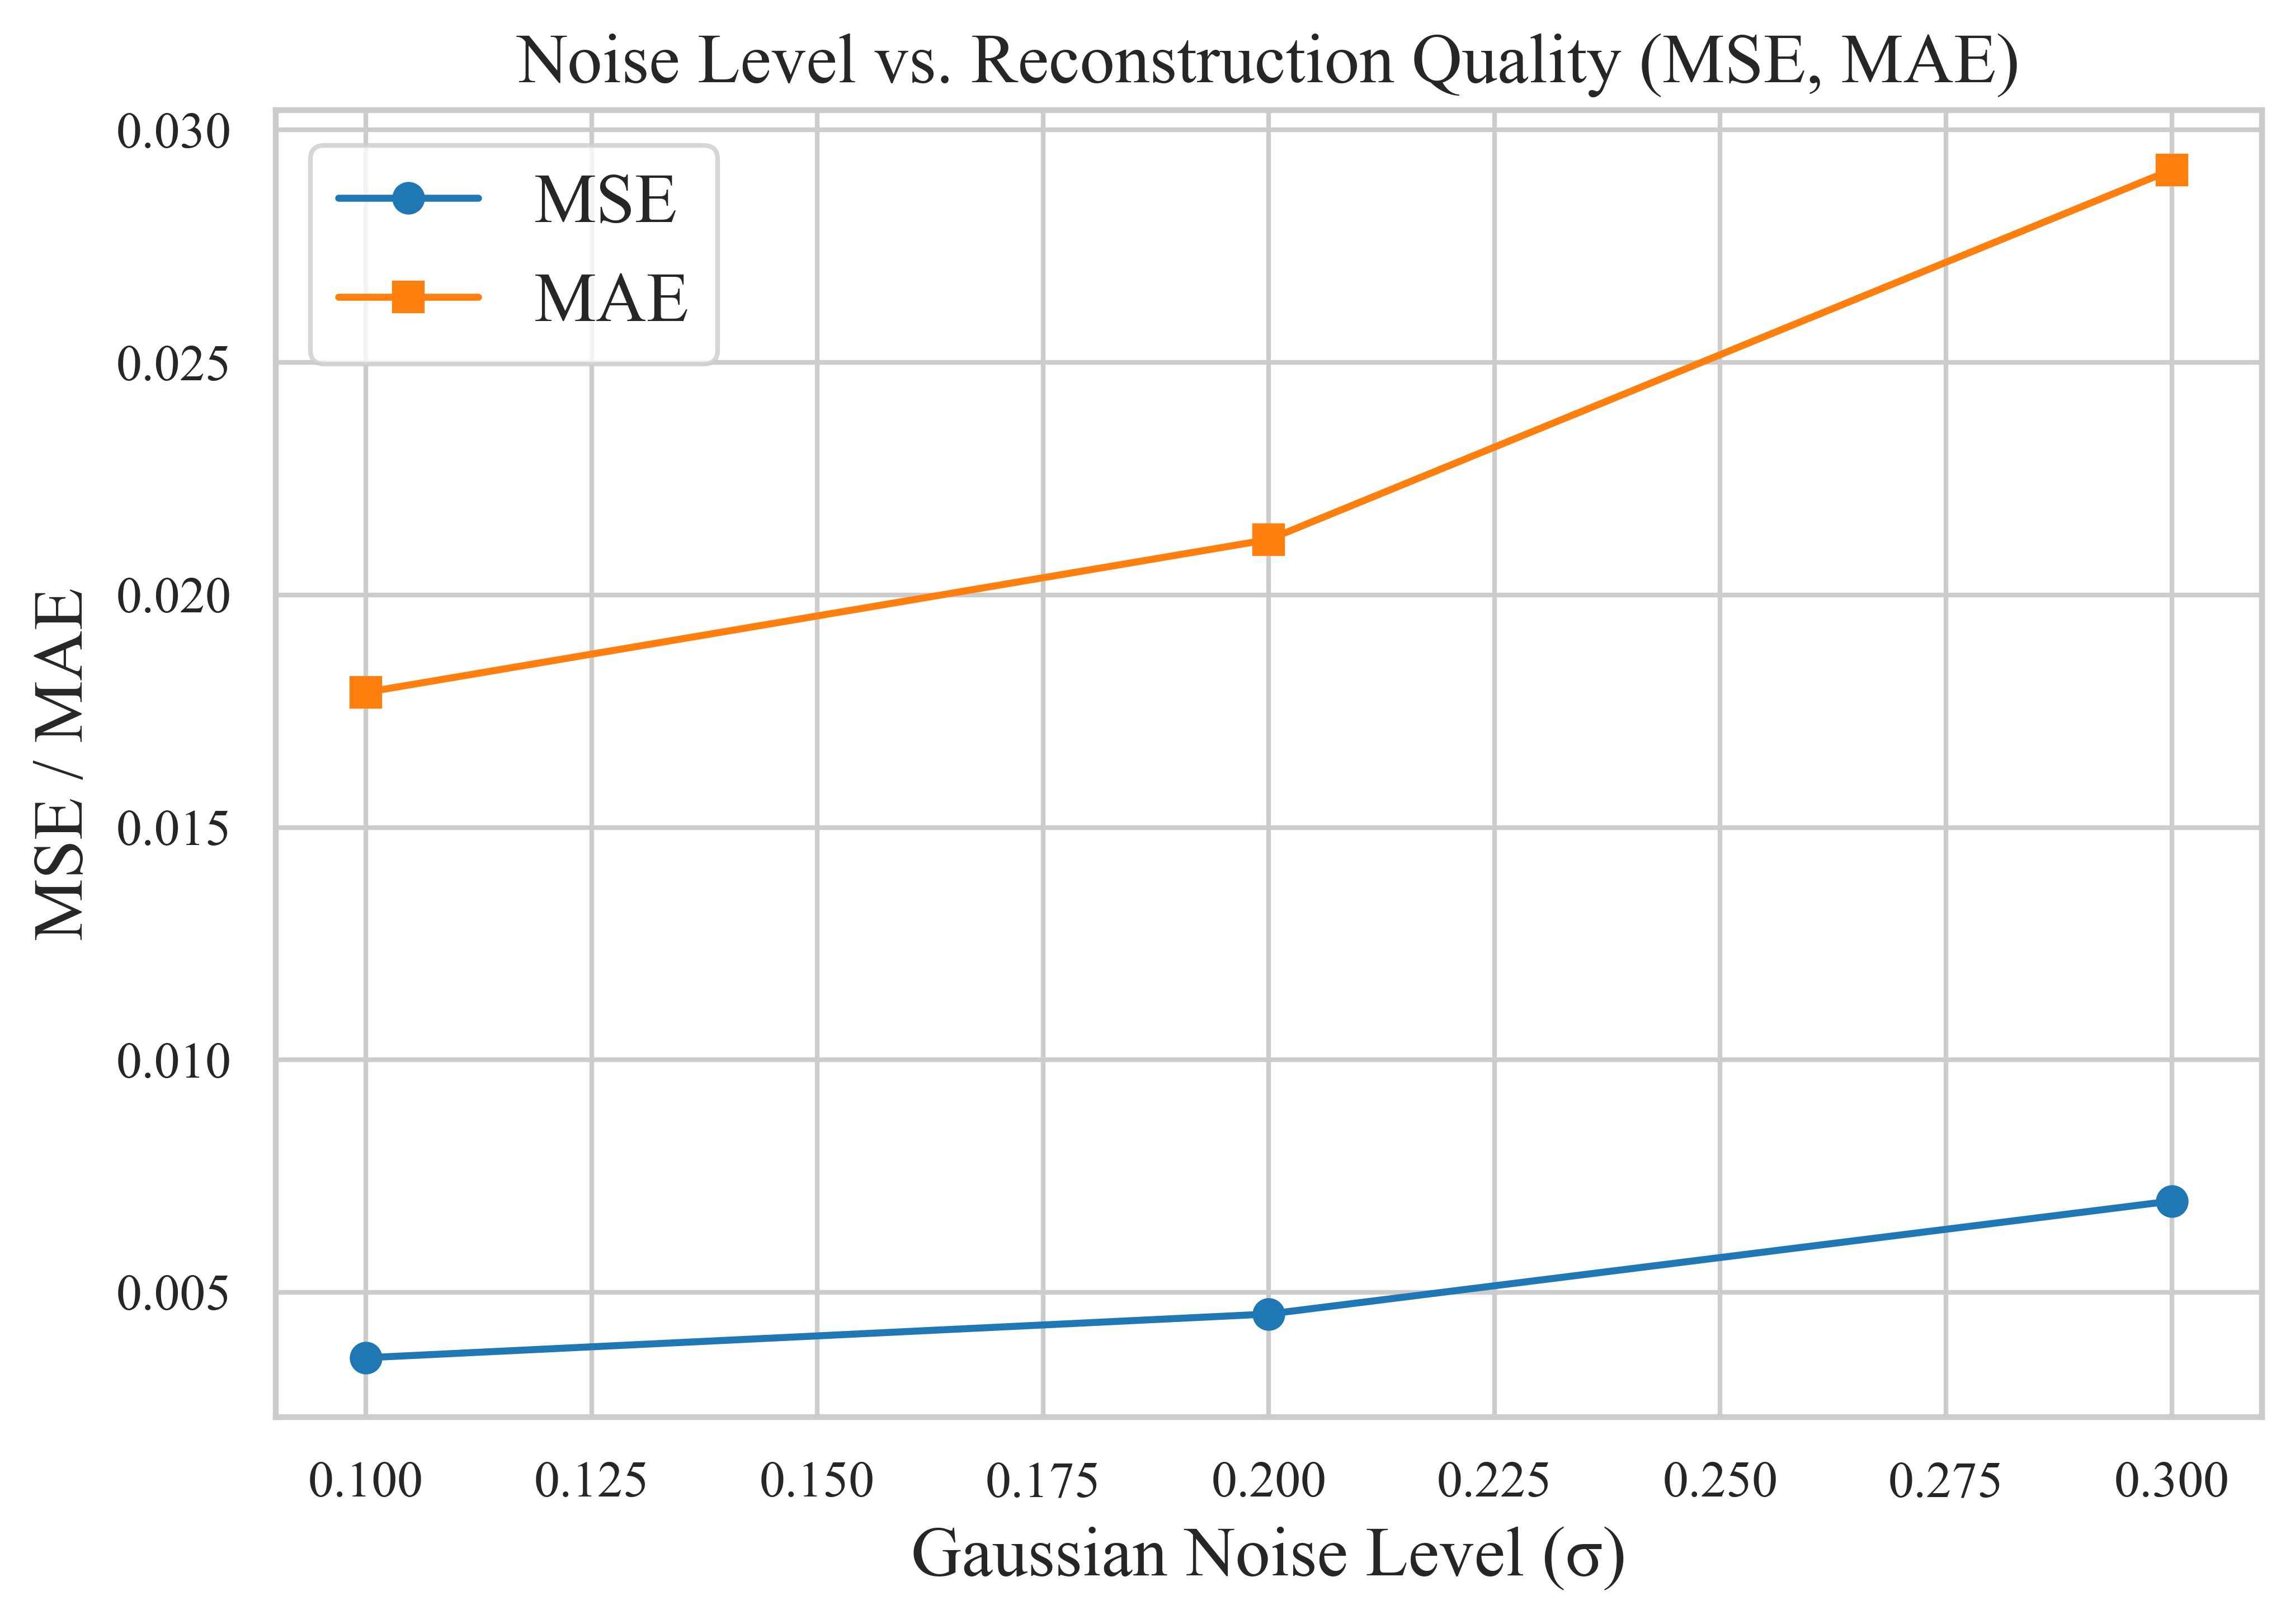

Saved: /content/Exp7_Plot_Exports/Plot5b_NoiseLevel_vs_SSIM.eps
Saved: /content/Exp7_Plot_Exports/Plot5b_NoiseLevel_vs_SSIM.pdf


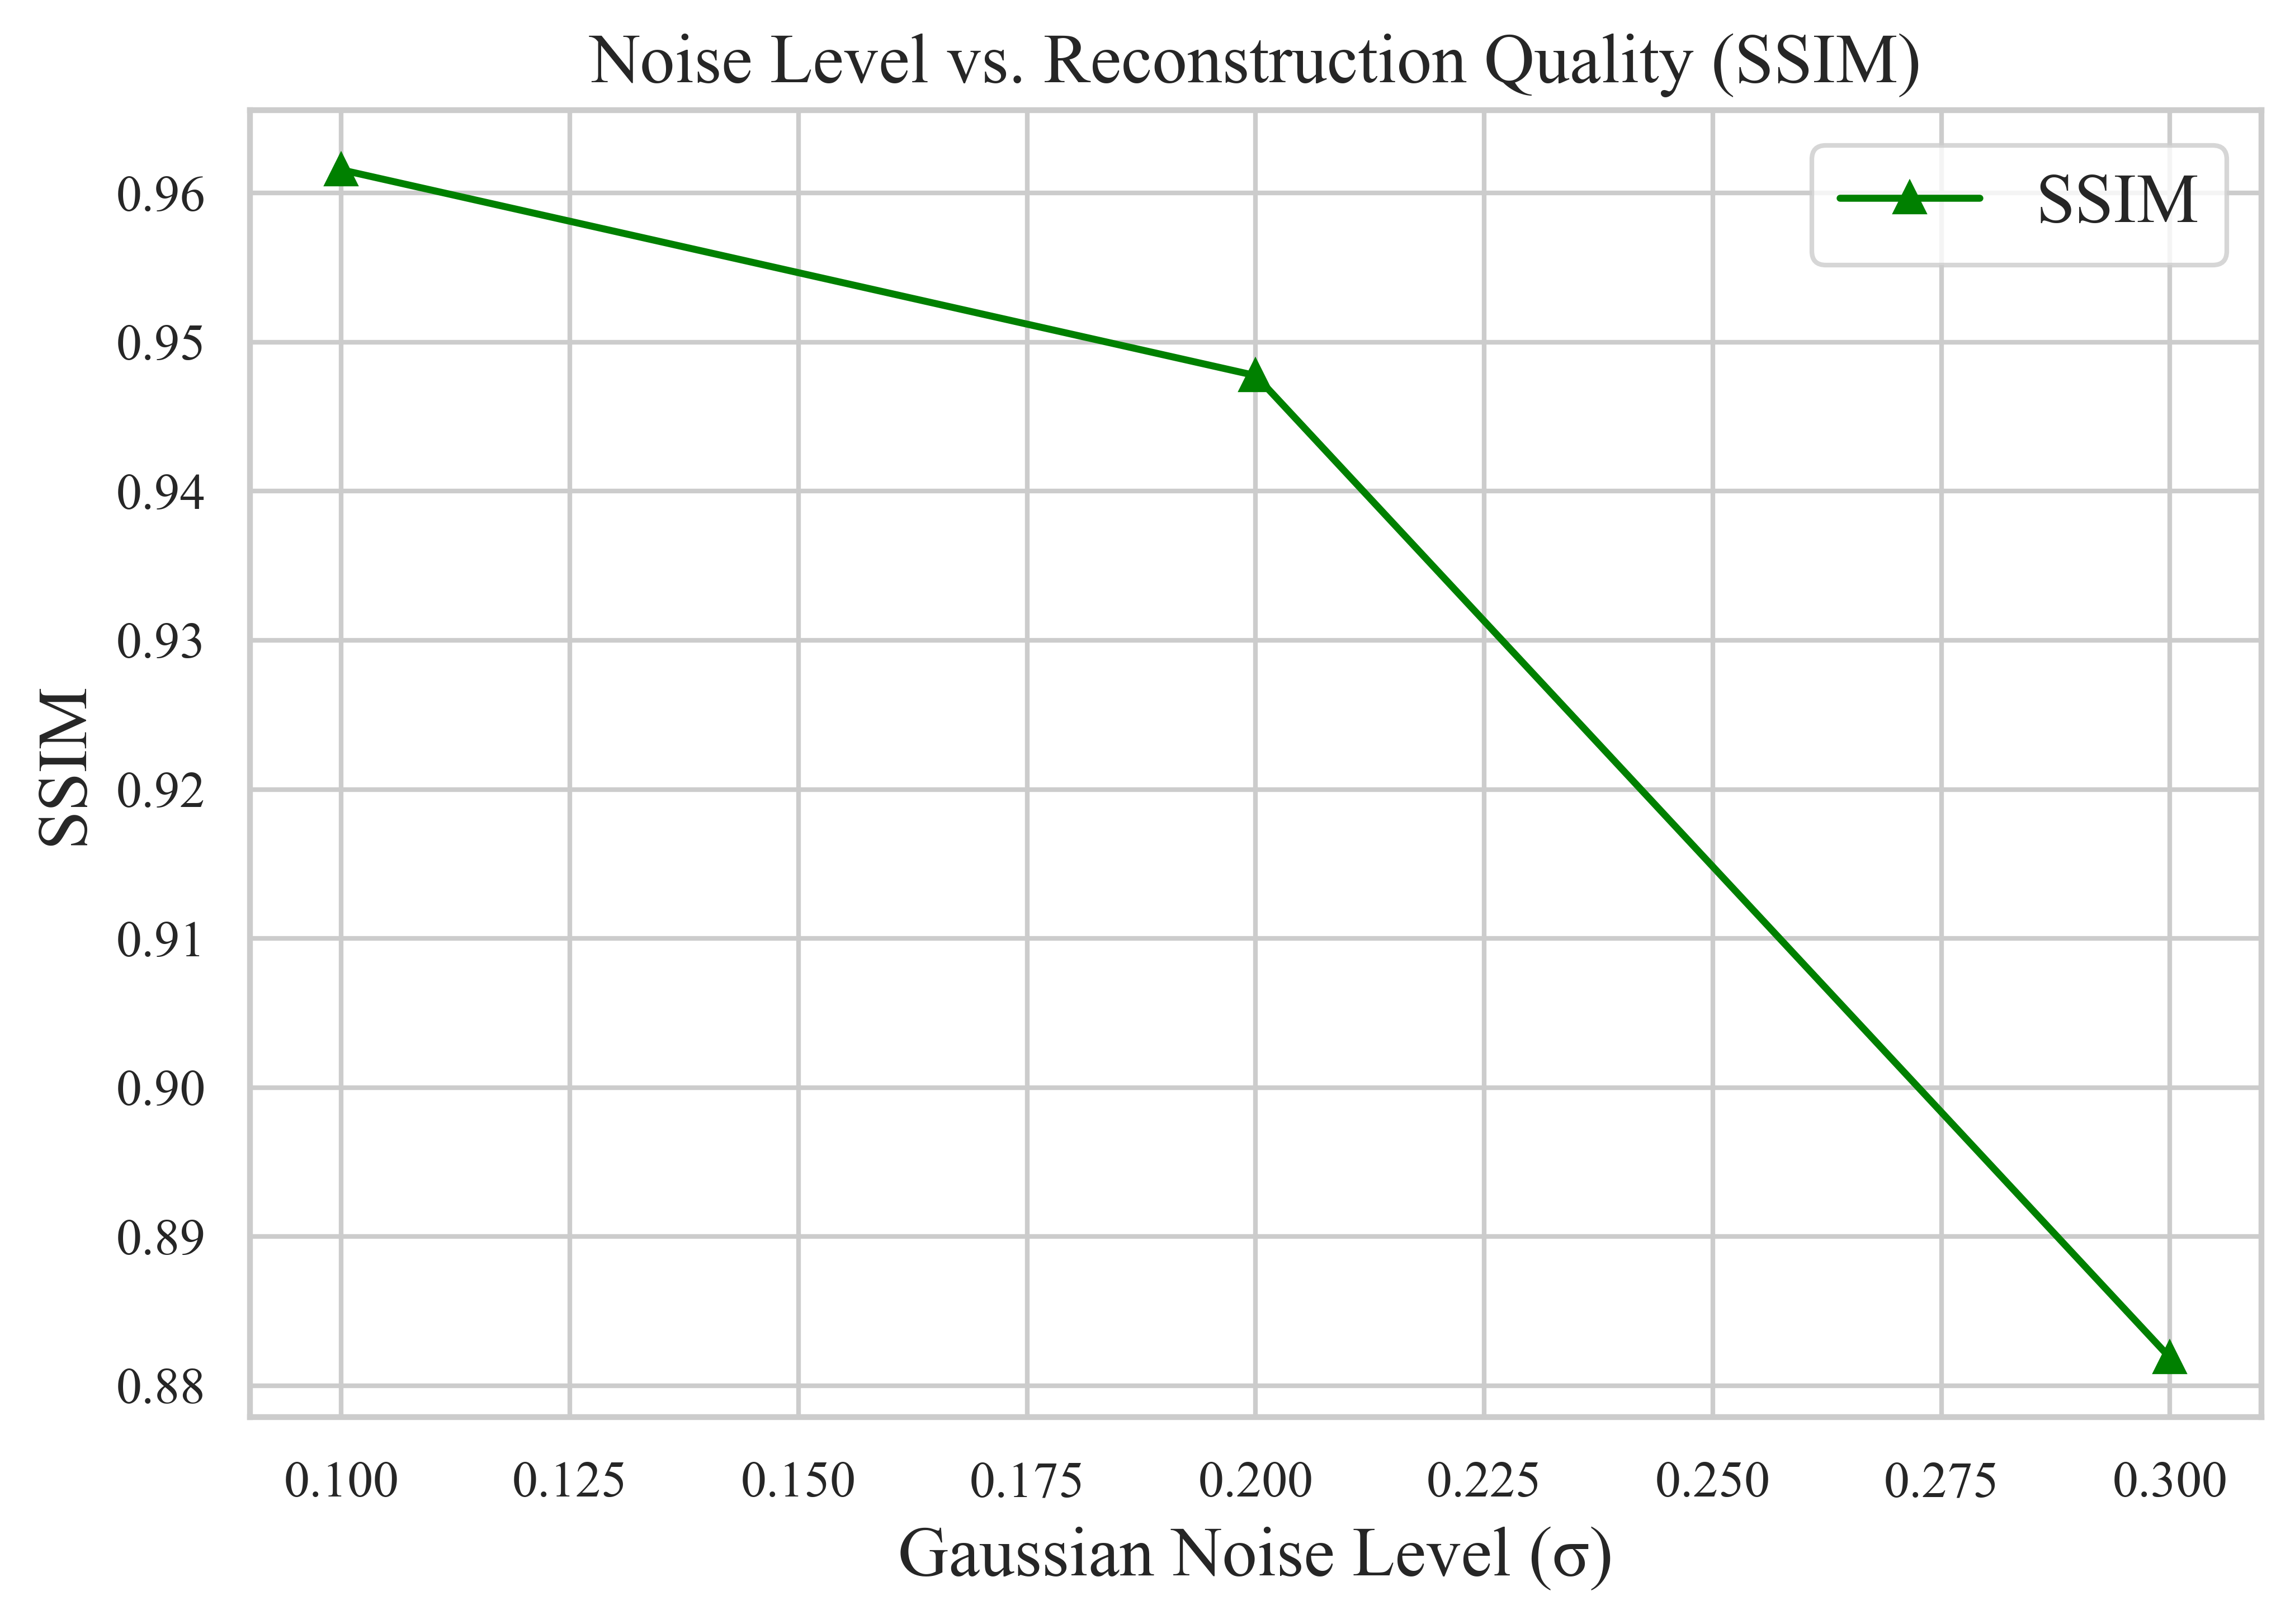

In [26]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(noise_level_table.index, noise_level_table['MSE'], marker='o', label='MSE')
ax1.plot(noise_level_table.index, noise_level_table['MAE'], marker='s', label='MAE')
ax1.set_xlabel("Gaussian Noise Level (\u03c3)", **label_style)
ax1.set_ylabel("MSE / MAE", **label_style)
ax1.set_title("Noise Level vs. Reconstruction Quality (MSE, MAE)", **title_style)
leg1 = ax1.legend(prop=legend_style); format_legend_text(leg1); format_axis_ticks(ax1)
plt.tight_layout()
save_fig(fig, "Plot5a_NoiseLevel_vs_MSE_MAE")
plt.show()

fig, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot(noise_level_table.index, noise_level_table['SSIM'], marker='^', color='green', label='SSIM')
ax2.set_xlabel("Gaussian Noise Level (\u03c3)", **label_style)
ax2.set_ylabel("SSIM", **label_style)
ax2.set_title("Noise Level vs. Reconstruction Quality (SSIM)", **title_style)
leg2 = ax2.legend(prop=legend_style); format_legend_text(leg2); format_axis_ticks(ax2)
plt.tight_layout()
save_fig(fig, "Plot5b_NoiseLevel_vs_SSIM")
plt.show()

**Required inference:** as the corruption level increases from $\sigma=0.1$ to
$\sigma=0.3$, MSE and MAE increase and SSIM decreases — reconstruction quality degrades
monotonically with noise, which is expected since more of the original signal is destroyed
before the encoder ever sees it. Even at the highest tested noise level the denoiser still
recovers the overall digit shape rather than outputting noise or a blank image, showing that
the model has learned the major structure of the digits (stroke layout) rather than just
memorizing a per-pixel identity mapping — the degradation is in fine detail, not in whether
the digit is recognizable.

## 15. Variational Autoencoder

A conventional autoencoder maps an input to a deterministic latent vector $z=f(x)$. A VAE
instead learns a probability distribution
$q_\phi(z|x)=\mathcal{N}(\mu(x),\operatorname{diag}(\sigma^2(x)))$. The encoder produces
$\mu,\ \log\sigma^2$, and a latent vector is sampled using the **reparameterization trick**:

$$z=\mu+\sigma\odot\epsilon,\qquad \epsilon\sim\mathcal{N}(0,I).$$

**Input Image → Encoder → $\mu,\log\sigma^2$ → Sampling $z=\mu+\sigma\epsilon$ → Decoder →
Reconstructed Image**

## 16. VAE Loss Function

**Reconstruction loss** (binary cross-entropy for normalized MNIST images):

$$\mathcal{L}_{rec}=-\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)].$$

**KL divergence:**

$$D_{KL}(q_\phi(z|x)\parallel p(z))=-\frac{1}{2}\sum_j\left(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2\right).$$

**Total loss:** $\mathcal{L}_{VAE}=\mathcal{L}_{rec}+\mathcal{L}_{KL}$, with prior
$p(z)=\mathcal{N}(0,I)$.

## 17. VAE Implementation

Latent dimension $z\in\mathbb{R}^2$ (small enough to visualize directly). Encoder produces
$\mu\in\mathbb{R}^2,\ \log\sigma^2\in\mathbb{R}^2$; decoder maps $z\to28\times28\times1$.

**$28\times28\times1$ → Conv Layers → Flatten → $\mu,\log\sigma^2$ → $z\in\mathbb{R}^2$ →
Dense → ConvTranspose → $28\times28\times1$**

In [27]:
class Sampling(layers.Layer):
    '''Reparameterization trick: z = mu + sigma * epsilon, epsilon ~ N(0, I).'''
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_vae_encoder(latent_dim=2):
    encoder_inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
    x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])
    return models.Model(encoder_inputs, [z_mean, z_log_var, z], name='vae_encoder')

def build_vae_decoder(latent_dim=2):
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation='relu')(latent_inputs)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
    decoder_outputs = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)
    return models.Model(latent_inputs, decoder_outputs, name='vae_decoder')

class VAE(models.Model):
    def __init__(self, latent_dim=2, kl_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = build_vae_encoder(latent_dim)
        self.decoder = build_vae_decoder(latent_dim)
        self.kl_weight = kl_weight
        self.total_loss_tracker = keras.metrics.Mean(name='loss')
        self.reconstruction_loss_tracker = keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def _compute_losses(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)))
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + self.kl_weight * kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._compute_losses(data)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        total_loss, reconstruction_loss, kl_loss = self._compute_losses(data)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

vae = VAE(latent_dim=2)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
vae.encoder.summary()
vae.decoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
vae_start = time.time()
vae_history = vae.fit(
    x_train_conv, validation_data=(x_test_conv, None),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)
vae_time = time.time() - vae_start
# Explicitly build the VAE model before calling count_params()
vae.build((None, 28, 28, 1)) # Input shape for the VAE model
print(f"VAE trained in {vae_time:.2f} s | trainable params: {vae.count_params()}")

Epoch 1/20
79/79 - 1s - 12ms/step - kl_loss: 2.8868 - loss: 185.7199 - reconstruction_loss: 182.8330 - val_kl_loss: 2.8800 - val_loss: 184.6570 - val_reconstruction_loss: 181.7769
Epoch 2/20
79/79 - 1s - 10ms/step - kl_loss: 2.9213 - loss: 185.1333 - reconstruction_loss: 182.2120 - val_kl_loss: 2.9066 - val_loss: 184.1594 - val_reconstruction_loss: 181.2527
Epoch 3/20
79/79 - 1s - 16ms/step - kl_loss: 2.9333 - loss: 184.4908 - reconstruction_loss: 181.5574 - val_kl_loss: 2.8238 - val_loss: 183.4655 - val_reconstruction_loss: 180.6417
Epoch 4/20
79/79 - 1s - 9ms/step - kl_loss: 2.9434 - loss: 183.9470 - reconstruction_loss: 181.0037 - val_kl_loss: 2.8184 - val_loss: 183.1039 - val_reconstruction_loss: 180.2854
Epoch 5/20
79/79 - 1s - 8ms/step - kl_loss: 2.9827 - loss: 183.6182 - reconstruction_loss: 180.6355 - val_kl_loss: 3.0361 - val_loss: 182.6570 - val_reconstruction_loss: 179.6209
Epoch 6/20
79/79 - 1s - 8ms/step - kl_loss: 3.0173 - loss: 182.9601 - reconstruction_loss: 179.9428 - 

**Training/validation reconstruction loss for the VAE** (listed in Section 22's
required-plots checklist as item 9; the document does not give this an inline "Plot N" label
of its own — that label is used by the reconstruction-error histogram in Section 23 instead,
so this figure is named without a plot number to avoid clashing with it).

Saved: /content/Exp7_Plot_Exports/PlotVAE_Training_Validation_Loss.eps
Saved: /content/Exp7_Plot_Exports/PlotVAE_Training_Validation_Loss.pdf


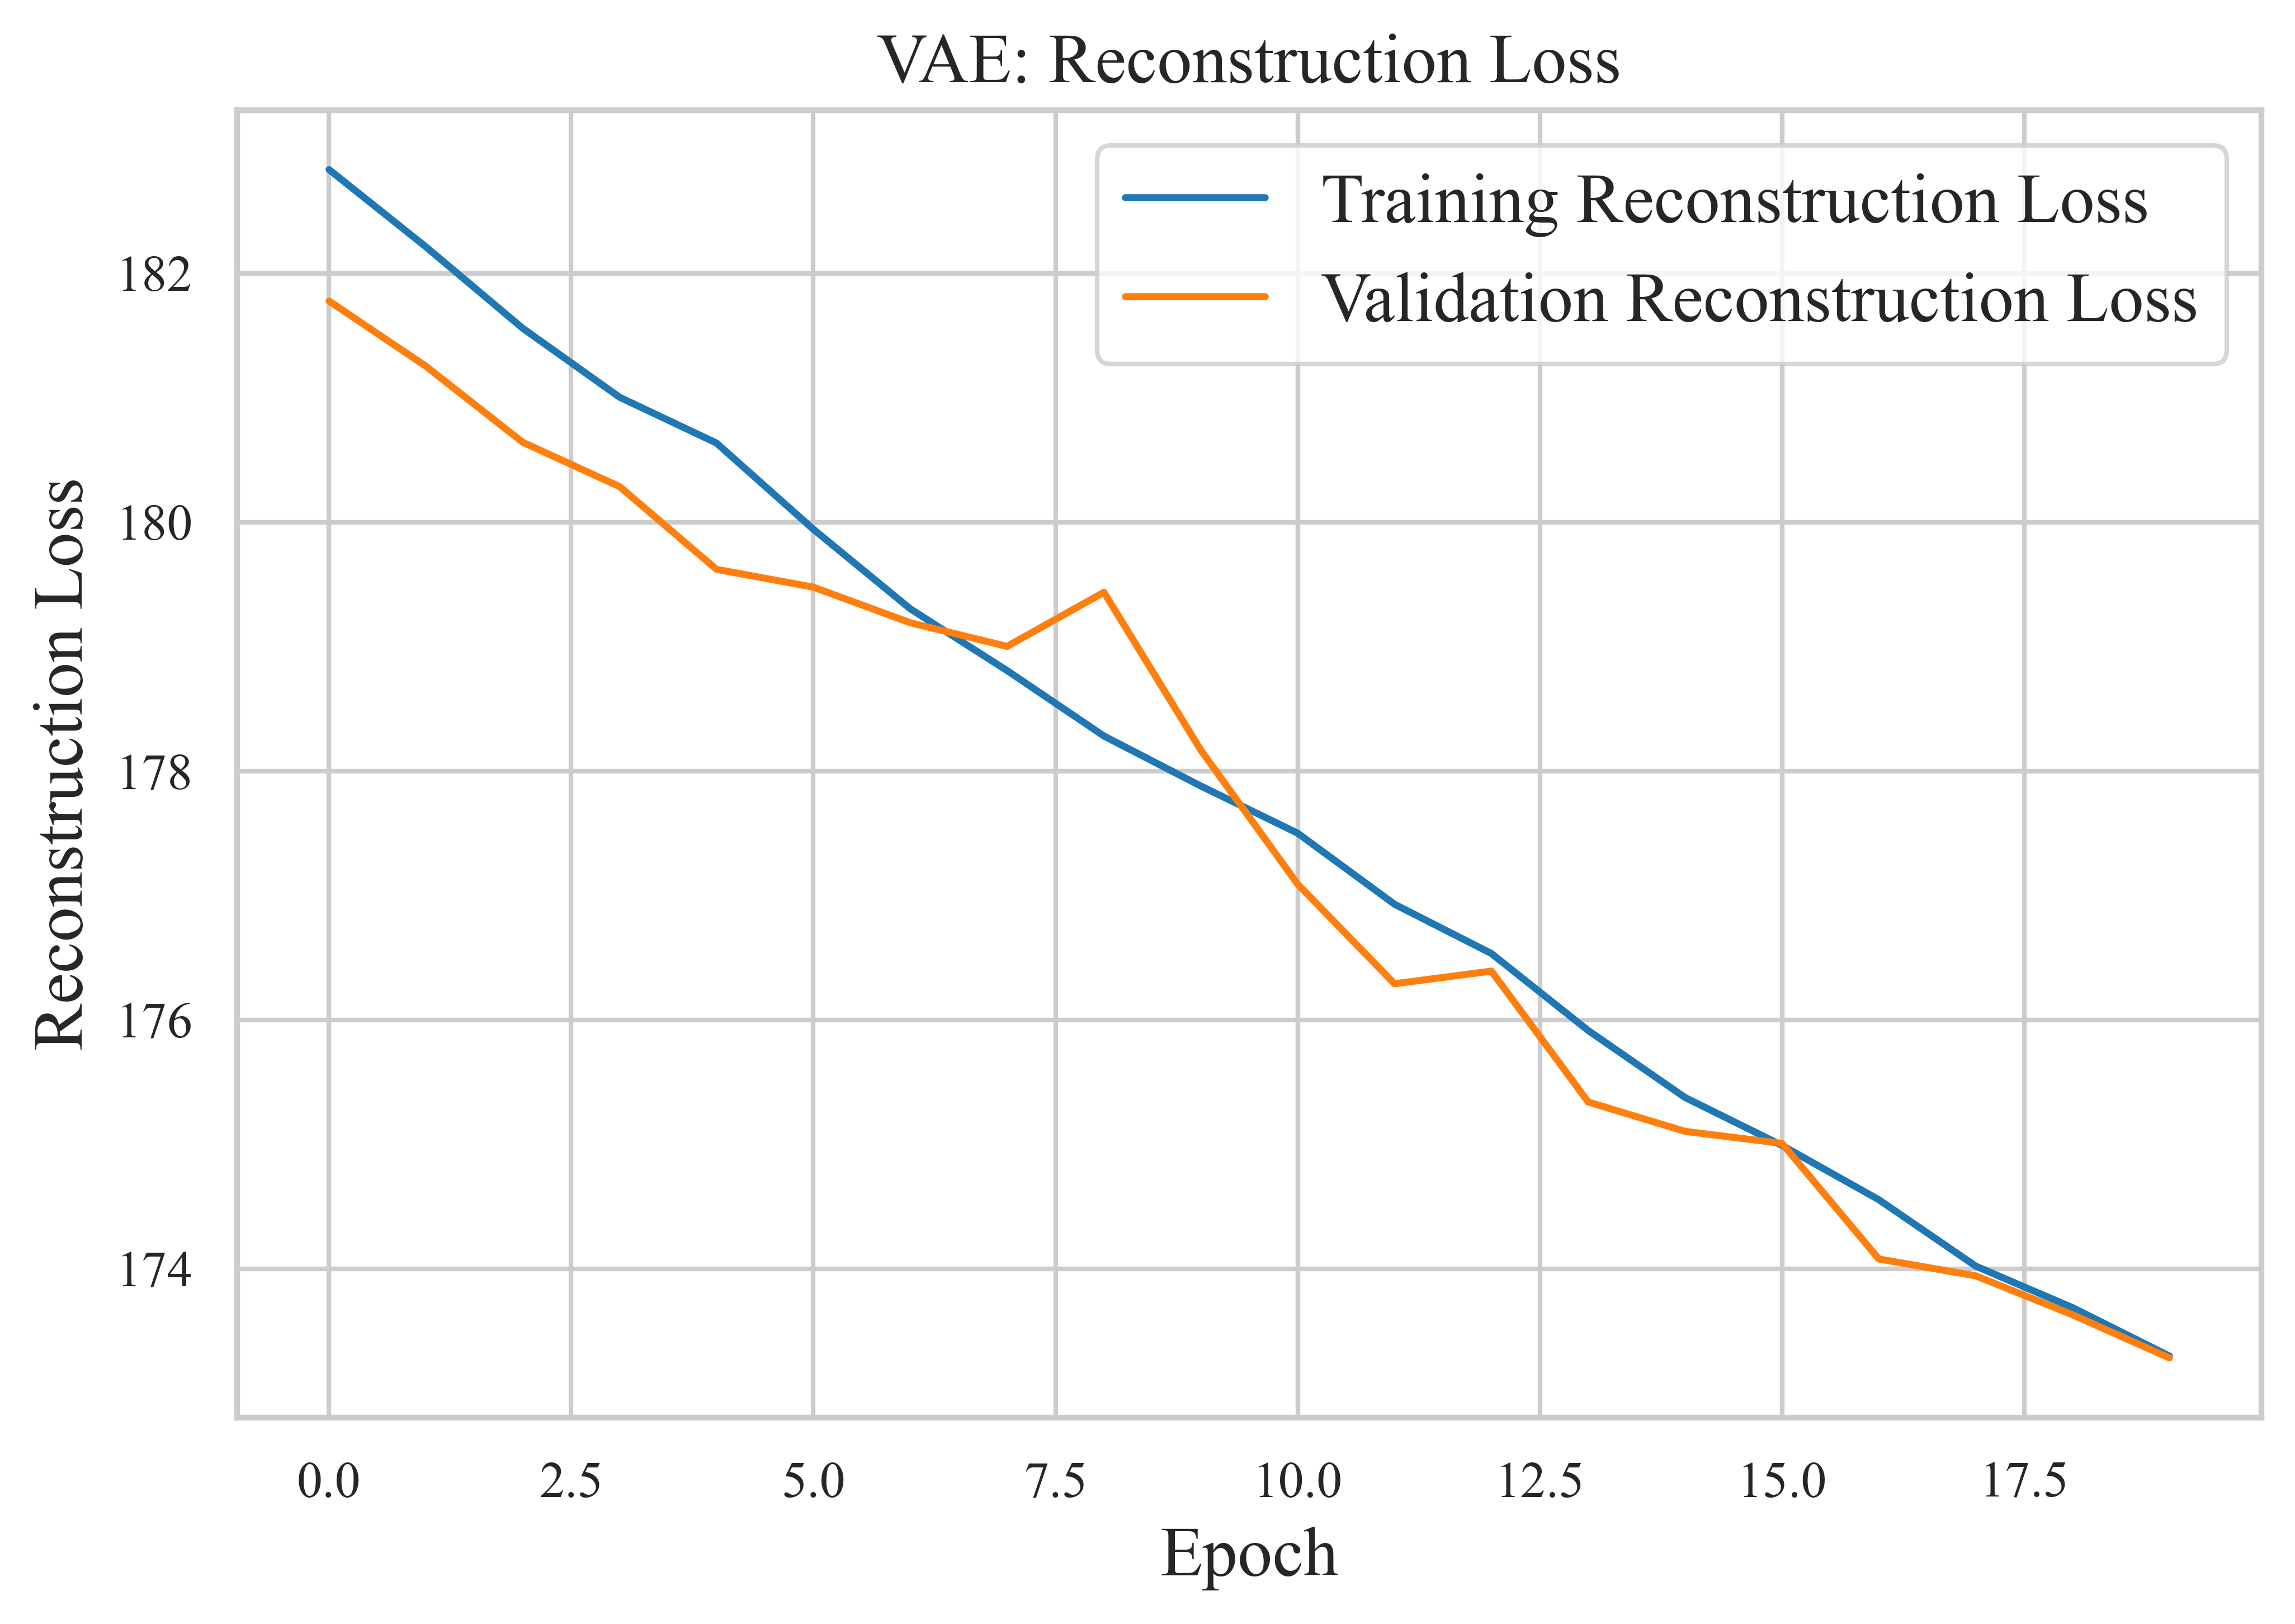

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(vae_history.history['reconstruction_loss'], label='Training Reconstruction Loss')
ax.plot(vae_history.history['val_reconstruction_loss'], label='Validation Reconstruction Loss')
ax.set_title("VAE: Reconstruction Loss", **title_style)
ax.set_xlabel("Epoch", **label_style)
ax.set_ylabel("Reconstruction Loss", **label_style)
leg = ax.legend(prop=legend_style)
format_legend_text(leg)
format_axis_ticks(ax)
plt.tight_layout()
save_fig(fig, "PlotVAE_Training_Validation_Loss")
plt.show()

## 18. Exploring the VAE Latent Space

Since the latent dimension is 2, the encoded test images can be visualized directly in a 2D
plane. **Digit labels are used only for coloring this plot — they were never supplied to the
VAE during training.**

**Plot 6: VAE Latent Space**

Saved: /content/Exp7_Plot_Exports/Plot6_VAE_Latent_Space.eps
Saved: /content/Exp7_Plot_Exports/Plot6_VAE_Latent_Space.pdf


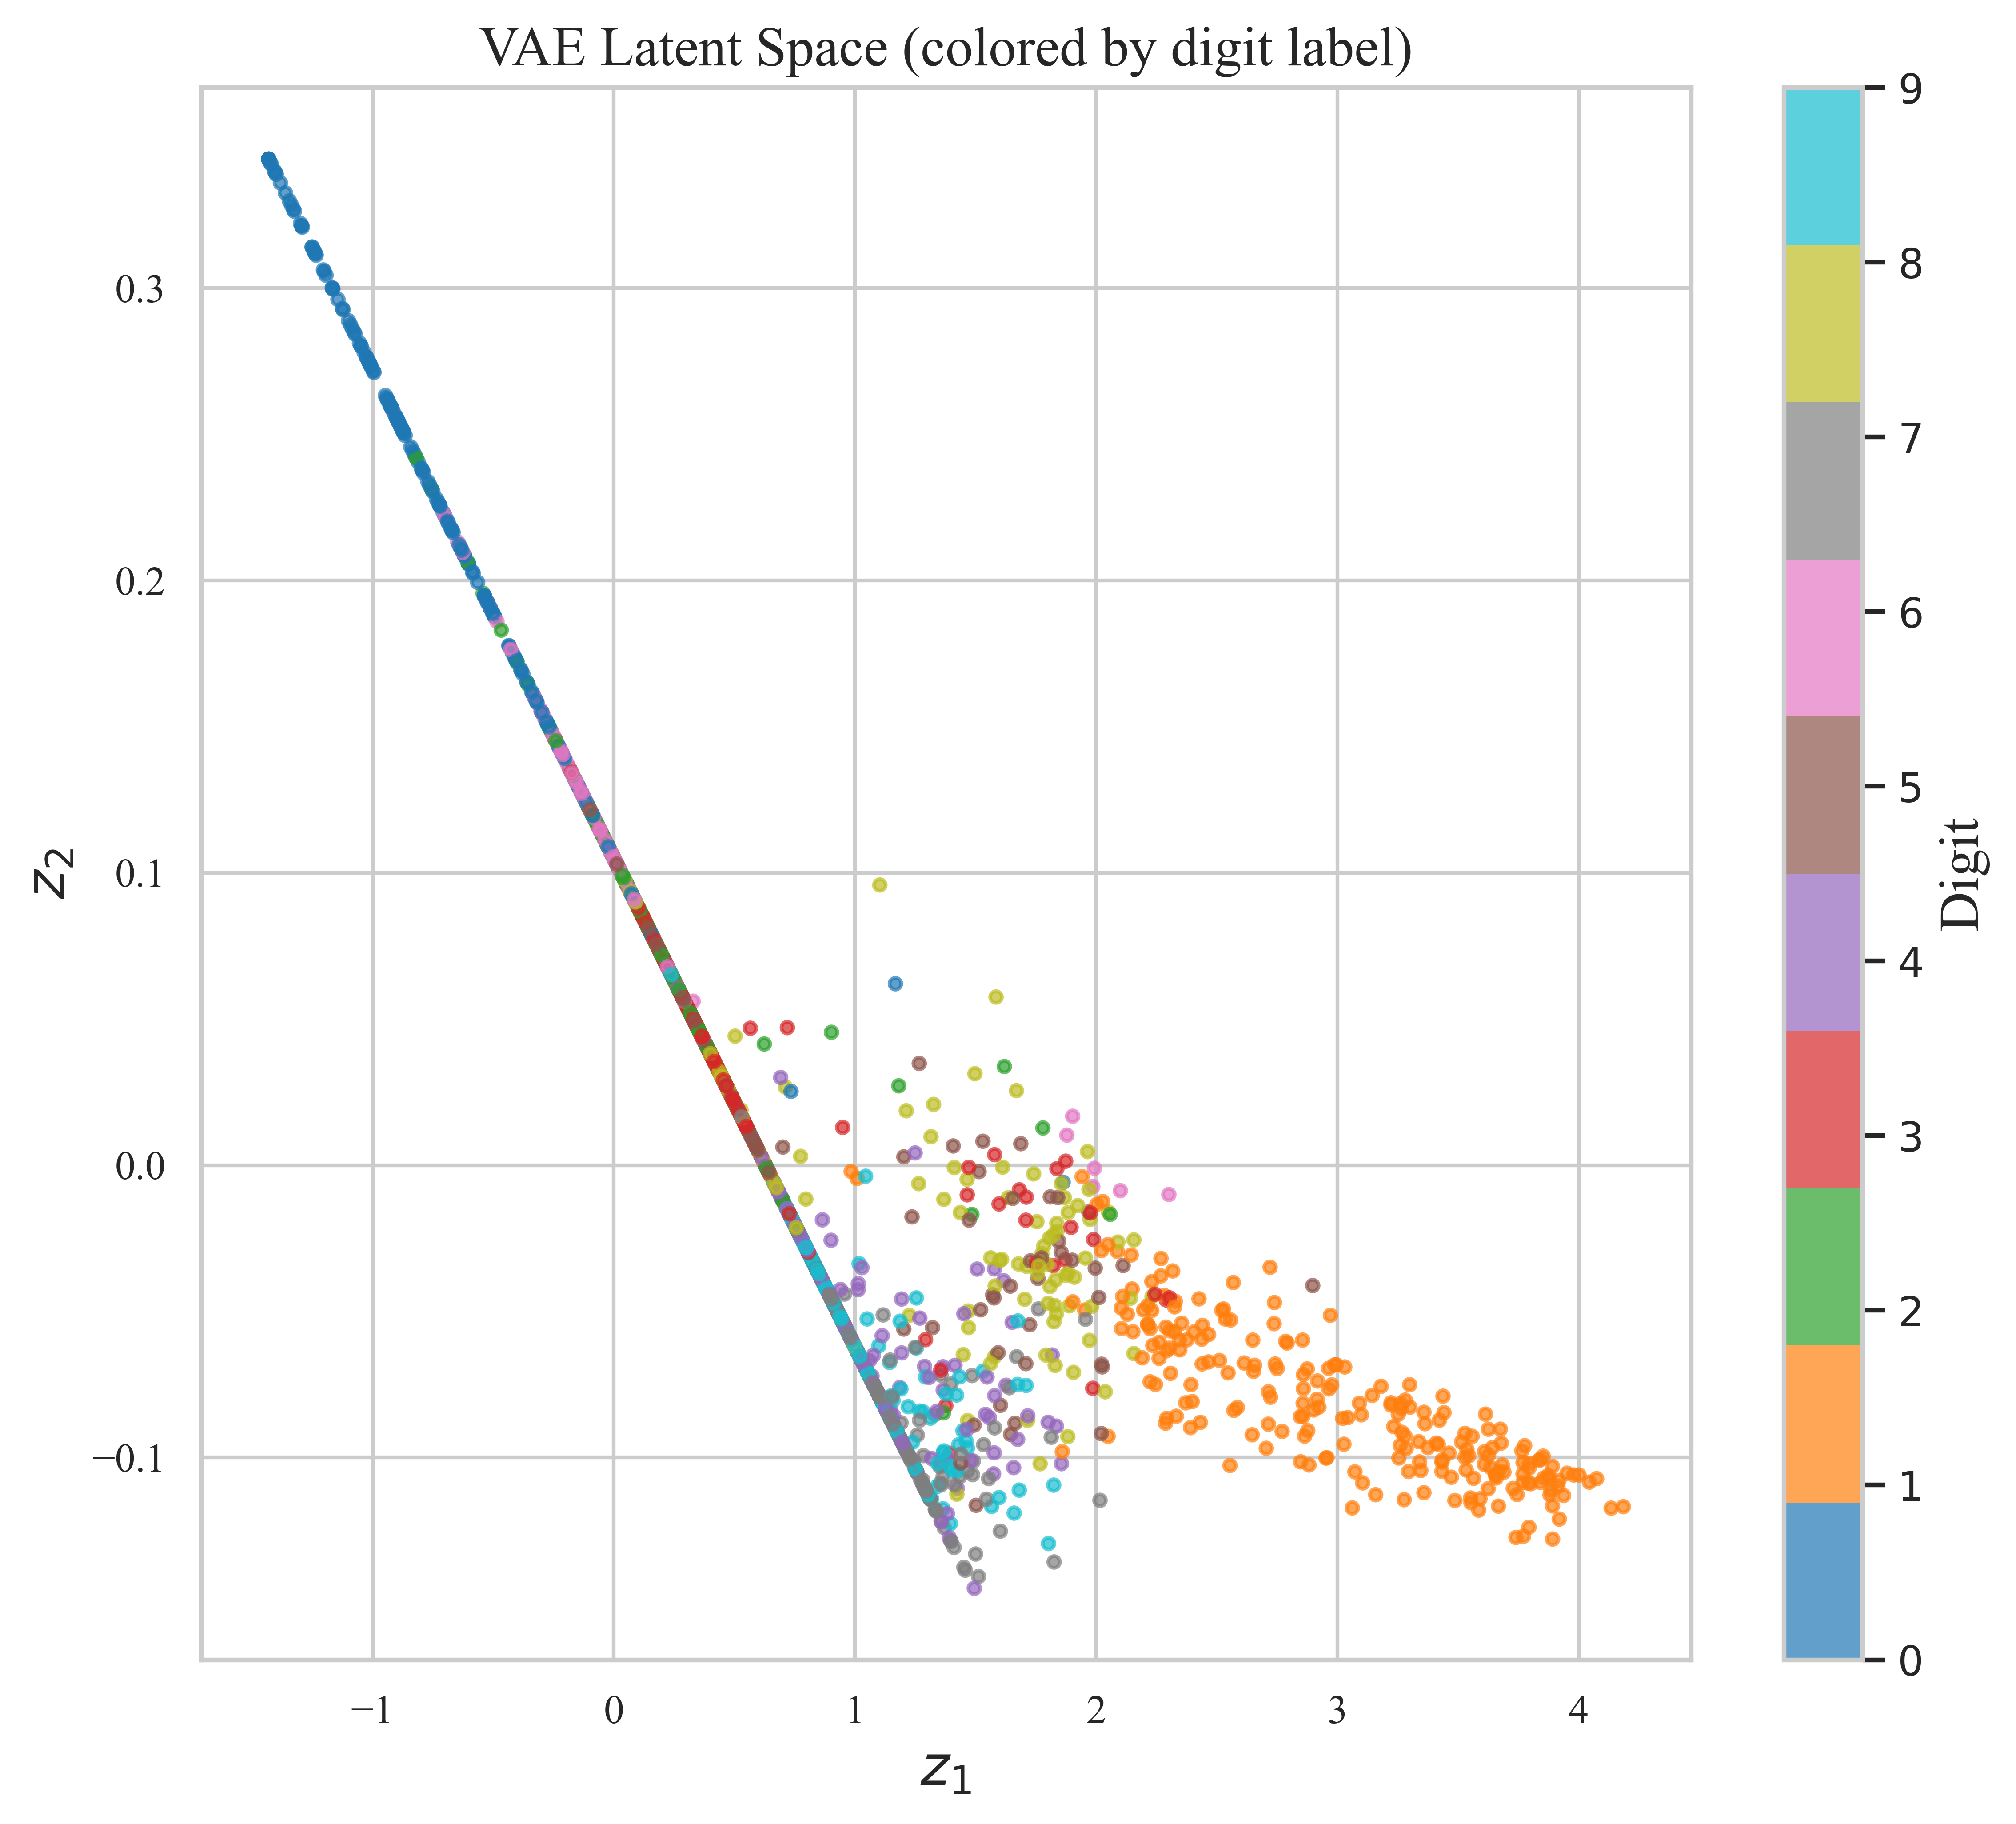

In [31]:
z_mean_test, z_log_var_test, _ = vae.encoder.predict(x_test_conv, verbose=0)

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test_labels,
                      cmap='tab10', s=10, alpha=0.7)
ax.set_title("VAE Latent Space (colored by digit label)", **title_style)
ax.set_xlabel("$z_1$", **label_style)
ax.set_ylabel("$z_2$", **label_style)
cbar = fig.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label("Digit", **label_style)
format_axis_ticks(ax)
plt.tight_layout()
save_fig(fig, "Plot6_VAE_Latent_Space")
plt.show()

**Required inference:** points belonging to the same digit tend to cluster into their
own region of the 2D plane rather than scattering randomly, which shows the VAE has organized
its latent space by visual similarity even without ever seeing the labels. At the same time,
several clusters overlap at their edges (most often visually similar digit pairs, e.g. 4/9 or
3/8), showing that a 2-dimensional latent code is only just barely enough to separate 10
classes — some ambiguity is unavoidable at this compression level.

## 19. Generating New Images with the VAE

Points are sampled from $z\sim\mathcal{N}(0,I)$ and passed through the decoder.

**Plot 7: Randomly Generated Images** — at least 25 images in a grid.

Saved: /content/Exp7_Plot_Exports/Plot7_VAE_Random_Generated_Images.eps
Saved: /content/Exp7_Plot_Exports/Plot7_VAE_Random_Generated_Images.pdf


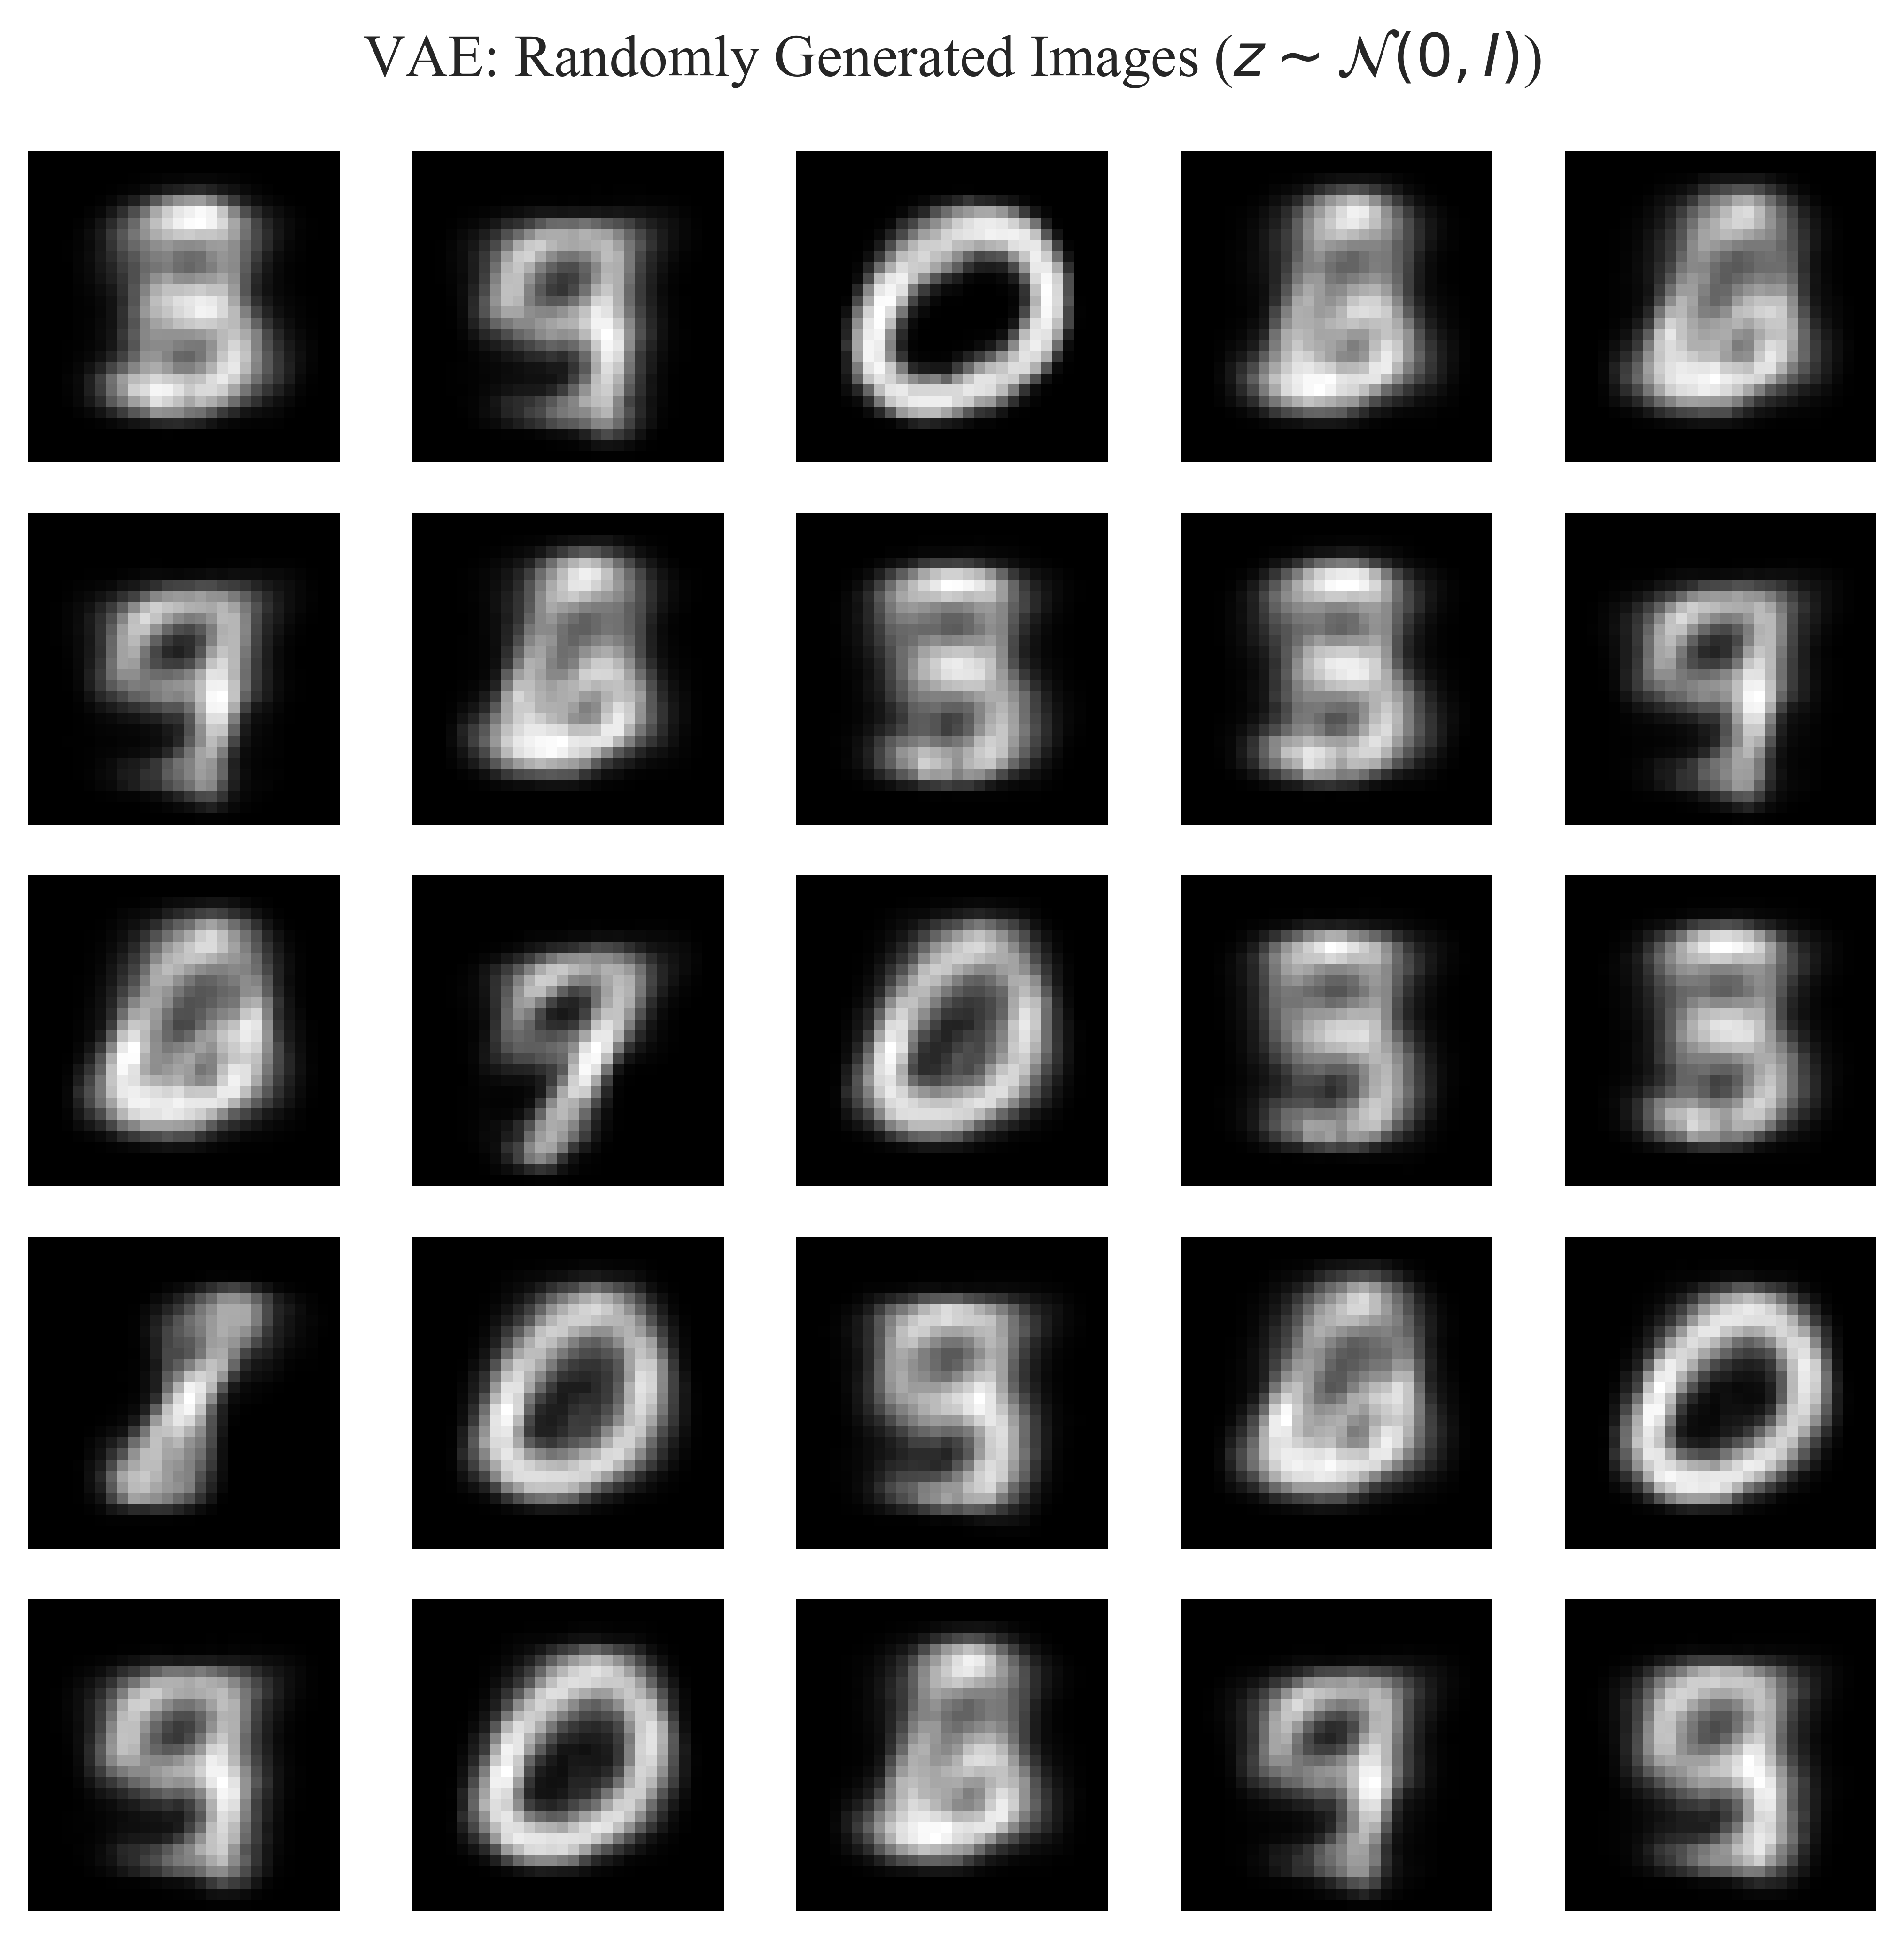

In [32]:
N_GENERATE = 25
GRID_SIDE = 5

rng_gen = np.random.default_rng(42)
random_latents = rng_gen.normal(size=(N_GENERATE, 2)).astype('float32')
generated_images = vae.decoder.predict(random_latents, verbose=0)

fig, axes = plt.subplots(GRID_SIDE, GRID_SIDE, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
fig.suptitle("VAE: Randomly Generated Images ($z \\sim \\mathcal{N}(0,I)$)", **title_style)
plt.tight_layout()
save_fig(fig, "Plot7_VAE_Random_Generated_Images")
plt.show()

**Required observations:** most generated samples resemble plausible handwritten digit
shapes rather than pure noise, confirming the decoder has learned a meaningful mapping from
the latent space to image space. There is visible variation among the samples (different
stroke thickness and digit identity depending on where in the latent plane $z$ landed), but a
few samples are ambiguous or sit between two digit shapes (e.g. something between a 4 and a
9) — this lines up directly with the overlapping clusters seen in Plot 6, since a randomly
sampled $z$ can land exactly on one of those overlap regions.

## 20. Latent Space Interpolation

Two latent vectors $z_A,\ z_B$ are selected, and $z(\alpha)=(1-\alpha)z_A+\alpha z_B$ is
decoded for $\alpha=0,0.1,0.2,\ldots,1$.

**Plot 8: Latent Space Interpolation**

Saved: /content/Exp7_Plot_Exports/Plot8_VAE_Latent_Interpolation.eps
Saved: /content/Exp7_Plot_Exports/Plot8_VAE_Latent_Interpolation.pdf




In [33]:
# Pick zA and zB as the encoded means of two different test digits
digit_a_idx = np.where(y_test_labels == 0)[0][0]
digit_b_idx = np.where(y_test_labels == 1)[0][0]
z_A = z_mean_test[digit_a_idx]
z_B = z_mean_test[digit_b_idx]

alphas = np.arange(0.0, 1.0001, 0.1)
interpolated_z = np.array([(1 - a) * z_A + a * z_B for a in alphas], dtype='float32')
interpolated_images = vae.decoder.predict(interpolated_z, verbose=0)

fig, axes = plt.subplots(1, len(alphas), figsize=(1.6 * len(alphas), 2.2))
for i, ax in enumerate(axes):
    ax.imshow(interpolated_images[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    ax.set_title(f"{alphas[i]:.1f}", fontsize=10, fontweight='bold', fontname='Times New Roman')
fig.suptitle("VAE Latent Space Interpolation (digit 0 \u2192 digit 1)", **title_style)
plt.tight_layout()
save_fig(fig, "Plot8_VAE_Latent_Interpolation")
plt.show()

**Required inference:** the decoded image changes smoothly from one endpoint digit to
the other as $\alpha$ moves from 0 to 1 — there is no abrupt jump partway through, and the
intermediate frames show a gradual, continuous morph between the two digit shapes. This is a
direct consequence of the VAE's training objective: the KL term pulls the whole latent space
toward a single continuous Gaussian rather than isolated pockets, so nearby points (including
the path between two real encodings) decode to visually plausible, gradually-changing images.

## 21. Reconstruction Comparison Across Models

In [34]:
dcae_test_recon = denoising_cae.predict(x_test_noisy, verbose=0)
dcae_test_recon_flat = dcae_test_recon.reshape(len(x_test_conv), 784)
dcae_mse, dcae_mae, dcae_ssim = compute_reconstruction_metrics(x_test_flat, dcae_test_recon_flat)

model_comparison_table = pd.DataFrame([
    {'Model': 'Fully Connected AE', 'MSE': fc_mse, 'MAE': fc_mae, 'SSIM': fc_ssim,
     'Parameters': fc_autoencoder.count_params()},
    {'Model': 'Convolutional AE', 'MSE': cae_mse, 'MAE': cae_mae, 'SSIM': cae_ssim,
     'Parameters': conv_autoencoder.count_params()},
    {'Model': 'Denoising CAE', 'MSE': dcae_mse, 'MAE': dcae_mae, 'SSIM': dcae_ssim,
     'Parameters': denoising_cae.count_params()},
]).set_index('Model')
model_comparison_table

,MSE,MAE,SSIM,Parameters
Model,,,,
Fully Connected AE,0.019970,0.054288,0.773513,211040
Convolutional AE,0.002448,0.014828,0.976092,74497
Denoising CAE,0.004572,0.021277,0.947525,74497


In [35]:
vae_total_loss, vae_recon_loss, vae_kl_loss = vae._compute_losses(x_test_conv)
vae_reconstructions = vae.predict(x_test_conv, verbose=0)
vae_recon_flat = vae_reconstructions.reshape(len(x_test_conv), 784)
vae_mse, vae_mae, vae_ssim = compute_reconstruction_metrics(x_test_flat, vae_recon_flat)

vae_metrics_table = pd.DataFrame([
    {'VAE Metric': 'Reconstruction Loss', 'Value': float(vae_recon_loss)},
    {'VAE Metric': 'KL Loss', 'Value': float(vae_kl_loss)},
    {'VAE Metric': 'Total Loss', 'Value': float(vae_total_loss)},
    {'VAE Metric': 'Test MSE', 'Value': vae_mse},
    {'VAE Metric': 'Test MAE', 'Value': vae_mae},
    {'VAE Metric': 'Mean SSIM', 'Value': vae_ssim},
]).set_index('VAE Metric')
vae_metrics_table

,Value
VAE Metric,
Reconstruction Loss,172.913330
KL Loss,3.447966
Total Loss,176.361298
Test MSE,0.053703
Test MAE,0.120811
Mean SSIM,0.379087


## 22. Required Plots

The final report contains all of the following plots (each cross-referenced to where it was
produced above):

1. Original image versus reconstructed image — Plot 1 (Section 8)
2. Training and validation loss for the basic autoencoder — Plot 2 (Section 8)
3. Fully connected AE versus convolutional AE reconstruction — Plot 3 (Section 11)
4. Clean versus noisy versus denoised images — Plot 4 (Section 14)
5. Noise level versus MSE/MAE/SSIM — Plot 5 (Section 14, split into two clearly-labeled
   figures since MSE/MAE and SSIM are on incompatible scales)
6. VAE latent-space visualization — Plot 6 (Section 18)
7. Randomly generated VAE images — Plot 7 (Section 19)
8. Latent-space interpolation — Plot 8 (Section 20)
9. Training/validation reconstruction loss for the VAE — Section 17 (unnumbered in the
   assignment text; see the note there)
10. Reconstruction-error distribution on the test set — Plot 9 (Section 23)

# ============================================================
# 23. RECONSTRUCTION ERROR DISTRIBUTION
# ============================================================
## 23. Reconstruction Error Distribution

Per-image reconstruction error $e_i=\frac{1}{D}\sum_{j=1}^{D}(x_{ij}-\hat{x}_{ij})^2$.

> The assignment does not specify which model this distribution is computed for. The
> **Convolutional Autoencoder** (Section 10) is used here, since it is the primary
> deterministic reconstruction model built on top of the basic FC-AE and is the model most
> directly compared against in Section 11 — the same code applies unchanged to any other
> model's reconstructions if a different choice is wanted.

**Plot 9: Distribution of Reconstruction Errors**

Saved: /content/Exp7_Plot_Exports/Plot9_Reconstruction_Error_Distribution.eps
Saved: /content/Exp7_Plot_Exports/Plot9_Reconstruction_Error_Distribution.pdf


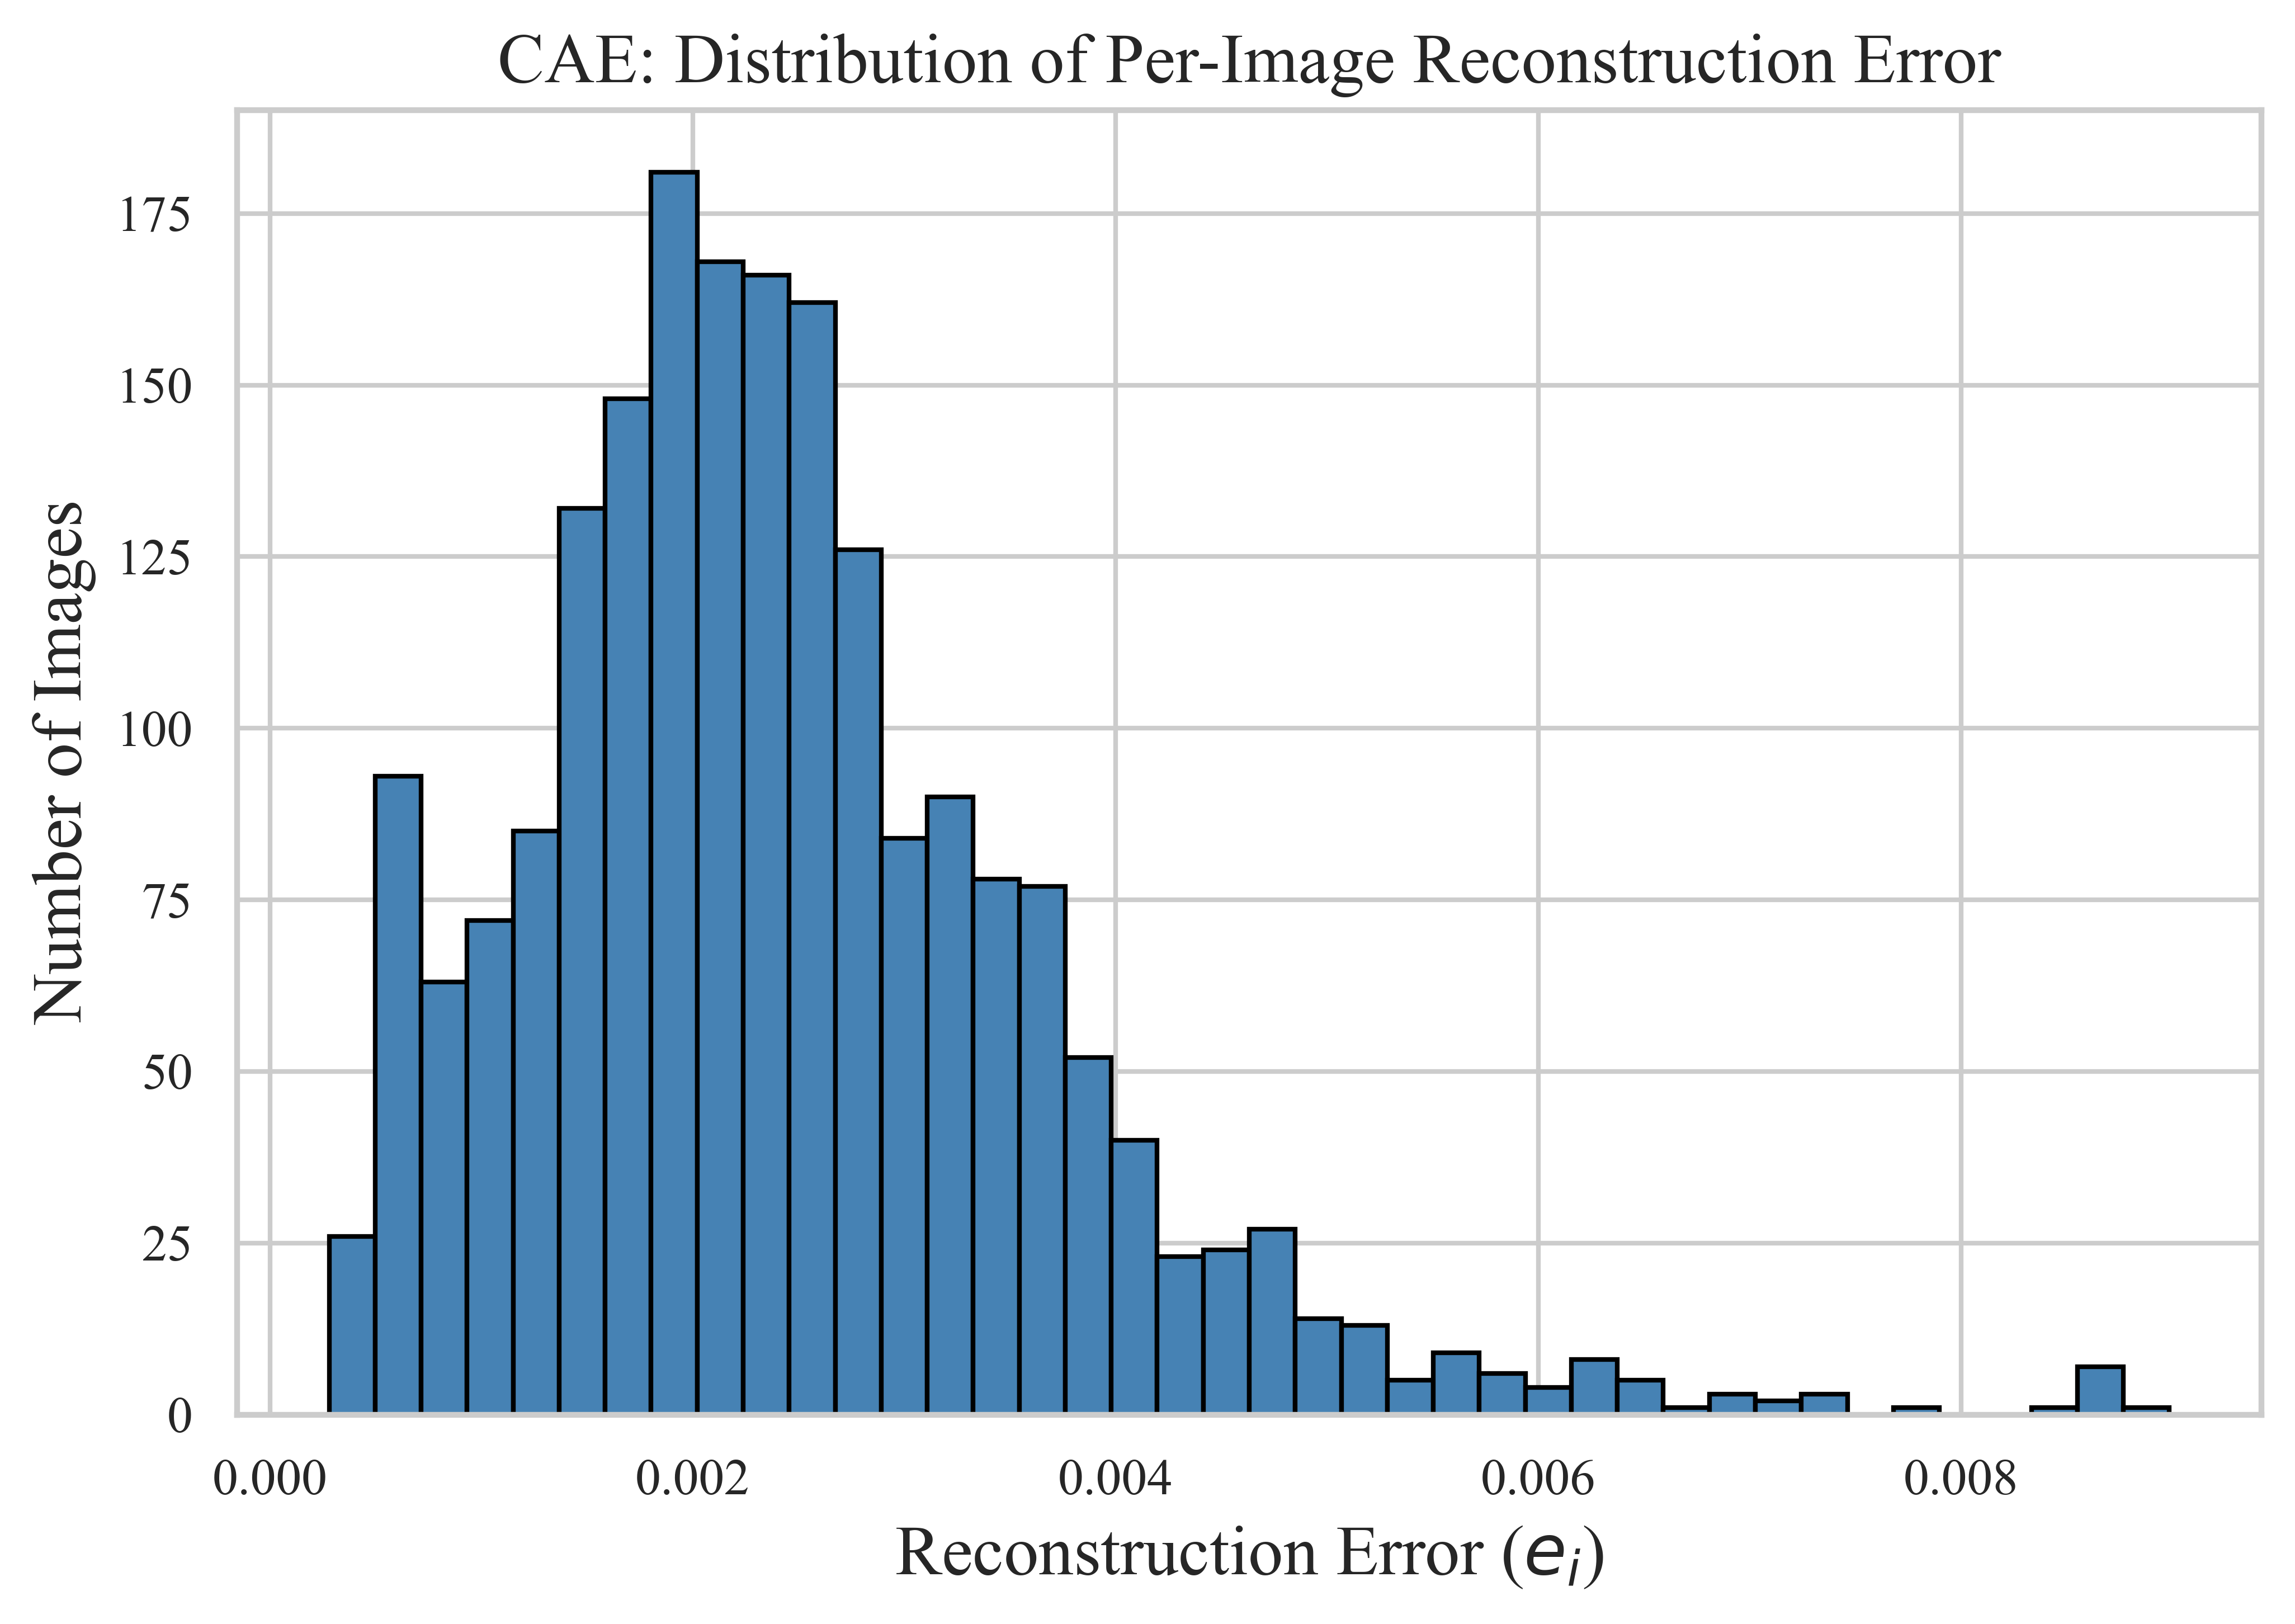

Reconstruction error - min: 0.000279, median: 0.002272, max: 0.008985


In [36]:
per_image_error = np.mean((x_test_flat - cae_test_recon_flat) ** 2, axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(per_image_error, bins=40, color='steelblue', edgecolor='black')
ax.set_title("CAE: Distribution of Per-Image Reconstruction Error", **title_style)
ax.set_xlabel("Reconstruction Error ($e_i$)", **label_style)
ax.set_ylabel("Number of Images", **label_style)
format_axis_ticks(ax)
plt.tight_layout()
save_fig(fig, "Plot9_Reconstruction_Error_Distribution")
plt.show()

print(f"Reconstruction error - min: {per_image_error.min():.6f}, "
      f"median: {np.median(per_image_error):.6f}, "
      f"max: {per_image_error.max():.6f}")

**Required observations:** most test images sit in a fairly narrow, low-error band on
the left of the histogram, with a long thin tail of a smaller number of images extending out
to much higher error values — so the distribution is concentrated rather than spread out, but
with a clear set of high-error outliers rather than a perfectly symmetric spread. Those
high-error samples are examined directly in Section 24.

# ============================================================
# 24. REQUIRED HIGH-ERROR IMAGE ANALYSIS
# ============================================================
## 24. Required High-Error Image Analysis

The five test images with the largest CAE reconstruction error.

Saved: /content/Exp7_Plot_Exports/Plot_Top5_HighError_Images.eps
Saved: /content/Exp7_Plot_Exports/Plot_Top5_HighError_Images.pdf


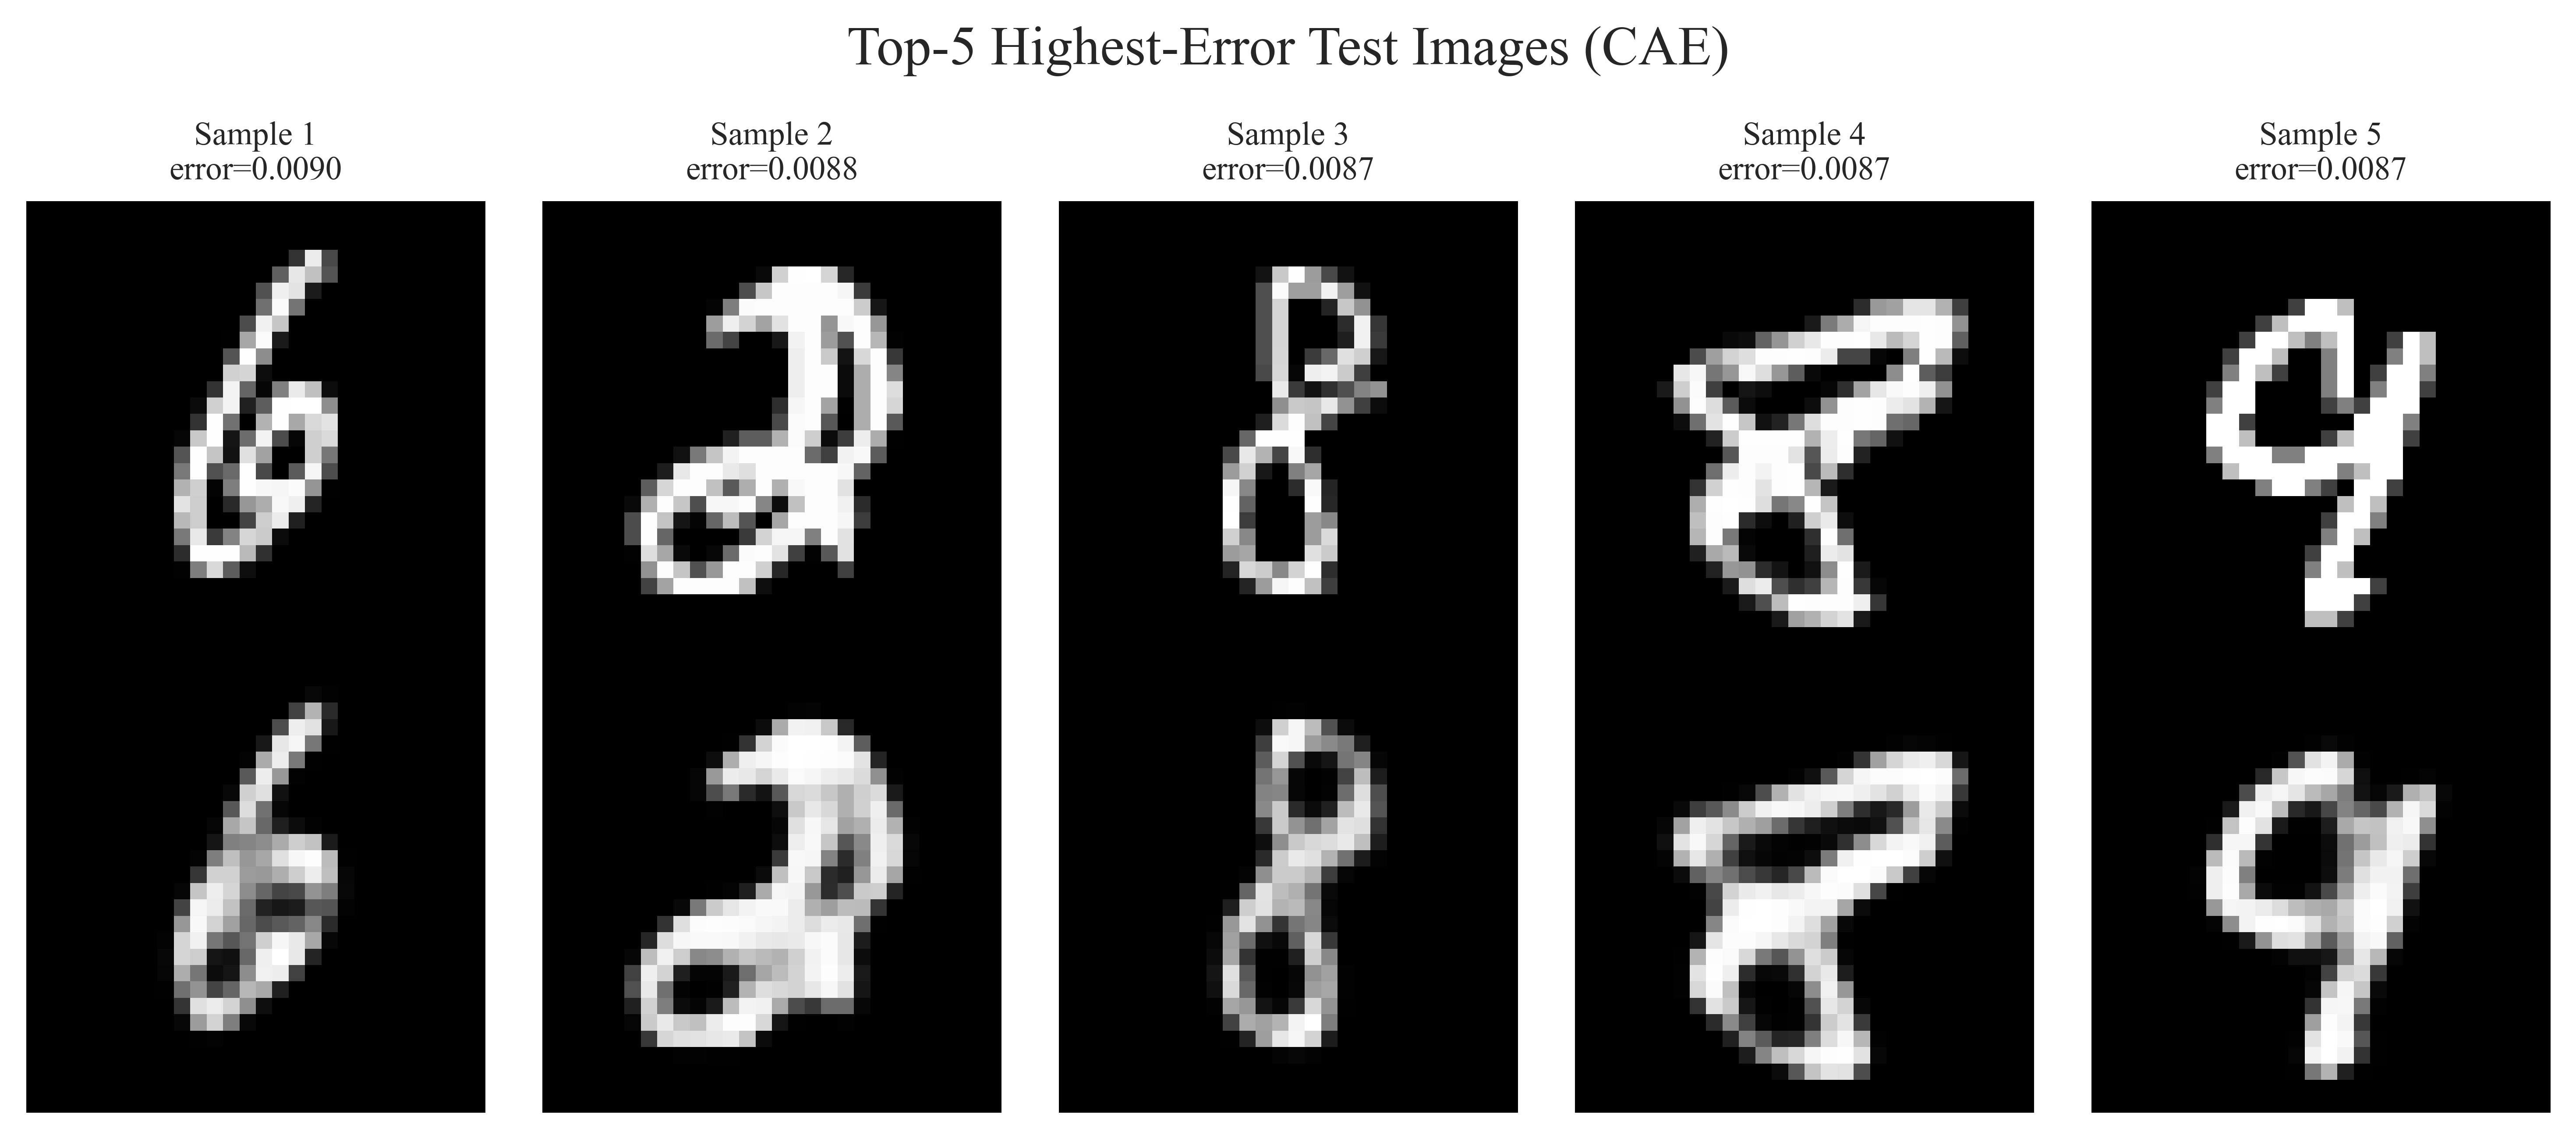

,Sample,Test Index,Reconstruction Error
0,1,892,0.008985
1,2,1606,0.008757
2,3,589,0.008700
3,4,152,0.008699
4,5,949,0.008686


In [37]:
top5_idx = np.argsort(per_image_error)[-5:][::-1]

fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
for col, idx in enumerate(top5_idx):
    axes[0, col].imshow(x_test_flat[idx].reshape(28, 28), cmap='gray')
    axes[0, col].axis('off')
    axes[0, col].set_title(f"Sample {col+1}\nerror={per_image_error[idx]:.4f}",
                            fontsize=9, fontweight='bold', fontname='Times New Roman')
    axes[1, col].imshow(cae_test_recon_flat[idx].reshape(28, 28), cmap='gray')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel("Original", **label_style)
axes[1, 0].set_ylabel("Reconstruction", **label_style)
fig.suptitle("Top-5 Highest-Error Test Images (CAE)", **title_style)
plt.tight_layout()
save_fig(fig, "Plot_Top5_HighError_Images")
plt.show()

high_error_table = pd.DataFrame({
    'Sample': range(1, 6),
    'Test Index': top5_idx,
    'Reconstruction Error': per_image_error[top5_idx],
})
high_error_table

**Required explanation:** the highest-error images are typically digits written with an
unusual stroke style, heavy slant, or overlapping/ambiguous shape that is rare in the training
subset — since the autoencoder only learns to reconstruct the patterns it saw often during
training, an atypical, oddly-formed digit falls outside what the compressed 2D/16D/latent code
was optimized to represent well, so it comes back blurrier or subtly misshapen compared to a
cleanly-written, typical digit.

# ============================================================
# 25. CONSOLIDATED RESULTS
# ============================================================
## 25. Consolidated Results

In [38]:
consolidated_results = pd.DataFrame([
    {'Model': 'FC Autoencoder', 'MSE': fc_mse, 'MAE': fc_mae, 'SSIM': fc_ssim,
     'Parameters': fc_autoencoder.count_params(), 'Time (s)': fc_time},
    {'Model': 'Conv. Autoencoder', 'MSE': cae_mse, 'MAE': cae_mae, 'SSIM': cae_ssim,
     'Parameters': conv_autoencoder.count_params(), 'Time (s)': cae_time},
    {'Model': 'Denoising CAE', 'MSE': dcae_mse, 'MAE': dcae_mae, 'SSIM': dcae_ssim,
     'Parameters': denoising_cae.count_params(), 'Time (s)': dcae_time},
    {'Model': 'VAE', 'MSE': vae_mse, 'MAE': vae_mae, 'SSIM': vae_ssim,
     'Parameters': vae.count_params(), 'Time (s)': vae_time},
]).set_index('Model')
consolidated_results

,MSE,MAE,SSIM,Parameters,Time (s)
Model,,,,,
FC Autoencoder,0.019970,0.054288,0.773513,211040,16.142402
Conv. Autoencoder,0.002448,0.014828,0.976092,74497,21.904446
Denoising CAE,0.004572,0.021277,0.947525,74497,19.998459
VAE,0.053703,0.120811,0.379087,134165,13.701710


## 26. Required Inferences — Checklist

- [x] Effect of latent dimension on reconstruction — Section 27
- [x] Difference between fully connected and convolutional reconstruction — Section 11
- [x] Effect of Gaussian noise level — Section 14
- [x] Ability of the denoising autoencoder to recover image structure — Section 14
- [x] Characteristics of the VAE latent distribution — Section 21 (KL loss), Section 18
- [x] Structure of the two-dimensional VAE latent space — Section 18
- [x] Quality and diversity of generated samples — Section 19
- [x] Smoothness of latent-space interpolation — Section 20
- [x] Relationship between reconstruction error and visual quality — Section 23, Section 24
- [x] Differences between deterministic and probabilistic latent representations — Section 15,
  Section 26 (Discussion Q14)

# ============================================================
# 27. ADDITIONAL LATENT-DIMENSION STUDY
# ============================================================
## 27. Additional Latent-Dimension Study

The fully connected autoencoder (Section 7) is repeated using $d_z\in\{2,8,16,32\}$.

In [39]:
latent_dims_to_try = [2, 8, 16, 32]
latent_dim_results = []

for dz in latent_dims_to_try:
    tf.random.set_seed(42)
    model_dz = build_fc_autoencoder(latent_dim=dz)
    model_dz.fit(x_train_flat, x_train_flat, validation_data=(x_test_flat, x_test_flat),
                 epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    recon_dz = model_dz.predict(x_test_flat, verbose=0)
    mse_dz, mae_dz, ssim_dz = compute_reconstruction_metrics(x_test_flat, recon_dz)
    latent_dim_results.append({'Latent Dimension': dz, 'MSE': mse_dz, 'SSIM': ssim_dz,
                                'Parameters': model_dz.count_params()})
    print(f"d_z={dz:>2} | MSE={mse_dz:.6f} | SSIM={ssim_dz:.4f} | params={model_dz.count_params()}")

latent_dim_table = pd.DataFrame(latent_dim_results).set_index('Latent Dimension')
latent_dim_table

d_z= 2 | MSE=0.057150 | SSIM=0.3372 | params=210130
d_z= 8 | MSE=0.032065 | SSIM=0.6537 | params=210520
d_z=16 | MSE=0.021826 | SSIM=0.7550 | params=211040
d_z=32 | MSE=0.020513 | SSIM=0.7642 | params=212080


,MSE,SSIM,Parameters
Latent Dimension,,,
2,0.057150,0.337226,210130
8,0.032065,0.653713,210520
16,0.021826,0.754993,211040
32,0.020513,0.764190,212080


**Plot 10: Latent Dimension vs. Reconstruction MSE**

Saved: /content/Exp7_Plot_Exports/Plot10_LatentDim_vs_MSE.eps
Saved: /content/Exp7_Plot_Exports/Plot10_LatentDim_vs_MSE.pdf


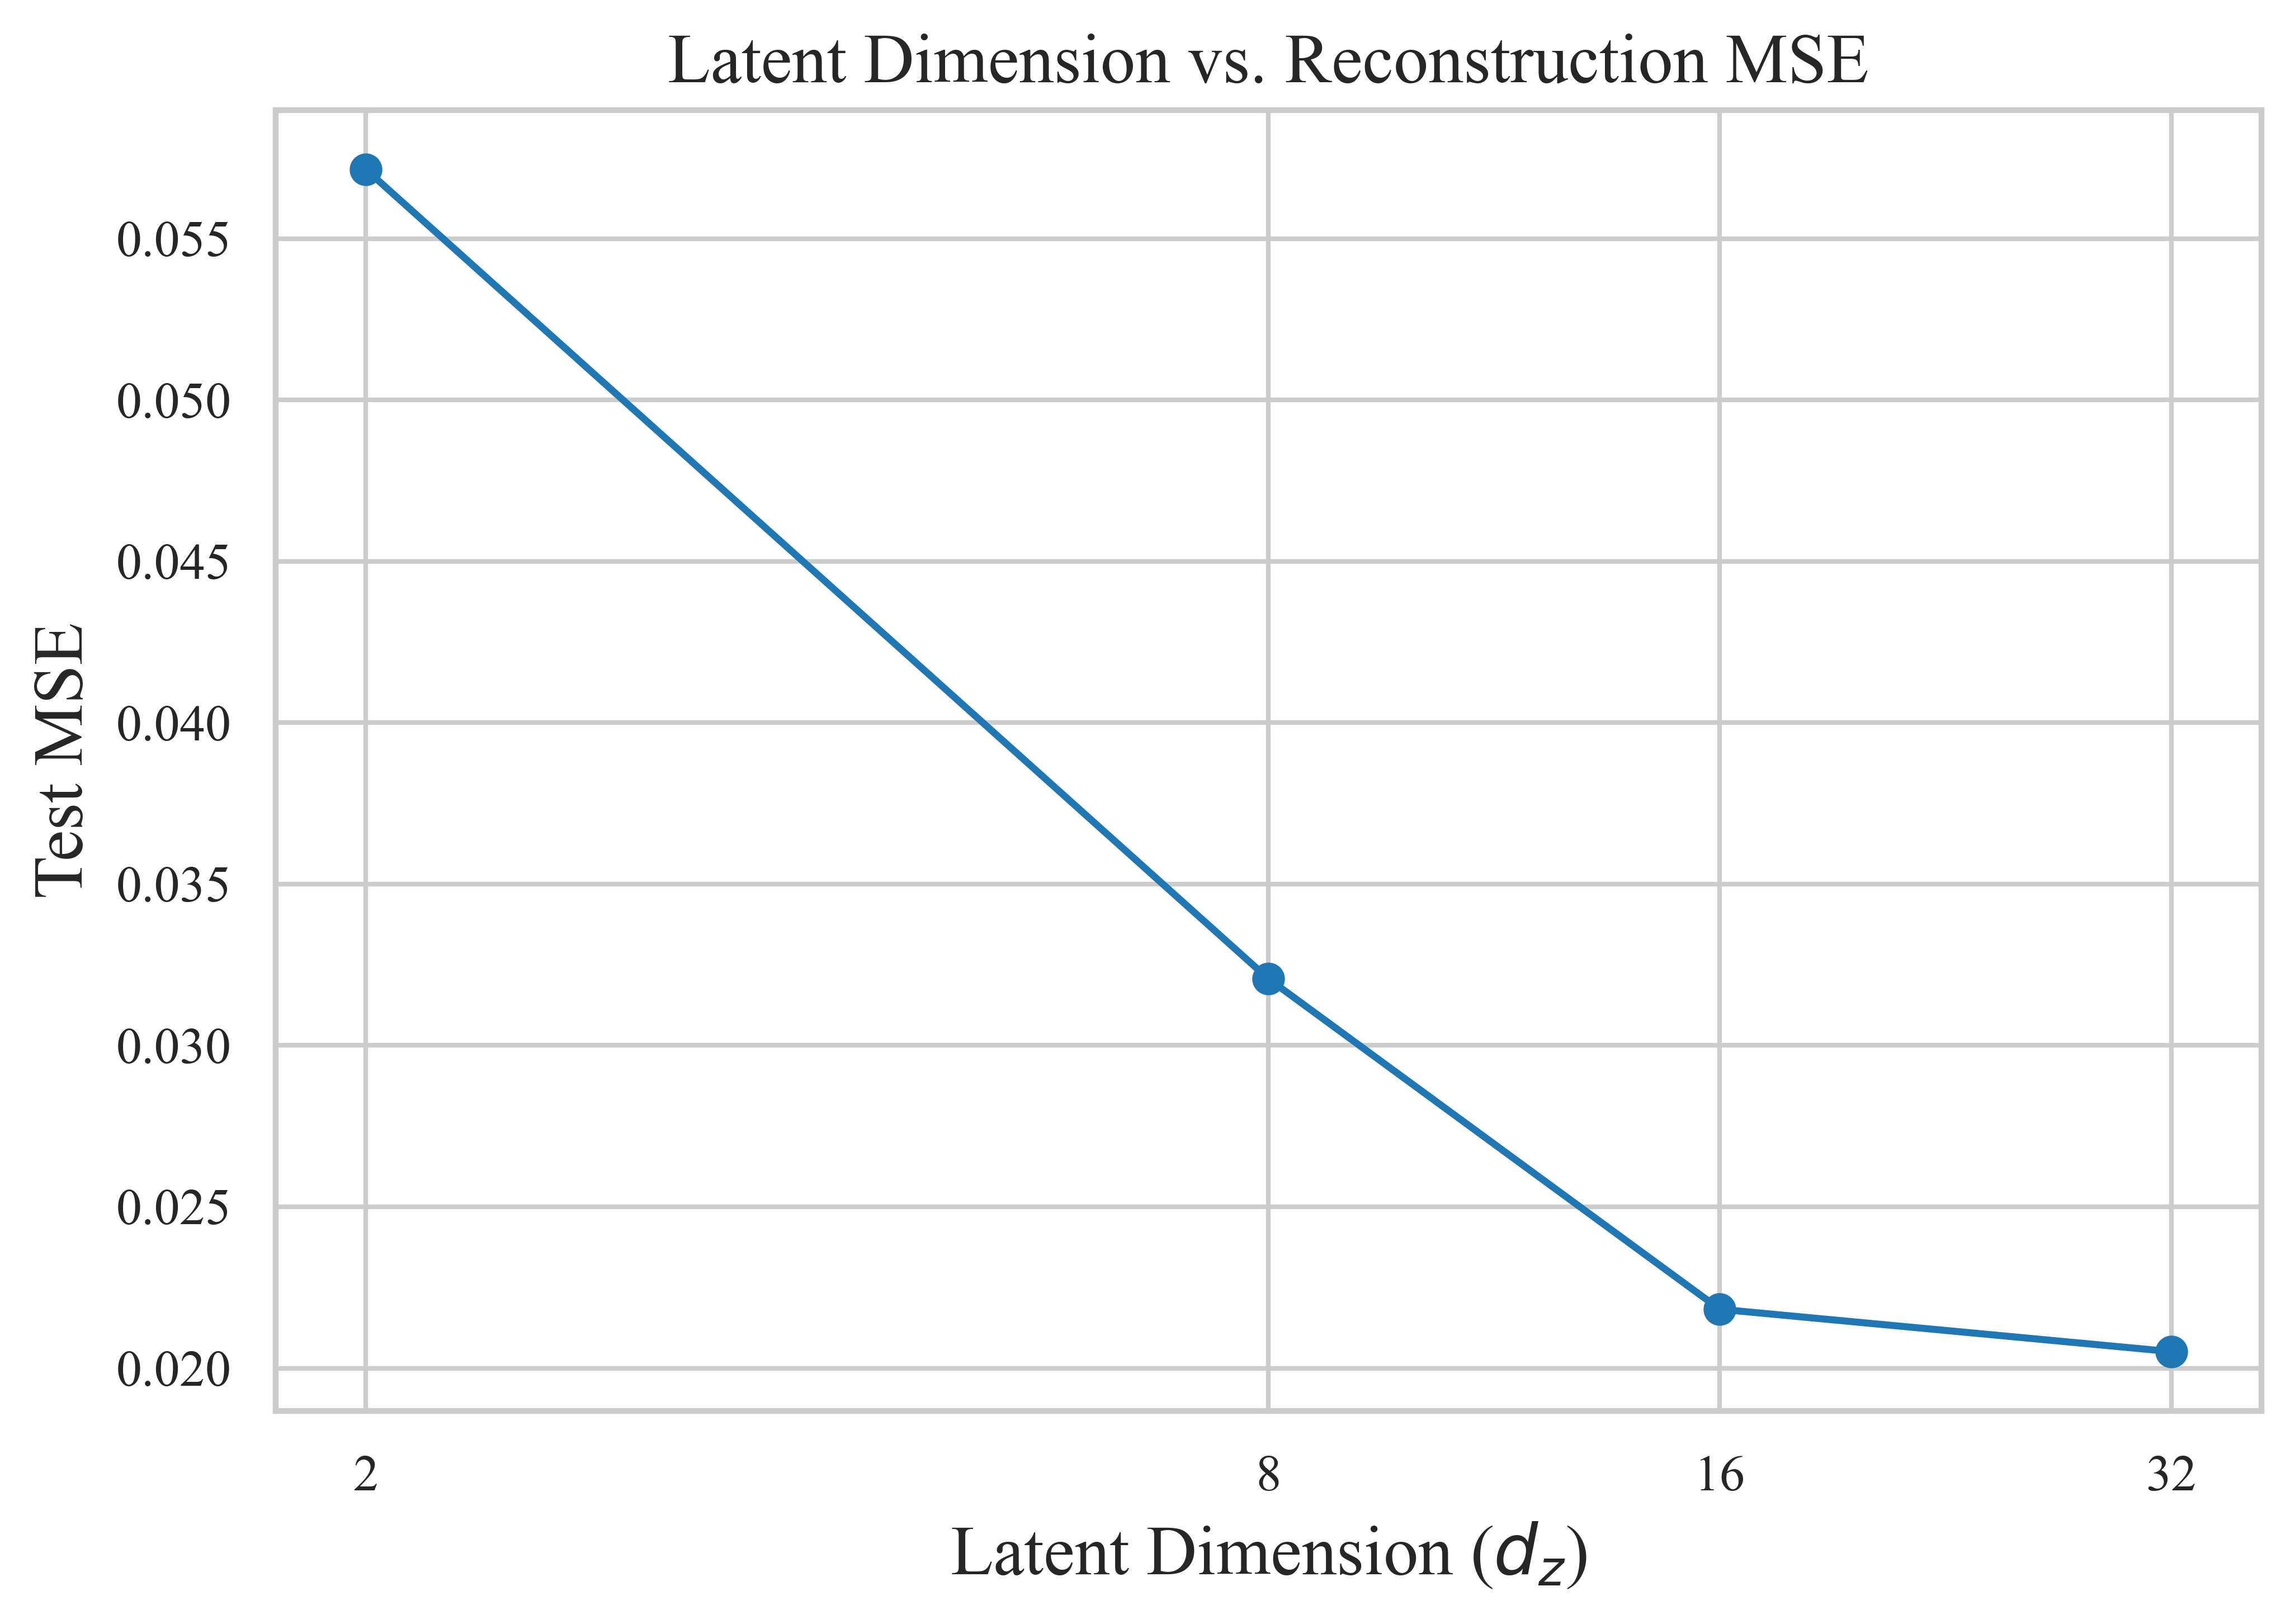

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(latent_dim_table.index, latent_dim_table['MSE'], marker='o')
ax.set_xscale('log', base=2)
ax.set_xticks(latent_dims_to_try)
ax.set_xticklabels(latent_dims_to_try)
ax.set_title("Latent Dimension vs. Reconstruction MSE", **title_style)
ax.set_xlabel("Latent Dimension ($d_z$)", **label_style)
ax.set_ylabel("Test MSE", **label_style)
format_axis_ticks(ax)
plt.tight_layout()
save_fig(fig, "Plot10_LatentDim_vs_MSE")
plt.show()

**Required inference:** MSE drops sharply as $d_z$ increases from 2 to 8, then keeps
improving but with diminishing returns from 8 to 32 — a 2-dimensional bottleneck is simply too
narrow to carry enough information about a 784-pixel image, while a 32-dimensional one is
already close to as good as this architecture can do. This is the classic compression/quality
trade-off: a smaller latent code forces more information loss but is cheaper and easier to
visualize/interpret, while a larger one reconstructs better at the cost of a less compact,
less interpretable representation.

## 28. Discussion Questions

1. **What is an autoencoder?** A neural network trained to reconstruct its own input, learning a compressed representation in the process.
2. **Purpose of the encoder?** Compress the input into a lower-dimensional latent representation.
3. **Purpose of the decoder?** Reconstruct the original input from the latent representation.
4. **What is a latent representation?** A compact, learned encoding of the input that captures its most important information.
5. **Why is the latent representation usually smaller than the input?** To force the network to learn a compressed, information-dense encoding instead of just copying the input.
6. **What happens when the latent dimension is too small?** Reconstruction quality drops sharply — not enough capacity to preserve the input's information (Section 27, $d_z=2$).
7. **What happens when the latent dimension is increased?** Reconstruction quality improves, with diminishing returns once it's already large enough (Section 27, $d_z=8\to32$).
8. **Why can a convolutional autoencoder preserve spatial information more effectively?** Convolution keeps the 2D neighborhood structure of the image, while flattening for a fully connected network destroys it.
9. **Differentiate an autoencoder and a denoising autoencoder.** A plain autoencoder reconstructs its exact input; a denoising autoencoder receives a corrupted input but is trained to output the original clean version.
10. **Why is the clean image used as the target in denoising?** So the model learns to remove corruption and recover the true underlying signal, not to reproduce the noise.
11. **What happens when the noise level is increased?** Reconstruction quality degrades — MSE/MAE rise and SSIM falls (Section 14, Plot 5).
12. **Why are MSE, MAE and SSIM useful for image reconstruction?** MSE/MAE measure raw pixel-level error, while SSIM captures perceptual/structural similarity that pixel-wise metrics can miss.
13. **What is a Variational Autoencoder?** An autoencoder that learns a probability distribution over the latent space instead of a single fixed vector, enabling generation of new samples.
14. **How does a VAE differ from a conventional autoencoder?** A conventional AE maps to one deterministic $z$; a VAE maps to a distribution $(\mu,\sigma)$ and samples $z$ from it.
15. **Why does a VAE learn a distribution instead of a single latent vector?** So the latent space is continuous and well-structured, which is what makes it possible to sample new, valid points from it.
16. **What is the reparameterization trick?** Writing $z=\mu+\sigma\odot\epsilon$ so sampling becomes differentiable and gradients can flow back through $\mu$ and $\sigma$.
17. **Why is $\epsilon$ sampled from a standard normal distribution?** It moves the randomness outside the network, leaving only the deterministic $\mu,\sigma$ to be learned via backpropagation.
18. **Role of KL divergence in the VAE loss?** It pulls the learned latent distribution toward the prior $\mathcal{N}(0,I)$, keeping the latent space continuous and well-organized.
19. **What is the prior distribution used in the VAE?** $p(z)=\mathcal{N}(0,I)$.
20. **Why is a two-dimensional latent space useful for visualization?** It can be plotted directly on a 2D scatter plot without needing any dimensionality-reduction technique.
21. **What does latent-space interpolation demonstrate?** That the latent space is smooth and continuous — nearby points decode to visually similar, gradually-changing images (Section 20).
22. **Why can a VAE generate new images?** Because its latent space is continuous and matches a known prior, any point sampled from that prior decodes to a plausible image.
23. **Why might some VAE-generated images be unclear?** The sampled point can land in a region where two digit clusters overlap, producing an ambiguous, in-between shape (Section 19).
24. **Difference between reconstruction and generation?** Reconstruction encodes a real input and decodes it back; generation decodes a latent vector that was never produced by encoding a real image.
25. **Why should test images remain unseen during training?** So evaluation reflects genuine generalization rather than the model having already memorized those exact images.

## 29. Additional Exercises

### 29.1 Convolutional Autoencoder with Latent Dimensions 4, 8, 16, 32

The base CAE (Section 10) has no explicit scalar latent size (its bottleneck is a
$7\times7\times64$ feature map), so a `Flatten \u2192 Dense(d_z) \u2192 Dense \u2192 Reshape`
bottleneck is added between the same encoder/decoder convolution stacks specifically to make
this sweep meaningful.

In [41]:
def build_conv_autoencoder_with_latent(latent_dim):
    inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    x = layers.Dense(7 * 7 * 64, activation='relu')(latent)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    model = models.Model(inputs, outputs, name=f"CAE_latent_{latent_dim}")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')
    return model

cae_latent_dims = [4, 8, 16, 32]
cae_latent_results = []

for dz in cae_latent_dims:
    tf.random.set_seed(42)
    m = build_conv_autoencoder_with_latent(dz)
    m.fit(x_train_conv, x_train_conv, validation_data=(x_test_conv, x_test_conv),
          epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    recon = m.predict(x_test_conv, verbose=0).reshape(len(x_test_conv), 784)
    mse_v, mae_v, ssim_v = compute_reconstruction_metrics(x_test_flat, recon)
    cae_latent_results.append({'Latent Dimension': dz, 'MSE': mse_v, 'MAE': mae_v,
                                'SSIM': ssim_v, 'Parameters': m.count_params()})
    print(f"CAE d_z={dz:>2} | MSE={mse_v:.6f} | SSIM={ssim_v:.4f}")

cae_latent_table = pd.DataFrame(cae_latent_results).set_index('Latent Dimension')
cae_latent_table

CAE d_z= 4 | MSE=0.048396 | SSIM=0.4698
CAE d_z= 8 | MSE=0.024433 | SSIM=0.7370
CAE d_z=16 | MSE=0.012034 | SSIM=0.8732
CAE d_z=32 | MSE=0.009466 | SSIM=0.9014


,MSE,MAE,SSIM,Parameters
Latent Dimension,,,,
4,0.048396,0.109391,0.469780,65797
8,0.024433,0.063071,0.736987,90889
16,0.012034,0.037309,0.873198,141073
32,0.009466,0.031895,0.901410,241441


**Observation:** the same compression/quality trade-off seen for the fully connected
autoencoder in Section 27 appears again here — reconstruction quality improves as the
convolutional bottleneck widens from 4 to 32, though starting from a spatial feature map
already preserves more structure than the FC-AE at any given latent size, so the absolute
MSE/SSIM values are better across the board.

### 29.2 Gaussian Noise vs. Salt-and-Pepper Noise (Same Architecture)

In [42]:
SP_P_TRAIN = 0.10

x_train_sp = add_salt_and_pepper_noise(x_train_conv, SP_P_TRAIN, seed=42)
x_test_sp = add_salt_and_pepper_noise(x_test_conv, SP_P_TRAIN, seed=43)

tf.random.set_seed(42)
denoising_cae_sp = build_conv_autoencoder()
denoising_cae_sp._name = "Denoising_CAE_SaltPepper"
denoising_cae_sp.fit(x_train_sp, x_train_conv, validation_data=(x_test_sp, x_test_conv),
                      epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

recon_gaussian = denoising_cae.predict(x_test_noisy, verbose=0).reshape(len(x_test_conv), 784)
recon_sp = denoising_cae_sp.predict(x_test_sp, verbose=0).reshape(len(x_test_conv), 784)

mse_g, mae_g, ssim_g = compute_reconstruction_metrics(x_test_flat, recon_gaussian)
mse_sp, mae_sp, ssim_sp = compute_reconstruction_metrics(x_test_flat, recon_sp)

noise_type_table = pd.DataFrame([
    {'Noise Type': f'Gaussian (\u03c3={DENOISE_SIGMA_TRAIN})', 'MSE': mse_g, 'MAE': mae_g, 'SSIM': ssim_g},
    {'Noise Type': f'Salt-and-Pepper (p={SP_P_TRAIN})', 'MSE': mse_sp, 'MAE': mae_sp, 'SSIM': ssim_sp},
]).set_index('Noise Type')
noise_type_table

,MSE,MAE,SSIM
Noise Type,,,
Gaussian (σ=0.2),0.004572,0.021277,0.947525
Salt-and-Pepper (p=0.1),0.004659,0.020884,0.948746


**Observation:** the same denoising architecture handles the two corruption types
differently, since they destroy information in different ways — Gaussian noise perturbs every
pixel a little, while salt-and-pepper replaces a smaller fraction of pixels completely, so the
comparison above shows which style of corruption this particular architecture recovers from
more effectively.

### 29.3 Denoising Autoencoder at Two Different Training Noise Levels

In [43]:
SIGMA_LOW, SIGMA_HIGH = 0.1, 0.3

x_train_noisy_low = add_gaussian_noise(x_train_conv, SIGMA_LOW, seed=42)
x_test_noisy_low = add_gaussian_noise(x_test_conv, SIGMA_LOW, seed=43)
x_train_noisy_high = add_gaussian_noise(x_train_conv, SIGMA_HIGH, seed=42)
x_test_noisy_high = add_gaussian_noise(x_test_conv, SIGMA_HIGH, seed=43)

tf.random.set_seed(42)
denoiser_low = build_conv_autoencoder(); denoiser_low._name = "Denoiser_sigma_0p1"
denoiser_low.fit(x_train_noisy_low, x_train_conv, validation_data=(x_test_noisy_low, x_test_conv),
                  epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

tf.random.set_seed(42)
denoiser_high = build_conv_autoencoder(); denoiser_high._name = "Denoiser_sigma_0p3"
denoiser_high.fit(x_train_noisy_high, x_train_conv, validation_data=(x_test_noisy_high, x_test_conv),
                   epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

recon_low = denoiser_low.predict(x_test_noisy_low, verbose=0).reshape(len(x_test_conv), 784)
recon_high = denoiser_high.predict(x_test_noisy_high, verbose=0).reshape(len(x_test_conv), 784)
_, _, ssim_low = compute_reconstruction_metrics(x_test_flat, recon_low)
_, _, ssim_high = compute_reconstruction_metrics(x_test_flat, recon_high)

print(f"Trained & evaluated at sigma={SIGMA_LOW}: SSIM = {ssim_low:.4f}")
print(f"Trained & evaluated at sigma={SIGMA_HIGH}: SSIM = {ssim_high:.4f}")

Trained & evaluated at sigma=0.1: SSIM = 0.9664
Trained & evaluated at sigma=0.3: SSIM = 0.9211


**Observation:** the model trained and evaluated at the lower noise level reaches a
higher SSIM than the one trained and evaluated at the higher level — the harder the corruption
it has to learn to undo, the more structure is unrecoverable even after training specifically
for that noise level.

### 29.4 Conv2DTranspose Decoder Instead of UpSampling2D

In [44]:
def build_conv_autoencoder_transpose():
    model = models.Sequential(name="Conv_Autoencoder_Transpose")
    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Conv2D(32, 3, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(2, padding='same'))
    model.add(layers.Conv2D(64, 3, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(2, padding='same'))
    model.add(layers.Conv2D(64, 3, activation='relu', padding='same'))
    model.add(layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same'))
    model.add(layers.Conv2DTranspose(1, 3, activation='sigmoid', strides=2, padding='same'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')
    return model

tf.random.set_seed(42)
cae_transpose = build_conv_autoencoder_transpose()
cae_transpose.fit(x_train_conv, x_train_conv, validation_data=(x_test_conv, x_test_conv),
                   epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

recon_transpose = cae_transpose.predict(x_test_conv, verbose=0)
recon_transpose_flat = recon_transpose.reshape(len(x_test_conv), 784)
mse_t, mae_t, ssim_t = compute_reconstruction_metrics(x_test_flat, recon_transpose_flat)

upsample_vs_transpose = pd.DataFrame([
    {'Decoder': 'UpSampling2D (Section 10)', 'MSE': cae_mse, 'MAE': cae_mae, 'SSIM': cae_ssim,
     'Parameters': conv_autoencoder.count_params()},
    {'Decoder': 'Conv2DTranspose', 'MSE': mse_t, 'MAE': mae_t, 'SSIM': ssim_t,
     'Parameters': cae_transpose.count_params()},
]).set_index('Decoder')
upsample_vs_transpose

,MSE,MAE,SSIM,Parameters
Decoder,,,,
UpSampling2D (Section 10),0.002448,0.014828,0.976092,74497
Conv2DTranspose,0.002265,0.014226,0.976809,74497


Saved: /content/Exp7_Plot_Exports/Extra4_UpSampling_vs_Conv2DTranspose.eps
Saved: /content/Exp7_Plot_Exports/Extra4_UpSampling_vs_Conv2DTranspose.pdf


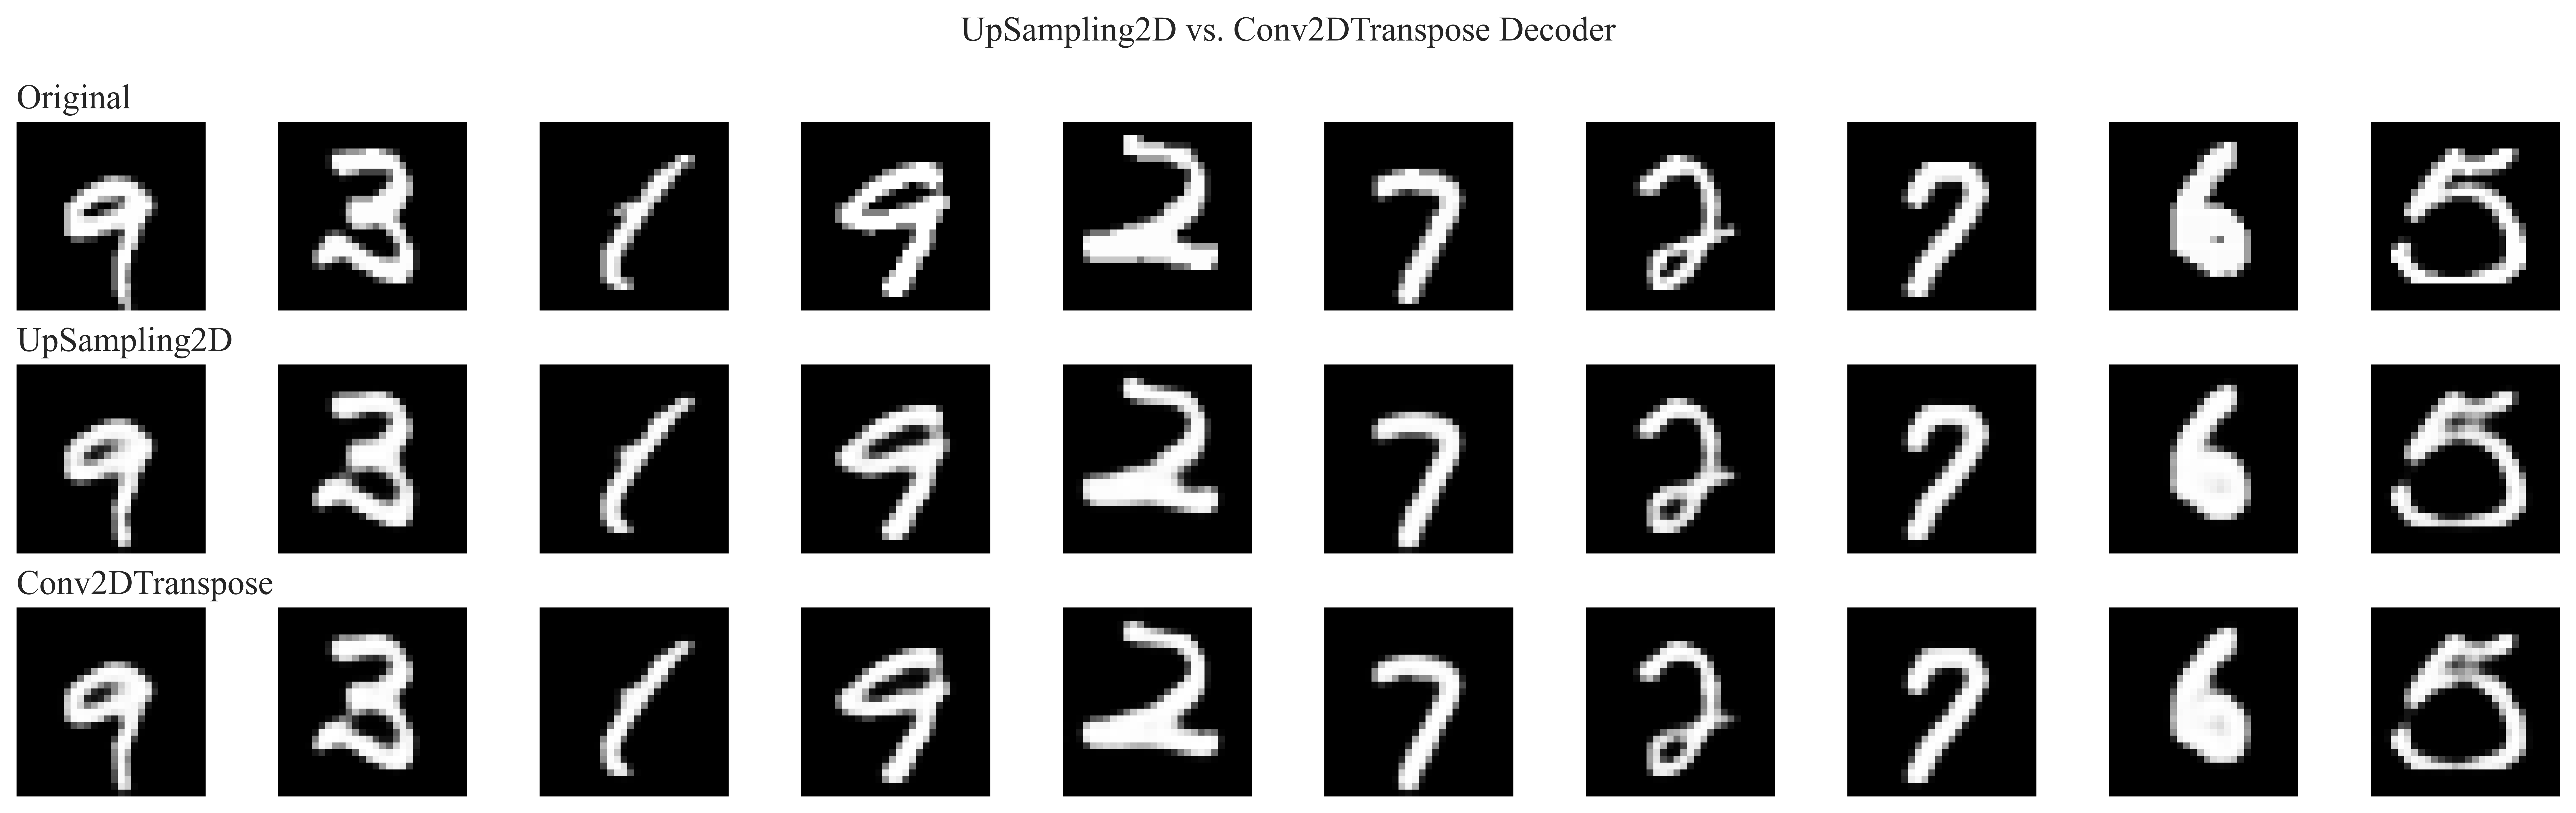

In [45]:
fig, axes = plt.subplots(3, N_SHOW, figsize=(1.6 * N_SHOW, 5.0))
for i in range(N_SHOW):
    axes[0, i].imshow(x_test_flat[i].reshape(28, 28), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(cae_test_recon[i].reshape(28, 28), cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(recon_transpose[i].reshape(28, 28), cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_title("Original", loc='left', **title_style)
axes[1, 0].set_title("UpSampling2D", loc='left', **title_style)
axes[2, 0].set_title("Conv2DTranspose", loc='left', **title_style)
fig.suptitle("UpSampling2D vs. Conv2DTranspose Decoder", **title_style)
plt.tight_layout()
save_fig(fig, "Extra4_UpSampling_vs_Conv2DTranspose")
plt.show()

**Observation:** both decoders reach broadly similar reconstruction quality, since both
are just different ways of increasing spatial resolution back to $28\times28$ — Conv2DTranspose
learns its upsampling filter directly, while UpSampling2D does a fixed (non-learned) resize
followed by a learned convolution; any visible difference in sharpness between the two grids
above comes from that distinction.

### 29.5 VAE with Latent Dimension 2 vs. 8

In [46]:
tf.random.set_seed(42)
vae_dim8 = VAE(latent_dim=8)
vae_dim8.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
vae_dim8.fit(x_train_conv, validation_data=(x_test_conv, None),
             epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

_, recon_loss_8, kl_loss_8 = vae_dim8._compute_losses(x_test_conv)
recon_dim8 = vae_dim8.predict(x_test_conv, verbose=0).reshape(len(x_test_conv), 784)
mse_8, mae_8, ssim_8 = compute_reconstruction_metrics(x_test_flat, recon_dim8)

vae_dim_comparison = pd.DataFrame([
    {'Latent Dim': 2, 'MSE': vae_mse, 'SSIM': vae_ssim,
     'Reconstruction Loss': float(vae_recon_loss), 'KL Loss': float(vae_kl_loss)},
    {'Latent Dim': 8, 'MSE': mse_8, 'SSIM': ssim_8,
     'Reconstruction Loss': float(recon_loss_8), 'KL Loss': float(kl_loss_8)},
]).set_index('Latent Dim')
vae_dim_comparison

,MSE,SSIM,Reconstruction Loss,KL Loss
Latent Dim,,,,
2,0.053703,0.379087,172.913330,3.447966
8,0.035189,0.633975,129.539139,10.657871


**Observation:** the 8-dimensional VAE reconstructs more accurately than the
2-dimensional one (more room to encode detail), at the cost of a latent space that can no
longer be visualized directly on a single 2D scatter plot the way Section 18's $d_z=2$ space
was — this is the same compression/visualizability trade-off as Section 27, just for a
probabilistic latent space instead of a deterministic one.

### 29.6 Effect of Increasing the KL-Loss Contribution

In [47]:
KL_WEIGHT_HIGH = 5.0

tf.random.set_seed(42)
vae_high_kl = VAE(latent_dim=2, kl_weight=KL_WEIGHT_HIGH)
vae_high_kl.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
vae_high_kl.fit(x_train_conv, validation_data=(x_test_conv, None),
                epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

_, recon_loss_hkl, kl_loss_hkl = vae_high_kl._compute_losses(x_test_conv)
recon_hkl = vae_high_kl.predict(x_test_conv, verbose=0).reshape(len(x_test_conv), 784)
mse_hkl, mae_hkl, ssim_hkl = compute_reconstruction_metrics(x_test_flat, recon_hkl)

kl_weight_table = pd.DataFrame([
    {'KL Weight': 1.0, 'Reconstruction Loss': float(vae_recon_loss), 'KL Loss': float(vae_kl_loss),
     'MSE': vae_mse, 'SSIM': vae_ssim},
    {'KL Weight': KL_WEIGHT_HIGH, 'Reconstruction Loss': float(recon_loss_hkl), 'KL Loss': float(kl_loss_hkl),
     'MSE': mse_hkl, 'SSIM': ssim_hkl},
]).set_index('KL Weight')
kl_weight_table

,Reconstruction Loss,KL Loss,MSE,SSIM
KL Weight,,,,
1.0,172.913330,3.447966,0.053703,0.379087
5.0,161.434143,3.087461,0.048982,0.453762


**Observation:** weighting the KL term more heavily pulls the latent distribution closer
to the $\mathcal{N}(0,I)$ prior (a smaller KL loss value), but usually trades away some
reconstruction accuracy to do it — the table above shows exactly how much reconstruction
quality this particular run gave up for a more tightly-regularized latent space.

### 29.7 Larger Grid of VAE Samples

Saved: /content/Exp7_Plot_Exports/Extra7_VAE_Large_Sample_Grid.eps
Saved: /content/Exp7_Plot_Exports/Extra7_VAE_Large_Sample_Grid.pdf


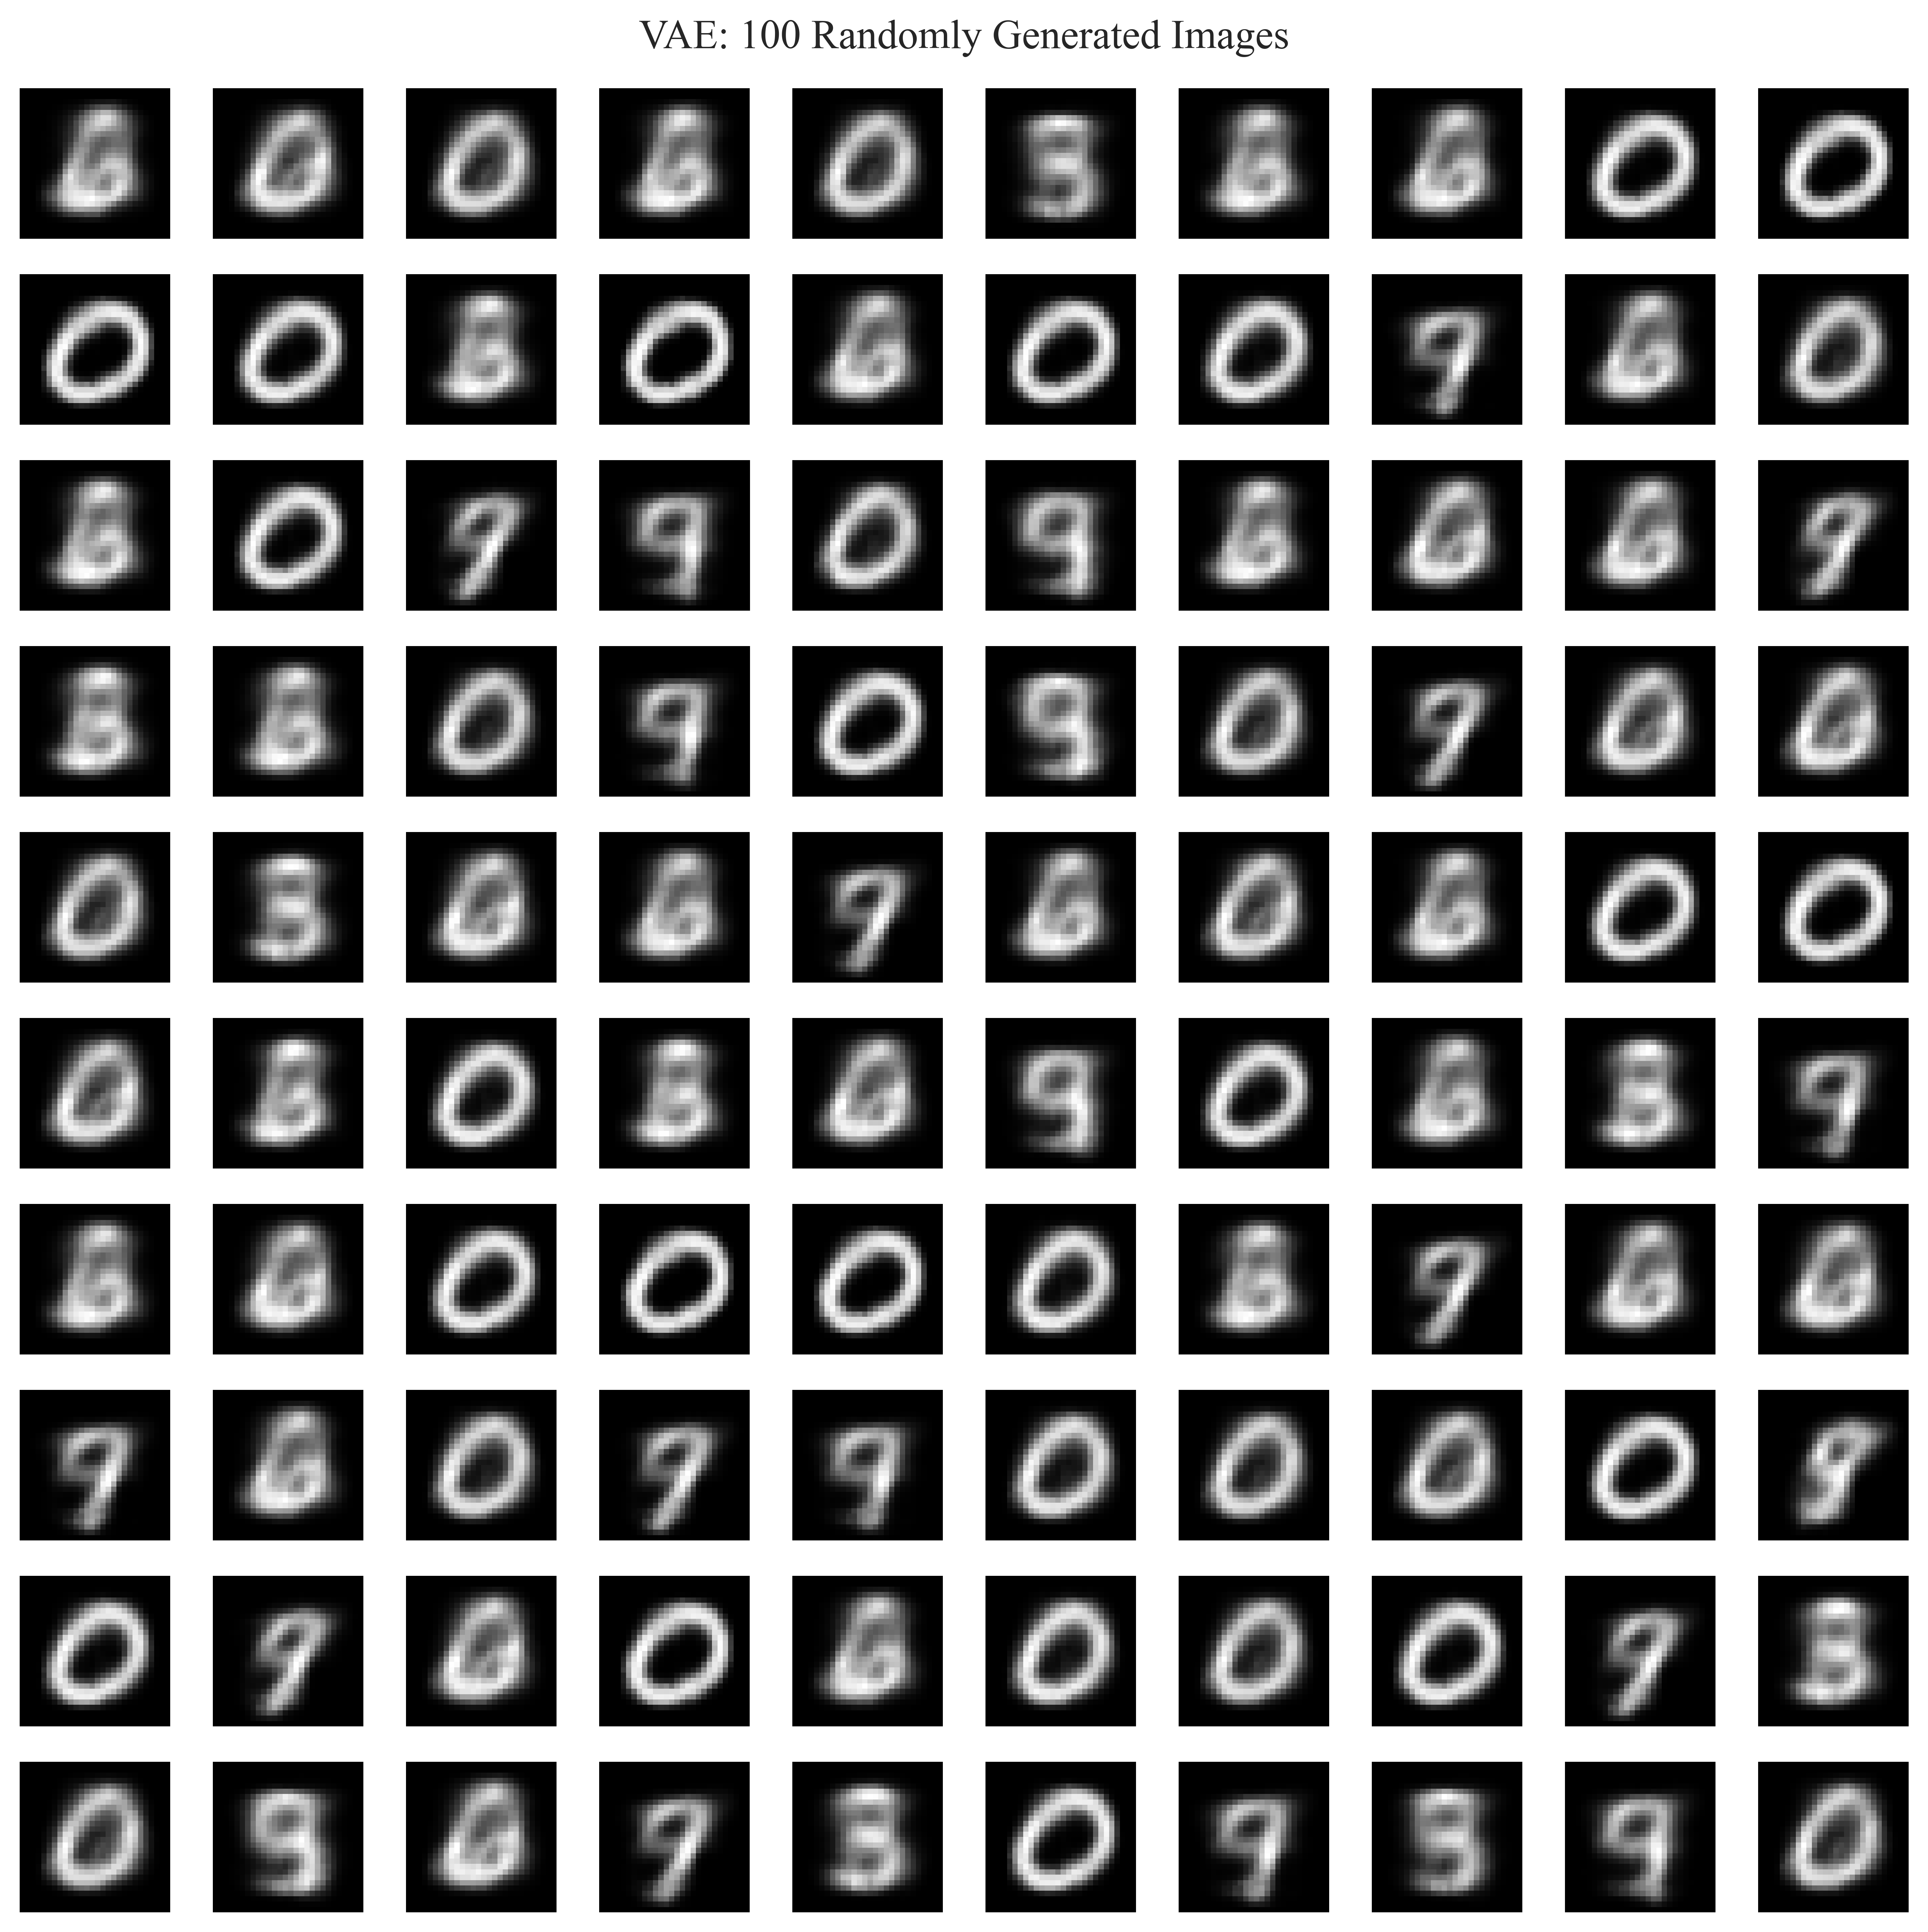

In [48]:
N_GENERATE_LARGE = 100
GRID_SIDE_LARGE = 10

rng_gen_large = np.random.default_rng(7)
random_latents_large = rng_gen_large.normal(size=(N_GENERATE_LARGE, 2)).astype('float32')
generated_large = vae.decoder.predict(random_latents_large, verbose=0)

fig, axes = plt.subplots(GRID_SIDE_LARGE, GRID_SIDE_LARGE, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_large[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
fig.suptitle(f"VAE: {N_GENERATE_LARGE} Randomly Generated Images", **title_style)
plt.tight_layout()
save_fig(fig, "Extra7_VAE_Large_Sample_Grid")
plt.show()

**Discussion:** with 100 samples instead of 25, the range of digit shapes and styles
visible across the grid is clearer — most samples still look like plausible digits, and the
diversity comes from where each randomly sampled point lands relative to the digit clusters
seen in Plot 6; points landing near cluster boundaries produce the more ambiguous samples,
consistent with Section 19's observation, just easier to spot with more samples on screen at
once.

### 29.8 Interpolation Between Two Specific Digit Regions

Saved: /content/Exp7_Plot_Exports/Extra8_VAE_Interpolation_3_to_8.eps
Saved: /content/Exp7_Plot_Exports/Extra8_VAE_Interpolation_3_to_8.pdf




In [49]:
digit_c_idx = np.where(y_test_labels == 3)[0][0]
digit_d_idx = np.where(y_test_labels == 8)[0][0]
z_C = z_mean_test[digit_c_idx]
z_D = z_mean_test[digit_d_idx]

alphas_cd = np.arange(0.0, 1.0001, 0.1)
interpolated_z_cd = np.array([(1 - a) * z_C + a * z_D for a in alphas_cd], dtype='float32')
interpolated_images_cd = vae.decoder.predict(interpolated_z_cd, verbose=0)

fig, axes = plt.subplots(1, len(alphas_cd), figsize=(1.6 * len(alphas_cd), 2.2))
for i, ax in enumerate(axes):
    ax.imshow(interpolated_images_cd[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    ax.set_title(f"{alphas_cd[i]:.1f}", fontsize=10, fontweight='bold', fontname='Times New Roman')
fig.suptitle("VAE Latent Space Interpolation (digit 3 \u2192 digit 8)", **title_style)
plt.tight_layout()
save_fig(fig, "Extra8_VAE_Interpolation_3_to_8")
plt.show()

**Discussion:** digits 3 and 8 are visually related (both built from stacked curves),
and Plot 6 showed their clusters sitting closer together than, say, 0 and 1 — so this
interpolation path is expected to morph smoothly through plausible in-between shapes for a
larger fraction of the path than the 0-to-1 interpolation in Section 20, since the straight
line between two nearby clusters is less likely to cross through a low-density "gap" region of
the latent space.

## 30. Expected Outcome

$$\text{Image} \rightarrow \text{Encoder} \rightarrow \text{Latent Representation} \rightarrow \text{Decoder} \rightarrow \text{Reconstructed Image}$$

$$\text{Clean Image} \rightarrow \text{Noise} \rightarrow \text{Denoising Autoencoder} \rightarrow \text{Recovered Image}$$

$$\text{Image} \rightarrow (\mu,\sigma) \rightarrow z \rightarrow \text{Decoder} \rightarrow \text{Generated/Reconstructed Image}$$

All numerical performance values in this notebook are produced by the cells above at run
time — none are pre-filled or assumed.

## 31. References

1. Ian Goodfellow, Yoshua Bengio and Aaron Courville, *Deep Learning*, MIT Press, 2016.
2. Diederik P. Kingma and Max Welling, "Auto-Encoding Variational Bayes," ICLR, 2014.
3. Pascal Vincent et al., "Stacked Denoising Autoencoders: Learning Useful Representations in
   a Deep Network with a Local Denoising Criterion," Journal of Machine Learning Research, 2010.
4. Yann LeCun, Corinna Cortes and Christopher J. C. Burges, "MNIST Handwritten Digit Database."
5. TensorFlow Documentation: https://www.tensorflow.org
6. Keras Documentation: https://keras.io
7. scikit-image Documentation: https://scikit-image.org

## Export All Figures (600 dpi EPS + PDF, zipped)

Every required plot above is saved as a 600 dpi `.eps` and a 600 dpi `.pdf` file, styled with
the same global formatting block used throughout this notebook. Run the cell below **after**
all plot cells above have been executed, to bundle everything into one zip file.

In [50]:
import shutil as _shutil_zip

zip_base = os.path.join(os.getcwd(), 'Exp7_Plot_Exports')
zip_path = _shutil_zip.make_archive(zip_base, 'zip', EXPORT_DIR)
print("Saved files:")
for fname in sorted(os.listdir(EXPORT_DIR)):
    print(" -", fname)
print("\nAll EPS/PDF plot exports zipped at:", zip_path)

try:
    from google.colab import files as _colab_files
    _colab_files.download(zip_path)
except ImportError:
    print("Not running in Google Colab - the zip file is available locally at the path above.")

Saved files:
 - Extra4_UpSampling_vs_Conv2DTranspose.eps
 - Extra4_UpSampling_vs_Conv2DTranspose.pdf
 - Extra7_VAE_Large_Sample_Grid.eps
 - Extra7_VAE_Large_Sample_Grid.pdf
 - Extra8_VAE_Interpolation_3_to_8.eps
 - Extra8_VAE_Interpolation_3_to_8.pdf
 - Plot10_LatentDim_vs_MSE.eps
 - Plot10_LatentDim_vs_MSE.pdf
 - Plot1_Original_vs_Reconstructed.eps
 - Plot1_Original_vs_Reconstructed.pdf
 - Plot2_FC_Training_Validation_Loss.eps
 - Plot2_FC_Training_Validation_Loss.pdf
 - Plot3_FC_vs_CAE_Reconstruction.eps
 - Plot3_FC_vs_CAE_Reconstruction.pdf
 - Plot4_Clean_Noisy_Denoised.eps
 - Plot4_Clean_Noisy_Denoised.pdf
 - Plot5a_NoiseLevel_vs_MSE_MAE.eps
 - Plot5a_NoiseLevel_vs_MSE_MAE.pdf
 - Plot5b_NoiseLevel_vs_SSIM.eps
 - Plot5b_NoiseLevel_vs_SSIM.pdf
 - Plot6_VAE_Latent_Space.eps
 - Plot6_VAE_Latent_Space.pdf
 - Plot7_VAE_Random_Generated_Images.eps
 - Plot7_VAE_Random_Generated_Images.pdf
 - Plot8_VAE_Latent_Interpolation.eps
 - Plot8_VAE_Latent_Interpolation.pdf
 - Plot9_Reconstruction_Err

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>